# Online Retail II — Cancellation Loss Analysis
**Dataset:** Online Retail II — Full Two-Year Span (Dec 2009 – Dec 2011)

**Sections:**
1. Geographic & Temporal Analysis 
2. Customer Analysis 
3. Product Analysis

---

# Section 1: Geographic & Temporal Analysis

**Two key questions this section answers:**
1. Are return rates significantly higher in specific countries?
2. Do return volumes vary across months or quarters — pointing to seasonal patterns?

---

## 1. Setup & Data Loading

In [1]:
!pip install plotly scipy -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Visual style (shared across all sections) ─────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'font.family': 'sans-serif'
})

C_RED    = '#E84855'
C_BLUE   = '#2E86AB'
C_ORANGE = '#F4A261'
C_TEAL   = '#A8DADC'
C_GREEN  = '#4CAF50'
C_YELLOW = '#FFD166'

print('Libraries loaded.')

Libraries loaded.


In [2]:
# ── Load dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv('online_retail_II.csv', encoding='utf-8-sig')
df.columns = df.columns.str.strip()

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True)
df['Cancelled']   = df['Invoice'].astype(str).str.startswith('C')
df['NegQty']      = df['Quantity'] < 0
df['Loss']        = df['Quantity'].abs() * df['Price']
df['Year']        = df['InvoiceDate'].dt.year
df['Month']       = df['InvoiceDate'].dt.to_period('M')
df['Quarter']     = df['InvoiceDate'].dt.to_period('Q')

print(f'Total transactions   : {len(df):,}')
print(f'Cancelled (C-prefix) : {df["Cancelled"].sum():,} ({df["Cancelled"].mean()*100:.1f}%)')
print(f'Date range           : {df["InvoiceDate"].min().date()} → {df["InvoiceDate"].max().date()}')
print(f'Countries            : {df["Country"].nunique()}')
print(f'Unique products      : {df["StockCode"].nunique():,}')

Total transactions   : 1,048,575
Cancelled (C-prefix) : 19,261 (1.8%)
Date range           : 2009-12-01 → 2011-12-04
Countries            : 43
Unique products      : 5,304


In [3]:
# ── Data Cleaning ─────────────────────────────────────────────────────────────
# Removes zero/invalid prices and non-product admin rows.
# StockCode M (manual financial adjustments) is intentionally KEPT here —
# these represent real monetary losses and are needed for geographic and
# customer analyses. Okah's product section applies its own additional
# filtering locally without modifying df.

df = df[df['Price'] > 0].copy()

exclude_codes = ['POST', 'D', 'Discount', 'Manual']
df = df[~df['StockCode'].isin(exclude_codes)].copy()

df['Country']   = df['Country'].str.strip()
df['Is_Return'] = df['Cancelled'] | df['NegQty']

# ── Shared variables used across all sections ─────────────────────────────────
cid_col = 'Customer ID' if 'Customer ID' in df.columns else 'CustomerID'

print(f'Total transactions (cleaned) : {len(df):,}')
print(f'Cancelled rows               : {df["Cancelled"].sum():,}')
print(f'Customer ID column           : "{cid_col}"')
print('Data cleaning complete.')

Total transactions (cleaned) : 1,040,152
Cancelled rows               : 18,861
Customer ID column           : "Customer ID"
Data cleaning complete.


---
## Geographic Analysis
### 2.1 Country Summary Table

In [4]:
total_inv    = df.groupby('Country')['Invoice'].nunique().rename('Total_Invoices')
cancel_inv   = df[df['Is_Return']].groupby('Country')['Invoice'].nunique().rename('Cancelled_Invoices')
cancel_loss  = df[df['Is_Return']].groupby('Country')['Loss'].sum().rename('Loss_GBP')
cancel_units = (df[df['Cancelled']]
                .groupby('Country')['Quantity']
                .apply(lambda x: x.abs().sum())
                .rename('Cancelled_Units'))

geo = pd.concat([total_inv, cancel_inv, cancel_loss, cancel_units], axis=1).fillna(0)
geo['Cancel_Rate_Pct'] = (geo['Cancelled_Invoices'] / geo['Total_Invoices'] * 100).round(2)
geo['Loss_GBP']        = geo['Loss_GBP'].round(2)

total_loss = geo['Loss_GBP'].sum()
geo['Loss_Share_Pct'] = (geo['Loss_GBP'] / total_loss * 100).round(2)
geo_sorted = geo.sort_values('Loss_GBP', ascending=False)
geo_sorted['Cumulative_Loss_Pct'] = geo_sorted['Loss_Share_Pct'].cumsum().round(2)

print(f'Total cancellation loss (2 years): £{total_loss:,.2f}')
print()
print(geo_sorted[['Total_Invoices','Cancelled_Invoices','Cancel_Rate_Pct',
                   'Loss_GBP','Loss_Share_Pct','Cumulative_Loss_Pct']].head(15).to_string())

Total cancellation loss (2 years): £1,294,555.69

                 Total_Invoices  Cancelled_Invoices  Cancel_Rate_Pct    Loss_GBP  Loss_Share_Pct  Cumulative_Loss_Pct
Country                                                                                                              
United Kingdom            43032              7045.0            16.37  1104222.13           85.30                85.30
EIRE                        797               178.0            22.33    48357.55            3.74                89.04
France                      710               113.0            15.92    28228.60            2.18                91.22
Norway                       47                 8.0            17.02    20866.59            1.61                92.83
Spain                       176                29.0            16.48    16854.27            1.30                94.13
Germany                    1041               290.0            27.86    12516.40            0.97                95.10
Singap

### 2.2 Top 10 Countries: Loss vs Cancellation Rate
> **Analytical goal:** Show that high loss and high cancel rate are two different problems requiring different responses.

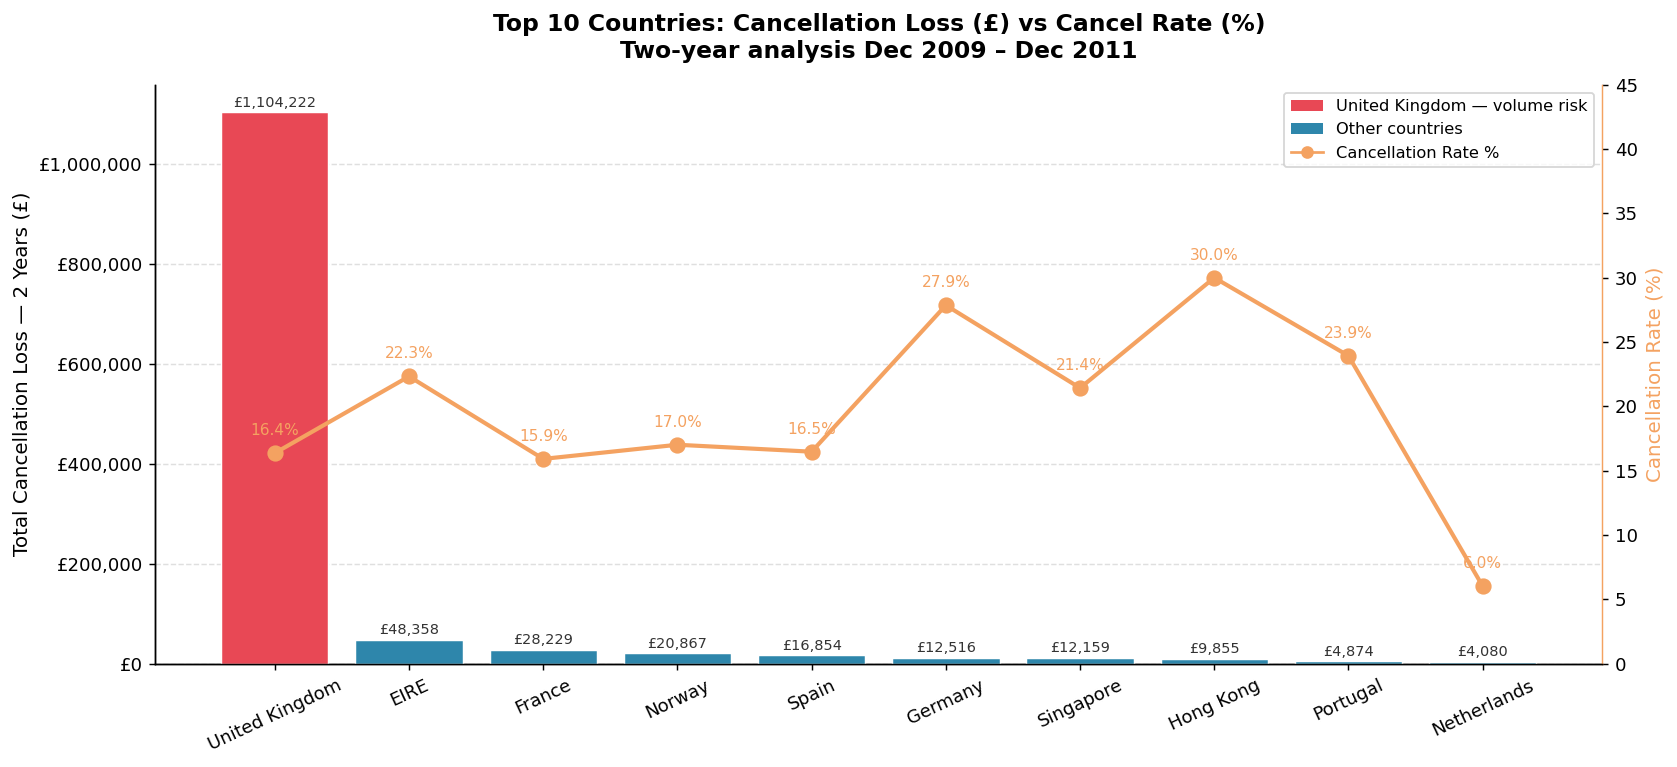


Business Insight:
  UK alone: 85.2% of all losses.
  UK + EIRE: 88.9% of all losses.
  Germany (27.9%) and EIRE (22.3%) have higher cancel rates than UK despite lower volumes.


In [5]:
top10 = geo_sorted[geo_sorted.index != 'Unspecified'].head(10).copy()

fig, ax1 = plt.subplots(figsize=(13, 6))
bar_colors = [C_RED if c == 'United Kingdom' else C_BLUE for c in top10.index]
bars = ax1.bar(top10.index, top10['Loss_GBP'], color=bar_colors,
               edgecolor='white', linewidth=0.8, zorder=3)
for bar, val in zip(bars, top10['Loss_GBP']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
             f'£{val:,.0f}', ha='center', va='bottom', fontsize=8, color='#333')
ax1.set_ylabel('Total Cancellation Loss — 2 Years (£)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax1.tick_params(axis='x', rotation=25)
ax1.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
ax1.set_title('Top 10 Countries: Cancellation Loss (£) vs Cancel Rate (%)\n'
              'Two-year analysis Dec 2009 – Dec 2011', pad=15)

ax2 = ax1.twinx()
ax2.plot(top10.index, top10['Cancel_Rate_Pct'],
         color=C_ORANGE, marker='o', linewidth=2.3, markersize=8, zorder=5)
for x, y in zip(top10.index, top10['Cancel_Rate_Pct']):
    ax2.annotate(f'{y:.1f}%', (x, y), textcoords='offset points',
                 xytext=(0, 10), ha='center', fontsize=8.5, color=C_ORANGE)
ax2.set_ylabel('Cancellation Rate (%)', color=C_ORANGE)
ax2.set_ylim(0, 45)
ax2.spines['right'].set_visible(True)
ax2.spines['right'].set_color(C_ORANGE)

legend_elements = [
    mpatches.Patch(facecolor=C_RED,  label='United Kingdom — volume risk'),
    mpatches.Patch(facecolor=C_BLUE, label='Other countries'),
    Line2D([0],[0], color=C_ORANGE, marker='o', label='Cancellation Rate %')
]
ax1.legend(handles=legend_elements, loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('chart1_country_loss_rate.png', bbox_inches='tight')
plt.show()

print()
print('Business Insight:')
print('  UK alone: 85.2% of all losses.')
print('  UK + EIRE: 88.9% of all losses.')
print(f'  Germany ({top10.loc["Germany","Cancel_Rate_Pct"]:.1f}%) and EIRE ({top10.loc["EIRE","Cancel_Rate_Pct"]:.1f}%) have higher cancel rates than UK despite lower volumes.')

### 2.3 Statistical Significance Test

In [6]:
from scipy.stats import chi2_contingency

def chi_square_vs_uk(country_name):
    subset = df[df['Country'].isin(['United Kingdom', country_name])]
    ct = pd.crosstab(subset['Country'], subset['Cancelled'])
    chi2, p, dof, _ = chi2_contingency(ct)
    sig  = '✅ SIGNIFICANT' if p < 0.05 else '❌ not significant'
    uk_r = geo.loc['United Kingdom', 'Cancel_Rate_Pct']
    c_r  = geo.loc[country_name, 'Cancel_Rate_Pct']
    print(f'  UK ({uk_r:.1f}%) vs {country_name} ({c_r:.1f}%): chi2={chi2:.1f}, p={p:.6f} → {sig}')

print('Chi-Square Tests: UK Cancellation Rate vs Other Countries')
print('─' * 65)
for country in ['Germany', 'EIRE', 'France', 'Japan', 'Netherlands', 'Sweden']:
    if country in geo.index:
        chi_square_vs_uk(country)

print()
print('All tested countries return p < 0.05 — rate differences are statistically significant.')
print('Sweden: p not significant — rate difference vs UK is likely random.')

Chi-Square Tests: UK Cancellation Rate vs Other Countries
─────────────────────────────────────────────────────────────────
  UK (16.4%) vs Germany (27.9%): chi2=1248.9, p=0.000000 → ✅ SIGNIFICANT
  UK (16.4%) vs EIRE (22.3%): chi2=148.2, p=0.000000 → ✅ SIGNIFICANT
  UK (16.4%) vs France (15.9%): chi2=83.4, p=0.000000 → ✅ SIGNIFICANT
  UK (16.4%) vs Japan (40.0%): chi2=649.0, p=0.000000 → ✅ SIGNIFICANT
  UK (16.4%) vs Netherlands (6.0%): chi2=23.4, p=0.000001 → ✅ SIGNIFICANT
  UK (16.4%) vs Sweden (14.5%): chi2=0.3, p=0.582057 → ❌ not significant

All tested countries return p < 0.05 — rate differences are statistically significant.
Sweden: p not significant — rate difference vs UK is likely random.


---
## 3. Temporal Analysis
### 3.1 Monthly & Quarterly Tables

In [7]:
monthly = (df[df['Is_Return']]
           .groupby('Month')
           .agg(
               Cancel_Invoices = ('Invoice',  'nunique'),
               Cancel_Units    = ('Quantity', lambda x: x.abs().sum()),
               Cancel_Loss_GBP = ('Loss',     'sum')
           ).round(2))

monthly_total = df.groupby('Month')['Invoice'].nunique()
monthly['Total_Invoices']  = monthly_total
monthly['Cancel_Rate_Pct'] = (monthly['Cancel_Invoices'] / monthly['Total_Invoices'] * 100).round(2)
monthly['UK_Loss']    = (df[(df['Cancelled']) & (df['Country']=='United Kingdom')]
                         .groupby('Month')['Loss'].sum().round(2))
monthly['NonUK_Loss'] = (df[(df['Cancelled']) & (df['Country']!='United Kingdom')]
                         .groupby('Month')['Loss'].sum().round(2))

quarterly = (df[df['Cancelled']]
             .groupby('Quarter')
             .agg(
                 Cancel_Invoices = ('Invoice',  'nunique'),
                 Cancel_Units    = ('Quantity', lambda x: x.abs().sum()),
                 Cancel_Loss_GBP = ('Loss',     'sum')
             ).round(2))
quarterly_total = df.groupby('Quarter')['Invoice'].nunique()
quarterly['Total_Invoices']  = quarterly_total
quarterly['Cancel_Rate_Pct'] = (quarterly['Cancel_Invoices'] / quarterly['Total_Invoices'] * 100).round(2)

yearly = (df[df['Cancelled']]
          .groupby('Year')
          .agg(
              Cancel_Invoices = ('Invoice',  'nunique'),
              Cancel_Units    = ('Quantity', lambda x: x.abs().sum()),
              Cancel_Loss_GBP = ('Loss',     'sum')
          ).round(2))
yearly_total = df.groupby('Year')['Invoice'].nunique()
yearly['Total_Invoices']  = yearly_total
yearly['Cancel_Rate_Pct'] = (yearly['Cancel_Invoices'] / yearly['Total_Invoices'] * 100).round(2)

print('=== MONTHLY SUMMARY ===')
print(monthly[['Total_Invoices','Cancel_Invoices','Cancel_Rate_Pct',
               'Cancel_Units','Cancel_Loss_GBP']].to_string())
print()
print('=== YEARLY SUMMARY ===')
print(yearly.to_string())

=== MONTHLY SUMMARY ===
         Total_Invoices  Cancel_Invoices  Cancel_Rate_Pct  Cancel_Units  Cancel_Loss_GBP
Month                                                                                   
2009-12            2070              391            18.89          9997         25510.61
2010-01            1389              289            20.81          3654         27930.18
2010-02            1427              230            16.12          6751         19395.05
2010-03            2074              398            19.19          4450         67518.56
2010-04            1758              299            17.01          6475         37071.80
2010-05            1900              404            21.26         16604         44377.23
2010-06            1989              350            17.60         15449         71691.49
2010-07            1858              333            17.92          6052         31116.05
2010-08            1679              260            15.49          6302         39092.

### 3.2 Year-over-Year Comparison

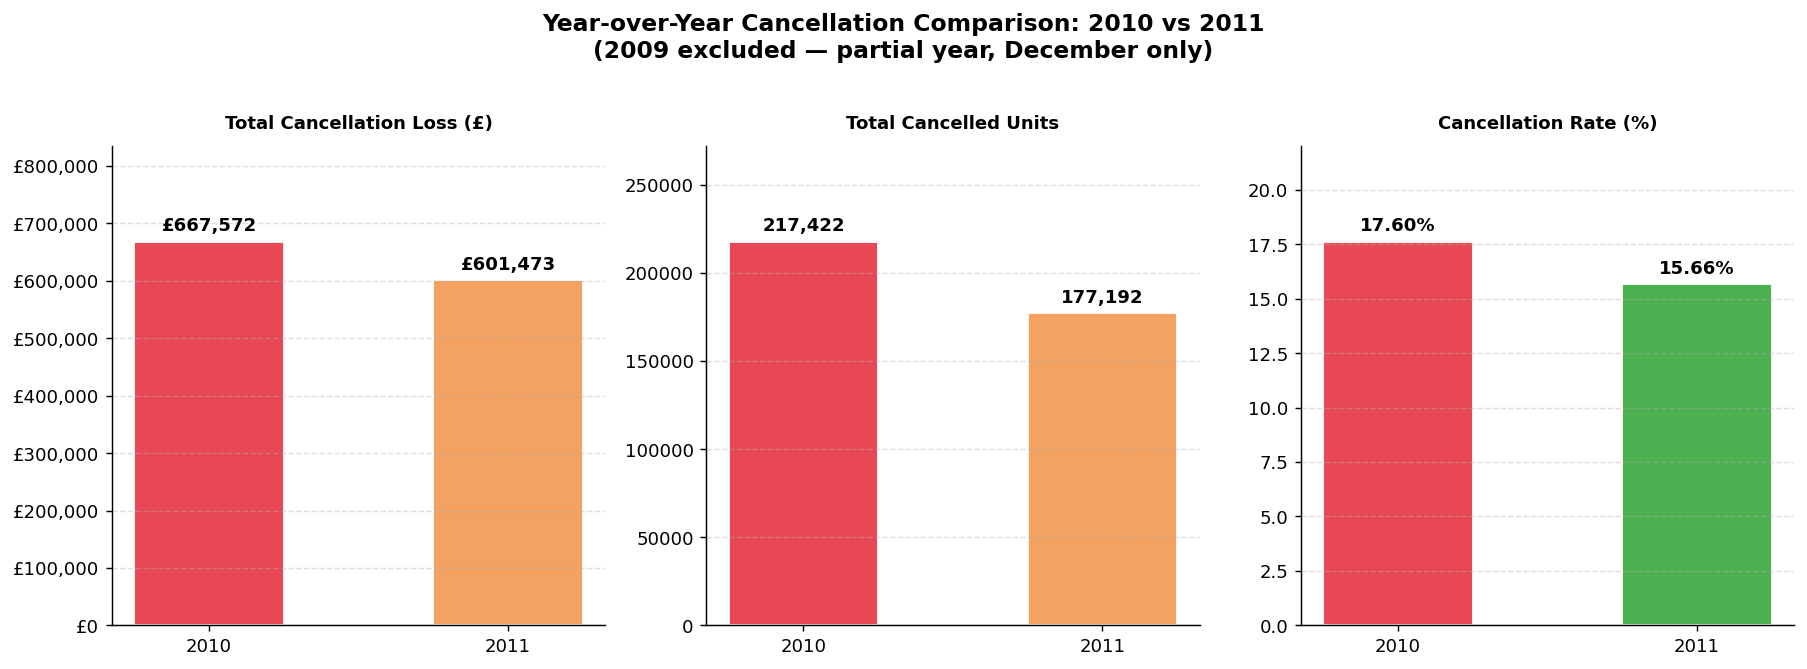

LOSS : 2010 £667,572 → 2011 £601,473 (-9.9%)
RATE : 2010 17.60% → 2011 15.66% (-1.94 pp)
POSITIVE TREND: All metrics improve year on year.


In [8]:
yoy = yearly[yearly.index.isin([2010, 2011])].copy()

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = [
    ('Cancel_Loss_GBP', 'Total Cancellation Loss (£)', [C_RED, C_ORANGE]),
    ('Cancel_Units',    'Total Cancelled Units',        [C_RED, C_ORANGE]),
    ('Cancel_Rate_Pct', 'Cancellation Rate (%)',        [C_RED, C_GREEN])
]
for ax, (col, ylabel, colors) in zip(axes, metrics):
    bars = ax.bar(['2010', '2011'], yoy[col], color=colors, edgecolor='white', width=0.5)
    for bar, val in zip(bars, yoy[col]):
        if col == 'Cancel_Loss_GBP':   label = f'£{val:,.0f}'
        elif col == 'Cancel_Rate_Pct': label = f'{val:.2f}%'
        else:                          label = f'{val:,.0f}'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                label, ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(ylabel, fontsize=10, pad=10)
    ax.set_ylim(0, yoy[col].max() * 1.25)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    if col == 'Cancel_Loss_GBP':
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'£{v:,.0f}'))

fig.suptitle('Year-over-Year Cancellation Comparison: 2010 vs 2011\n'
             '(2009 excluded — partial year, December only)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart4_yoy.png', bbox_inches='tight')
plt.show()

loss_change = ((yoy.loc[2011,'Cancel_Loss_GBP'] - yoy.loc[2010,'Cancel_Loss_GBP'])
               / yoy.loc[2010,'Cancel_Loss_GBP'] * 100)
rate_change  = yoy.loc[2011,'Cancel_Rate_Pct'] - yoy.loc[2010,'Cancel_Rate_Pct']
print(f'LOSS : 2010 £{yoy.loc[2010,"Cancel_Loss_GBP"]:,.0f} → 2011 £{yoy.loc[2011,"Cancel_Loss_GBP"]:,.0f} ({loss_change:+.1f}%)')
print(f'RATE : 2010 {yoy.loc[2010,"Cancel_Rate_Pct"]:.2f}% → 2011 {yoy.loc[2011,"Cancel_Rate_Pct"]:.2f}% ({rate_change:+.2f} pp)')
print('POSITIVE TREND: All metrics improve year on year.')

### 3.3 Monthly Cancellation Loss: Full Two-Year View

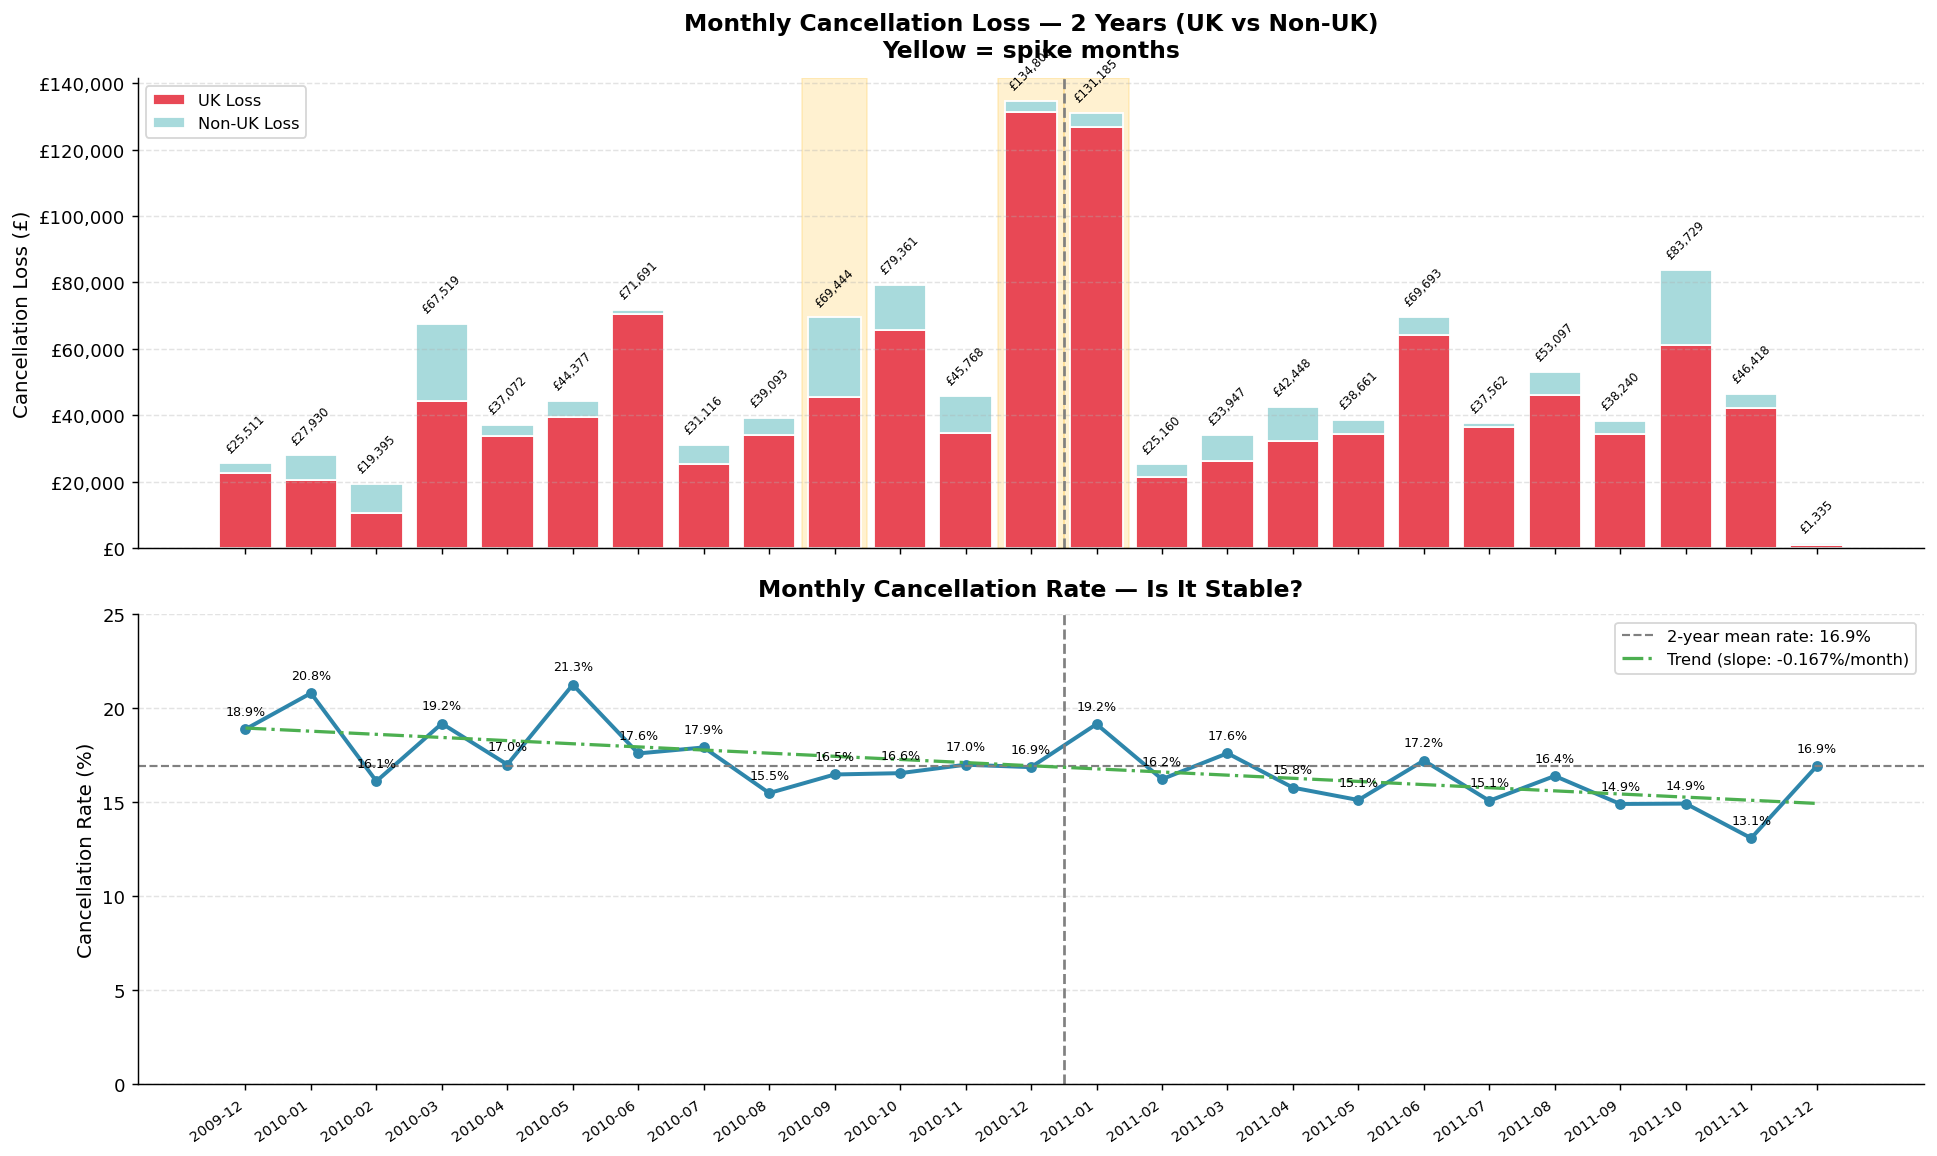

2-year average cancel rate: 16.9% — relatively flat.
Trend slope: -0.167%/month — slight downward trend (improving).
Three notable loss spikes: Sep 2010, Dec 2010, Jan 2011.


In [9]:
m_labels = [str(m) for m in monthly.index]
x = range(len(m_labels))
spike_labels = ['2010-12', '2011-01', '2010-09']
spike_idxs   = [i for i, m in enumerate(m_labels) if m in spike_labels]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

ax1.bar(x, monthly['UK_Loss'].fillna(0),    color=C_RED,  label='UK Loss',     edgecolor='white')
ax1.bar(x, monthly['NonUK_Loss'].fillna(0), color=C_TEAL, label='Non-UK Loss',
        bottom=monthly['UK_Loss'].fillna(0), edgecolor='white')
for i, row in enumerate(monthly.itertuples()):
    ax1.text(i, row.Cancel_Loss_GBP + 2500, f'£{row.Cancel_Loss_GBP:,.0f}',
             ha='center', va='bottom', fontsize=6.5, rotation=45)
for si in spike_idxs:
    ax1.axvspan(si - 0.5, si + 0.5, color=C_YELLOW, alpha=0.3, zorder=0)
year_boundary = m_labels.index('2011-01')
ax1.axvline(x=year_boundary - 0.5, color='grey', linestyle='--', linewidth=1.5)
ax1.set_ylabel('Cancellation Loss (£)')
ax1.set_title('Monthly Cancellation Loss — 2 Years (UK vs Non-UK)\nYellow = spike months', pad=12)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'£{v:,.0f}'))
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(axis='y', linestyle='--', alpha=0.35)

ax2.plot(x, monthly['Cancel_Rate_Pct'], color=C_BLUE, marker='o', linewidth=2.2, markersize=5)
for i, v in enumerate(monthly['Cancel_Rate_Pct']):
    ax2.annotate(f'{v:.1f}%', (i, v), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=7)
mean_rate = monthly['Cancel_Rate_Pct'].mean()
ax2.axhline(y=mean_rate, color='grey', linestyle='--', linewidth=1.2,
            label=f'2-year mean rate: {mean_rate:.1f}%')
ax2.axvline(x=year_boundary - 0.5, color='grey', linestyle='--', linewidth=1.5)
z = np.polyfit(list(x), monthly['Cancel_Rate_Pct'], 1)
p_trend = np.poly1d(z)
ax2.plot(x, p_trend(list(x)), color=C_GREEN, linestyle='-.', linewidth=1.8,
         label=f'Trend (slope: {z[0]:+.3f}%/month)')
ax2.set_ylabel('Cancellation Rate (%)')
ax2.set_title('Monthly Cancellation Rate — Is It Stable?', pad=10)
ax2.set_xticks(x)
ax2.set_xticklabels(m_labels, rotation=35, ha='right', fontsize=8)
ax2.legend(fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.35)
ax2.set_ylim(0, 25)
plt.tight_layout()
plt.savefig('chart5_monthly_2yr.png', bbox_inches='tight')
plt.show()

print(f'2-year average cancel rate: {mean_rate:.1f}% — relatively flat.')
print(f'Trend slope: {z[0]:+.3f}%/month — slight downward trend (improving).')
print('Three notable loss spikes: Sep 2010, Dec 2010, Jan 2011.')

### 3.4 Quarterly Seasonal Pattern

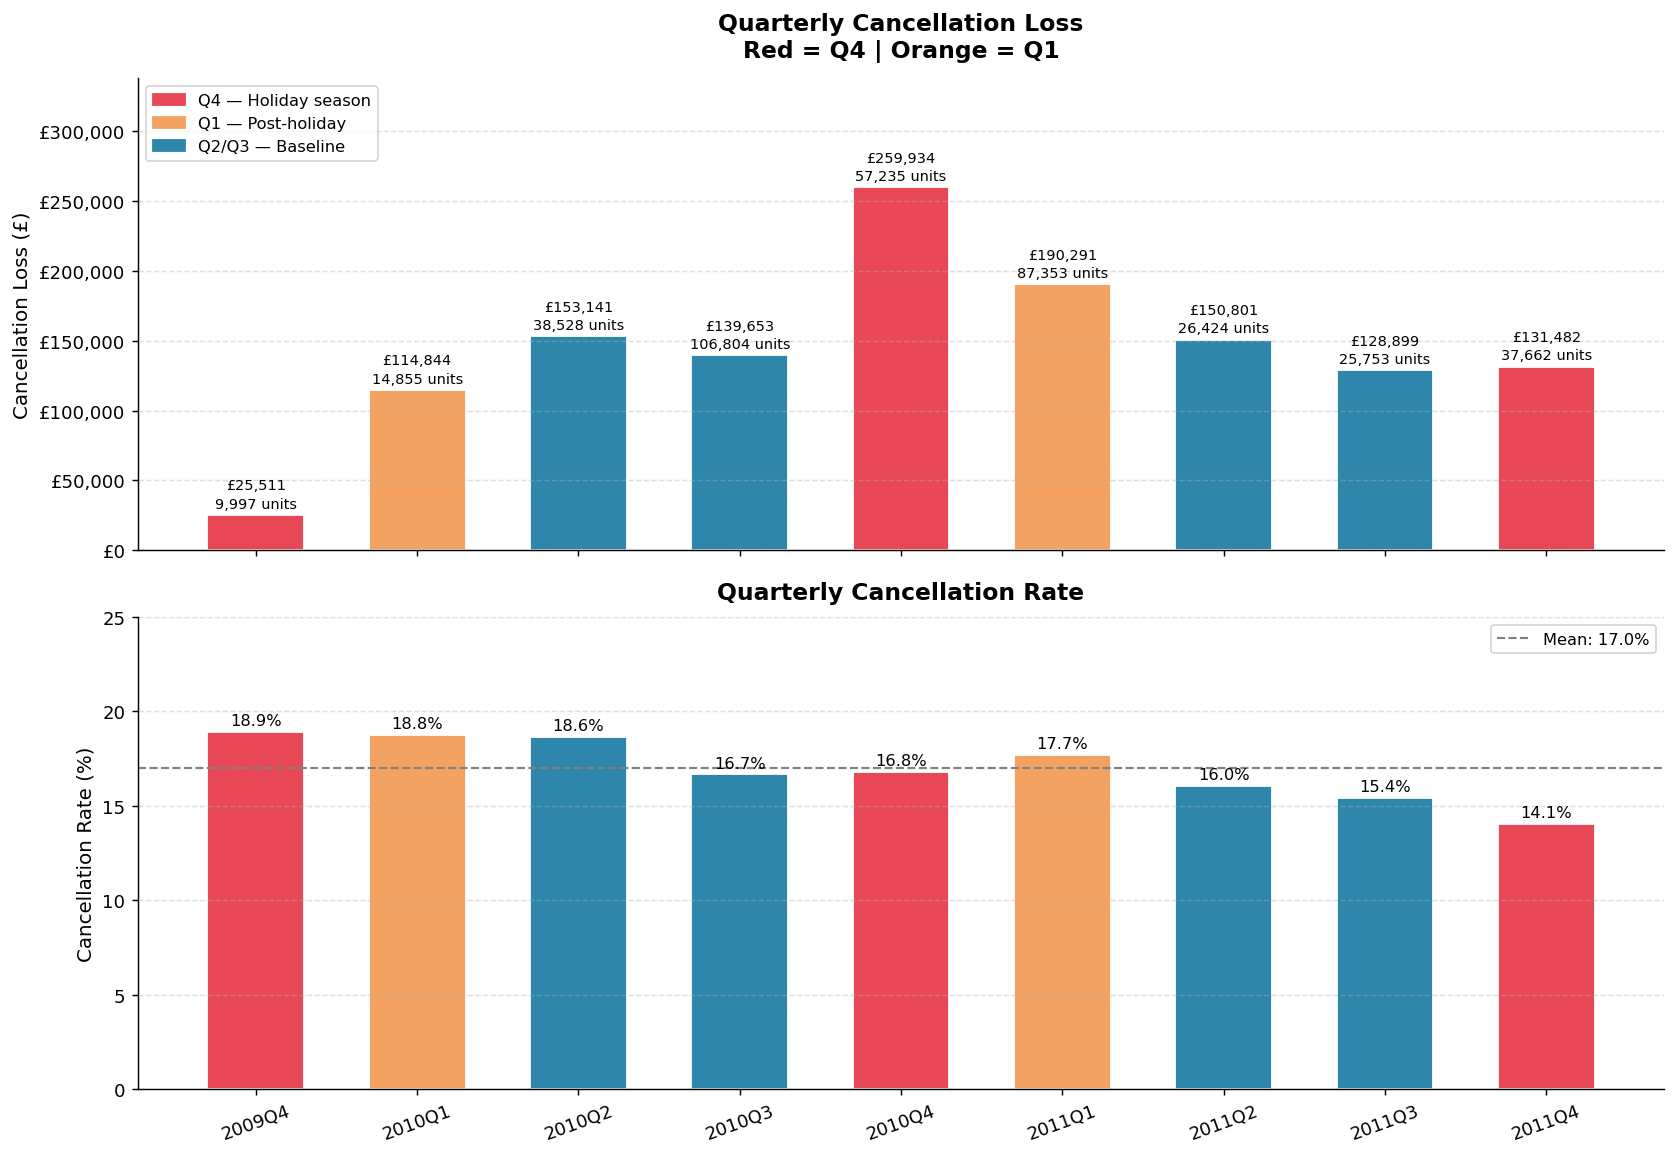

Average Q4 loss: £138,976 vs Q2/Q3 baseline: £143,123
Q4 risk is real but improving year over year.


In [10]:
q_labels   = [str(q) for q in quarterly.index]
bar_colors = []
for q in q_labels:
    if 'Q4' in q:   bar_colors.append(C_RED)
    elif 'Q1' in q: bar_colors.append(C_ORANGE)
    else:           bar_colors.append(C_BLUE)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
bars = ax1.bar(q_labels, quarterly['Cancel_Loss_GBP'], color=bar_colors, edgecolor='white', width=0.6)
for bar, loss, units in zip(bars, quarterly['Cancel_Loss_GBP'], quarterly['Cancel_Units']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000,
             f'£{loss:,.0f}\n{units:,.0f} units', ha='center', va='bottom', fontsize=8, linespacing=1.4)
ax1.set_ylabel('Cancellation Loss (£)')
ax1.set_title('Quarterly Cancellation Loss\nRed = Q4 | Orange = Q1', pad=12)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'£{v:,.0f}'))
ax1.grid(axis='y', linestyle='--', alpha=0.4)
ax1.set_ylim(0, quarterly['Cancel_Loss_GBP'].max() * 1.3)
legend_q = [
    mpatches.Patch(color=C_RED,    label='Q4 — Holiday season'),
    mpatches.Patch(color=C_ORANGE, label='Q1 — Post-holiday'),
    mpatches.Patch(color=C_BLUE,   label='Q2/Q3 — Baseline')
]
ax1.legend(handles=legend_q, fontsize=9, loc='upper left')
ax2.bar(q_labels, quarterly['Cancel_Rate_Pct'], color=bar_colors, edgecolor='white', width=0.6)
for i, v in enumerate(quarterly['Cancel_Rate_Pct']):
    ax2.text(i, v + 0.2, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
ax2.axhline(y=quarterly['Cancel_Rate_Pct'].mean(), color='grey', linestyle='--', linewidth=1.2,
            label=f'Mean: {quarterly["Cancel_Rate_Pct"].mean():.1f}%')
ax2.set_ylabel('Cancellation Rate (%)')
ax2.set_title('Quarterly Cancellation Rate', pad=10)
ax2.legend(fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.4)
ax2.set_ylim(0, 25)
ax2.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('chart6_quarterly.png', bbox_inches='tight')
plt.show()

q4_avg   = quarterly[quarterly.index.astype(str).str.contains('Q4')]['Cancel_Loss_GBP'].mean()
q2q3_avg = quarterly[quarterly.index.astype(str).str.contains('Q[23]')]['Cancel_Loss_GBP'].mean()
print(f'Average Q4 loss: £{q4_avg:,.0f} vs Q2/Q3 baseline: £{q2q3_avg:,.0f}')
print('Q4 risk is real but improving year over year.')

### 3.5 Spike Month Products

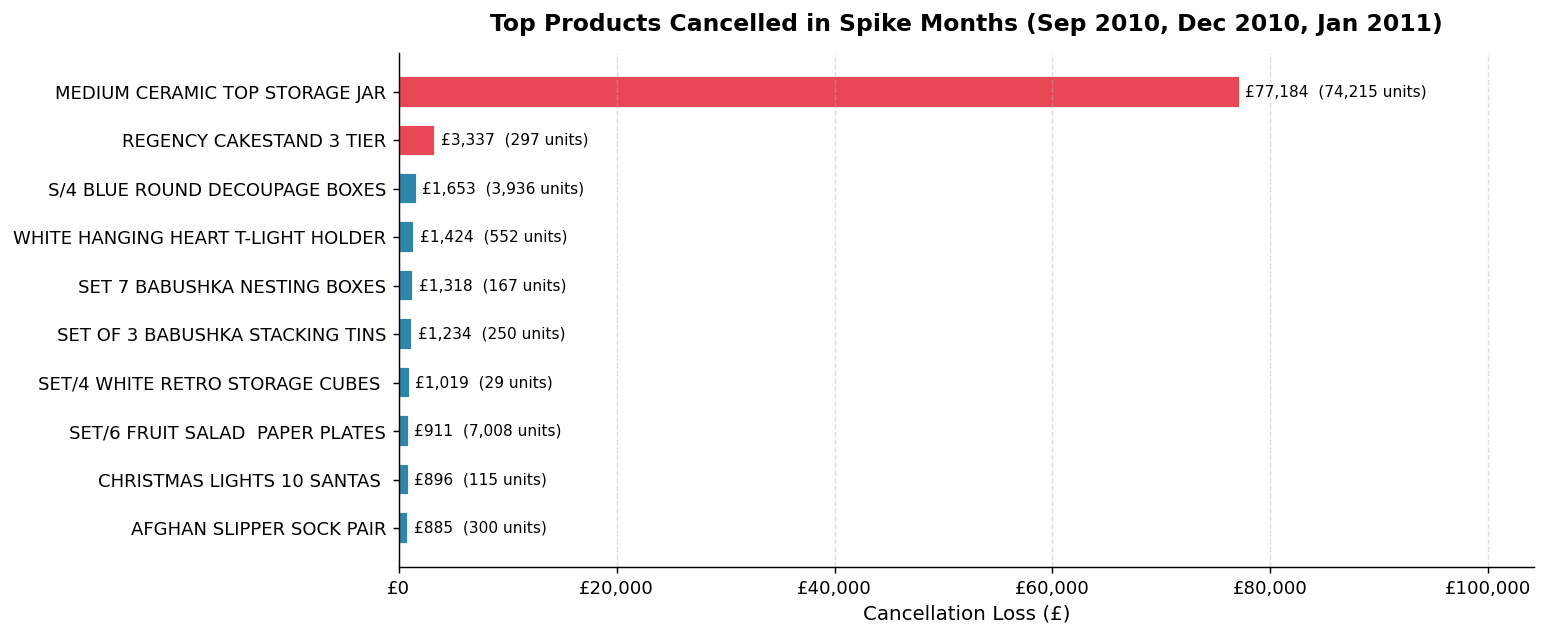

Top SKU: MEDIUM CERAMIC TOP STORAGE JAR — 74,215 units | £77,184
Losses concentrated in 1–2 SKUs — consistent with a bulk B2B event.
→ Handoff to Okah: Is this SKU problematic outside spike months?
→ Handoff to Renato: How many Customer IDs are behind these cancellations?


In [11]:
spike_months = ['2010-09', '2010-12', '2011-01']
spike_df = df[
    (df['Cancelled']) &
    (df['Month'].astype(str).isin(spike_months))
].copy()

exclude_terms = ['AMAZON FEE', 'Manual', 'CRUK', 'Bank Charges', 'Adjust bad debt', 'Discount', 'nan', 'POST']
spike_products = (spike_df
                  .groupby('Description')
                  .agg(
                      Units_Cancelled = ('Quantity', lambda x: x.abs().sum()),
                      Loss_GBP        = ('Loss',     'sum'),
                      Num_Invoices    = ('Invoice',  'nunique')
                  )
                  .sort_values('Loss_GBP', ascending=False))

spike_clean = spike_products[
    ~spike_products.index.str.contains('|'.join(exclude_terms), case=False, na=False)
].head(10).round(2)

fig, ax = plt.subplots(figsize=(12, 5))
colors = [C_RED if i < 2 else C_BLUE for i in range(len(spike_clean))]
bars = ax.barh(spike_clean.index[::-1], spike_clean['Loss_GBP'][::-1],
               color=colors[::-1], edgecolor='white', height=0.65)
for bar, units in zip(bars, spike_clean['Units_Cancelled'][::-1]):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'£{bar.get_width():,.0f}  ({units:,.0f} units)', va='center', fontsize=8.5)
ax.set_xlabel('Cancellation Loss (£)')
ax.set_title('Top Products Cancelled in Spike Months (Sep 2010, Dec 2010, Jan 2011)', pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'£{v:,.0f}'))
ax.set_xlim(0, spike_clean['Loss_GBP'].max() * 1.35)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('chart8_spike_products.png', bbox_inches='tight')
plt.show()

print(f'Top SKU: {spike_clean.index[0]} — {spike_clean["Units_Cancelled"].iloc[0]:,.0f} units | £{spike_clean["Loss_GBP"].iloc[0]:,.0f}')
print('Losses concentrated in 1–2 SKUs — consistent with a bulk B2B event.')
print('→ Handoff to Okah: Is this SKU problematic outside spike months?')
print('→ Handoff to Renato: How many Customer IDs are behind these cancellations?')

---
## Geographic & Temporal Analysis — Summary Insight

The UK represents 85.2% of all cancellation losses — an extreme Pareto result. Germany and EIRE show higher cancellation *rates* than the UK despite lower volumes. Cancellation behavior is mostly consistent across months; loss spikes in Sep 2010, Dec 2010, and Jan 2011 are volume-driven events, not rate-driven. A positive year-over-year trend shows improvement across all metrics from 2010 to 2011.

---
# Section 2. Market Analysis

**Three key questions this section answers:**

1. What share of customers accounts for the majority of return volume?

2. Do high-return customers show distinct purchasing behavior, such as higher order frequency or larger basket sizes?

3. Is there a correlation between purchase frequency and return rate?

---

## 1: What share of customers accounts for the majority of return value?

In [12]:
# ── Filter: Top 6 countries covering 95% of cancellation loss ─────────────────
TOP6_COUNTRIES = ['United Kingdom', 'EIRE', 'France', 'Norway', 'Spain', 'Germany']

df_top6_cancelled = df[
    (df['Is_Return'] == True) &
    (df['Country'].isin(TOP6_COUNTRIES))
].copy()

print(f'Total cancelled rows (top 6 countries) : {len(df_top6_cancelled):,}')
print(f'Countries included                      : {sorted(df_top6_cancelled["Country"].unique())}')
print(f'Date range                              : {df_top6_cancelled["InvoiceDate"].min().date()} → {df_top6_cancelled["InvoiceDate"].max().date()}')
print()

unique_customers        = df_top6_cancelled[cid_col].nunique()
unique_customers_no_nan = df_top6_cancelled[cid_col].dropna().nunique()
print(f'Unique customers (incl. NaN)  : {unique_customers:,}')
print(f'Unique customers (excl. NaN)  : {unique_customers_no_nan:,}')
print()

country_summary = (df_top6_cancelled
                   .groupby('Country')
                   .agg(
                       Cancelled_Rows     = ('Invoice',  'count'),
                       Unique_Customers   = (cid_col,   'nunique'),
                       Cancelled_Invoices = ('Invoice',  'nunique'),
                       Total_Loss_GBP     = ('Loss',     'sum')
                   )
                   .sort_values('Total_Loss_GBP', ascending=False)
                   .round(2))
print(country_summary.to_string())

Total cancelled rows (top 6 countries) : 18,010
Countries included                      : ['EIRE', 'France', 'Germany', 'Norway', 'Spain', 'United Kingdom']
Date range                              : 2009-12-01 → 2011-12-04

Unique customers (incl. NaN)  : 2,423
Unique customers (excl. NaN)  : 2,423

                Cancelled_Rows  Unique_Customers  Cancelled_Invoices  Total_Loss_GBP
Country                                                                             
United Kingdom           16149              2292                7045      1104222.13
EIRE                       508                 3                 178        48357.55
France                     369                42                 113        28228.60
Norway                      18                 4                   8        20866.59
Spain                       81                16                  29        16854.27
Germany                    885                66                 290        12516.40


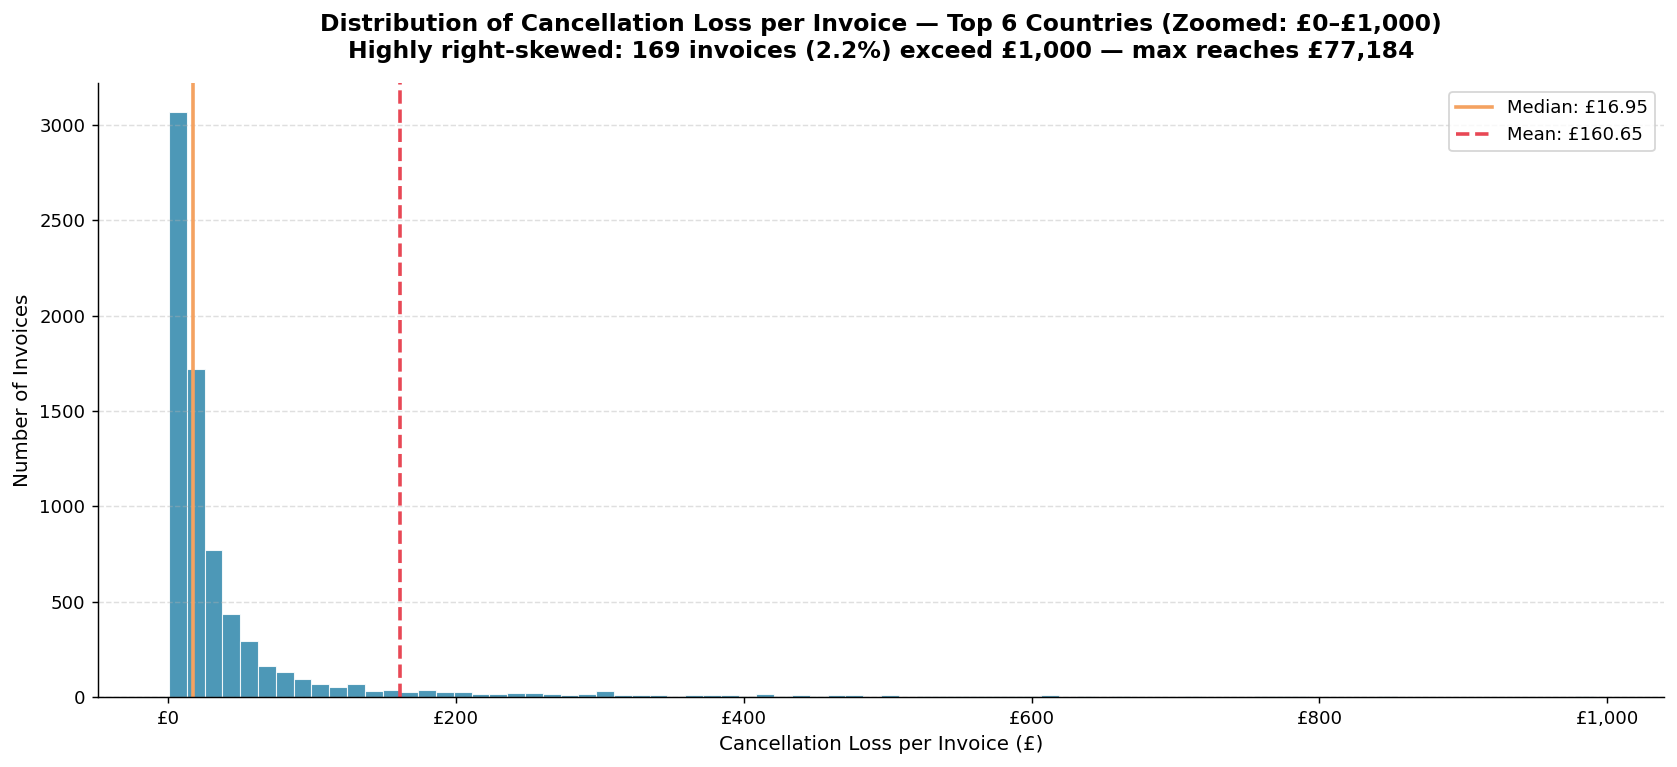

Invoices within £0–£1,000 : 7,494 (97.8%)
Invoices above £1,000     : 169 (2.2%)
Max invoice loss          : £77,183.60
Median                    : £16.95
Mean                      : £160.65


In [13]:
# ── Loss per cancelled invoice — Zoomed histogram £0–£1,000 ──────────────────
invoice_loss = (df_top6_cancelled
                .groupby('Invoice')['Loss']
                .sum()
                .reset_index()
                .rename(columns={'Loss': 'Invoice_Loss'}))

invoice_loss_filtered = invoice_loss[invoice_loss['Invoice_Loss'] <= 1000]
excluded     = len(invoice_loss) - len(invoice_loss_filtered)
excluded_pct = excluded / len(invoice_loss) * 100
max_loss     = invoice_loss['Invoice_Loss'].max()

fig, ax = plt.subplots(figsize=(13, 6))
ax.hist(invoice_loss_filtered['Invoice_Loss'], bins=80, color=C_BLUE,
        edgecolor='white', linewidth=0.6, alpha=0.85)
ax.axvline(invoice_loss['Invoice_Loss'].median(), color=C_ORANGE, linewidth=2,
           label=f'Median: £{invoice_loss["Invoice_Loss"].median():,.2f}')
ax.axvline(invoice_loss['Invoice_Loss'].mean(), color=C_RED, linewidth=2, linestyle='--',
           label=f'Mean: £{invoice_loss["Invoice_Loss"].mean():,.2f}')
ax.set_xlabel('Cancellation Loss per Invoice (£)')
ax.set_ylabel('Number of Invoices')
ax.set_title(
    'Distribution of Cancellation Loss per Invoice — Top 6 Countries (Zoomed: £0–£1,000)\n'
    f'Highly right-skewed: {excluded:,} invoices ({excluded_pct:.1f}%) exceed £1,000 — max reaches £{max_loss:,.0f}',
    pad=14)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('chart_invoice_loss_distribution_zoomed.png', bbox_inches='tight')
plt.show()

print(f'Invoices within £0–£1,000 : {len(invoice_loss_filtered):,} ({100-excluded_pct:.1f}%)')
print(f'Invoices above £1,000     : {excluded:,} ({excluded_pct:.1f}%)')
print(f'Max invoice loss          : £{max_loss:,.2f}')
print(f'Median                    : £{invoice_loss["Invoice_Loss"].median():,.2f}')
print(f'Mean                      : £{invoice_loss["Invoice_Loss"].mean():,.2f}')

In [14]:
# ── Loss per customer per country ─────────────────────────────────────────────
customer_country_loss = (df_top6_cancelled
                         .groupby(['Country', cid_col])['Loss']
                         .sum()
                         .reset_index()
                         .rename(columns={'Loss': 'Total_Loss_GBP'}))

country_stats = (customer_country_loss
                 .groupby('Country')['Total_Loss_GBP']
                 .agg(
                     Num_Customers = 'count',
                     Min           = 'min',
                     Q25           = lambda x: x.quantile(0.25),
                     Median        = 'median',
                     Mean          = 'mean',
                     Q75           = lambda x: x.quantile(0.75),
                     Max           = 'max',
                     Total_Loss    = 'sum'
                 )
                 .round(2)
                 .sort_values('Total_Loss', ascending=False))

print('Customer Loss Distribution by Country (£)')
print('=' * 80)
print(country_stats.to_string())

Customer Loss Distribution by Country (£)
                Num_Customers    Min      Q25    Median      Mean       Q75       Max  Total_Loss
Country                                                                                          
United Kingdom           2292   0.42    15.95     39.88    314.53    117.49  77620.14   720901.80
EIRE                        3  23.70  8702.69  17381.68  14191.60  21275.55  25169.42    42574.80
France                     42   3.90    15.49     86.40    672.11    237.16  12829.34    28228.60
Norway                      4  41.35   124.64    556.52   5216.65   5648.52  19712.21    20866.59
Spain                      16   5.77    19.25     52.62   1053.39    377.24  12387.07    16854.27
Germany                    66   4.95    31.67     61.53    189.64    196.38   1821.98    12516.40


In [15]:
# ── Pareto analysis per country ───────────────────────────────────────────────
pareto_results = []

for country in TOP6_COUNTRIES:
    country_df = customer_country_loss[customer_country_loss['Country'] == country].copy()
    country_df = country_df.sort_values('Total_Loss_GBP', ascending=False)
    total = country_df['Total_Loss_GBP'].sum()
    country_df['Loss_Share_Pct']      = (country_df['Total_Loss_GBP'] / total * 100).round(2)
    country_df['Cumulative_Loss_Pct'] = country_df['Loss_Share_Pct'].cumsum().round(2)
    pareto_results.append(country_df)

pareto_df = pd.concat(pareto_results)

for country in TOP6_COUNTRIES:
    subset     = pareto_df[pareto_df['Country'] == country].copy()
    at_80      = subset[subset['Cumulative_Loss_Pct'] <= 80]
    first_over = subset[subset['Cumulative_Loss_Pct'] > 80].head(1)
    top80      = pd.concat([at_80, first_over]).copy()
    top80[cid_col] = top80[cid_col].apply(
        lambda x: f'Customer {int(x)}' if not pd.isna(x) else 'Unknown')
    print(f'{"=" * 60}')
    print(f'{country} — {len(subset):,} customers | Total Loss: £{subset["Total_Loss_GBP"].sum():,.2f}')
    print(f'Customers needed to reach 80%: {len(top80)}')
    print(f'{"=" * 60}')
    print(top80[[cid_col, 'Total_Loss_GBP', 'Loss_Share_Pct', 'Cumulative_Loss_Pct']].to_string(index=False))
    print()

United Kingdom — 2,292 customers | Total Loss: £720,901.80
Customers needed to reach 80%: 190
   Customer ID  Total_Loss_GBP  Loss_Share_Pct  Cumulative_Loss_Pct
Customer 12346        77620.14           10.77                10.77
Customer 15098        39267.00            5.45                16.22
Customer 14063        26477.40            3.67                19.89
Customer 17399        25111.09            3.48                23.37
Customer 15749        22998.40            3.19                26.56
Customer 16029        21925.44            3.04                29.60
Customer 12918        21907.00            3.04                32.64
Customer 12931        20923.37            2.90                35.54
Customer 17949        19529.99            2.71                38.25
Customer 17450        12370.50            1.72                39.97
Customer 16754        10941.89            1.52                41.49
Customer 18102         9378.01            1.30                42.79
Customer 15413        

In [16]:
# ── Pareto customer lists ─────────────────────────────────────────────────────
def get_pareto_customers(country):
    subset     = pareto_df[pareto_df['Country'] == country].copy()
    at_80      = subset[subset['Cumulative_Loss_Pct'] <= 80]
    first_over = subset[subset['Cumulative_Loss_Pct'] > 80].head(1)
    return pd.concat([at_80, first_over])[cid_col].tolist()

uk_customers      = get_pareto_customers('United Kingdom')
germany_customers = get_pareto_customers('Germany')

print(f'UK Pareto accounts      : {len(uk_customers)}')
print(f'Germany Pareto accounts : {len(germany_customers)}')

UK Pareto accounts      : 190
Germany Pareto accounts : 19


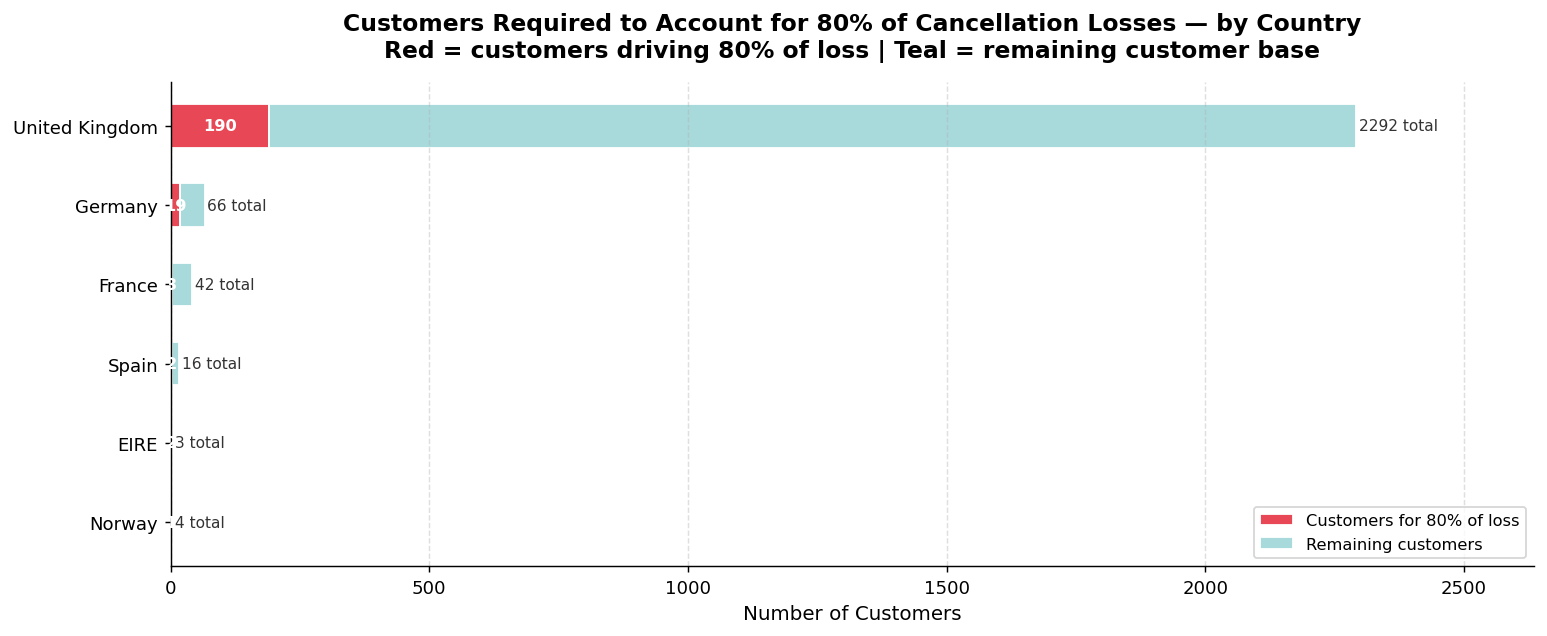

In [17]:
# ── Chart 1: Customers needed to reach 80% vs total ──────────────────────────
customers_for_80 = {}
total_customers  = {}

for country in TOP6_COUNTRIES:
    country_df = customer_country_loss[customer_country_loss['Country'] == country].copy()
    country_df = country_df.sort_values('Total_Loss_GBP', ascending=False)
    total      = country_df['Total_Loss_GBP'].sum()
    country_df['Cumulative_Loss_Pct'] = (country_df['Total_Loss_GBP'] / total * 100).cumsum()
    at_80 = country_df[country_df['Cumulative_Loss_Pct'] <= 80]
    customers_for_80[country] = len(at_80) + 1
    total_customers[country]  = len(country_df)

summary_df = pd.DataFrame({
    'Country':         TOP6_COUNTRIES,
    'For_80_Pct':      [customers_for_80[c] for c in TOP6_COUNTRIES],
    'Total_Customers': [total_customers[c]  for c in TOP6_COUNTRIES]
}).sort_values('For_80_Pct', ascending=True)
summary_df['Others'] = summary_df['Total_Customers'] - summary_df['For_80_Pct']

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.barh(summary_df['Country'], summary_df['For_80_Pct'],
                color=C_RED, edgecolor='white', label='Customers for 80% of loss', height=0.55)
bars2 = ax.barh(summary_df['Country'], summary_df['Others'],
                left=summary_df['For_80_Pct'],
                color=C_TEAL, edgecolor='white', label='Remaining customers', height=0.55)
for bar, val in zip(bars1, summary_df['For_80_Pct']):
    ax.text(bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
            f'{val}', ha='center', va='center', fontsize=9, fontweight='bold', color='white')
for bar, total in zip(bars2, summary_df['Total_Customers']):
    ax.text(bar.get_x() + bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            f'{total} total', ha='left', va='center', fontsize=8.5, color='#333')
ax.set_xlabel('Number of Customers')
ax.set_title('Customers Required to Account for 80% of Cancellation Losses — by Country\n'
             'Red = customers driving 80% of loss | Teal = remaining customer base', pad=14)
ax.legend(fontsize=9, loc='lower right')
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.set_xlim(0, summary_df['Total_Customers'].max() * 1.15)
plt.tight_layout()
plt.savefig('chart_customers_80pct.png', bbox_inches='tight')
plt.show()

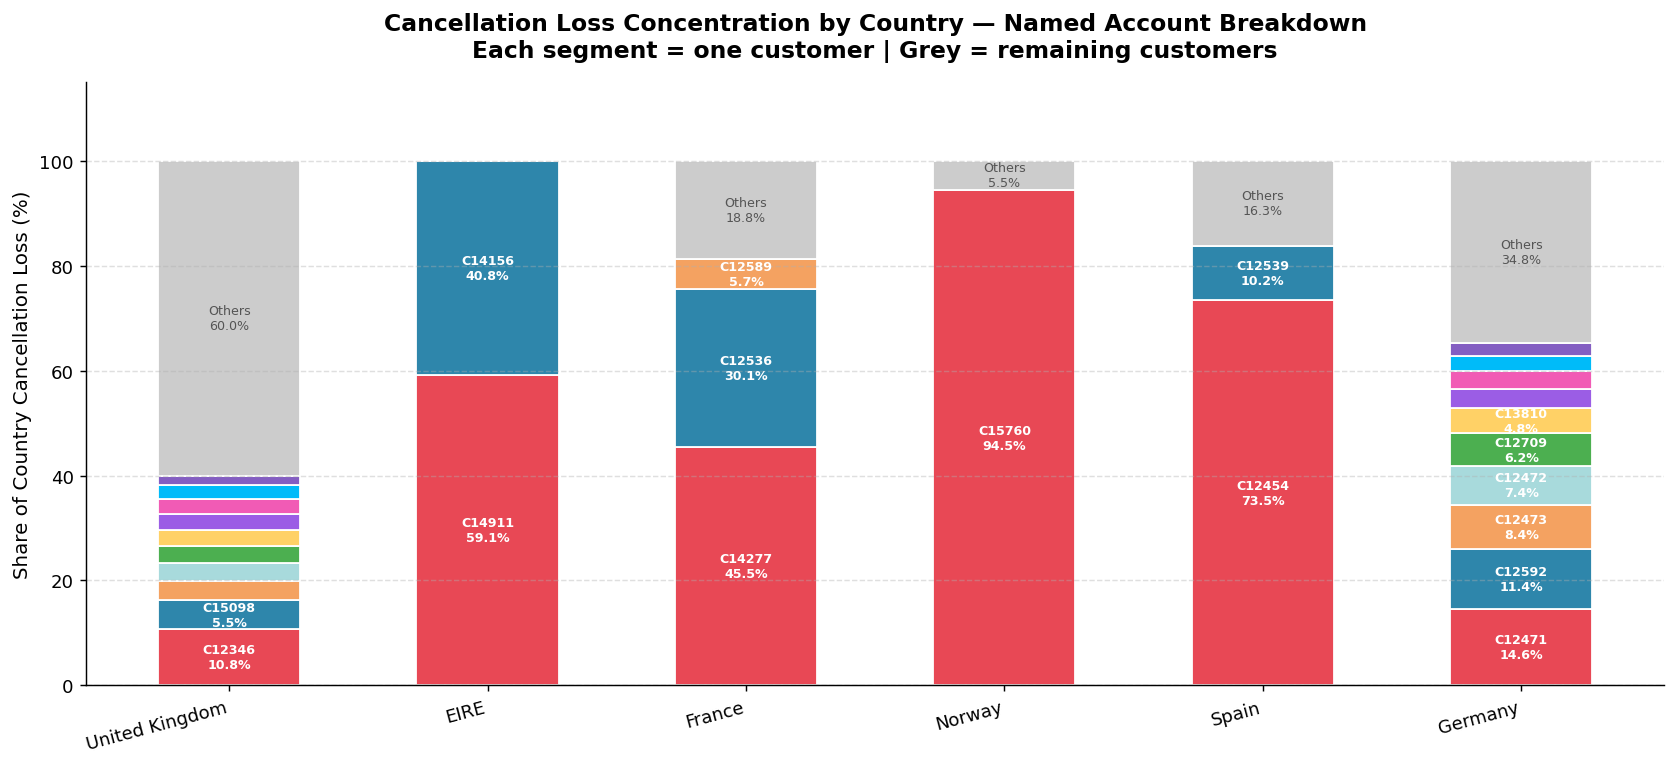

In [18]:
# ── Chart 2: Stacked loss share per country ───────────────────────────────────
COLORS_PALETTE = [C_RED, C_BLUE, C_ORANGE, C_TEAL, C_GREEN,
                  C_YELLOW, '#9B5DE5', '#F15BB5', '#00BBF9', '#845EC2']
TOP_N = {'United Kingdom': 10, 'EIRE': 2, 'France': 3, 'Norway': 1, 'Spain': 2, 'Germany': 10}

fig, ax = plt.subplots(figsize=(13, 6))
bar_positions = range(len(TOP6_COUNTRIES))
bottom        = [0] * len(TOP6_COUNTRIES)

for i, country in enumerate(TOP6_COUNTRIES):
    country_df = customer_country_loss[customer_country_loss['Country'] == country].copy()
    country_df = country_df.sort_values('Total_Loss_GBP', ascending=False)
    total      = country_df['Total_Loss_GBP'].sum()
    country_df['Loss_Share_Pct'] = (country_df['Total_Loss_GBP'] / total * 100).round(2)
    top_n  = TOP_N[country]
    top_df = country_df.head(top_n)
    others = 100 - top_df['Loss_Share_Pct'].sum()
    for j, (_, row) in enumerate(top_df.iterrows()):
        color = COLORS_PALETTE[j % len(COLORS_PALETTE)]
        ax.bar(i, row['Loss_Share_Pct'], bottom=bottom[i], color=color, edgecolor='white', width=0.55)
        if row['Loss_Share_Pct'] > 4:
            ax.text(i, bottom[i] + row['Loss_Share_Pct'] / 2,
                    f'C{int(row[cid_col])}\n{row["Loss_Share_Pct"]:.1f}%',
                    ha='center', va='center', fontsize=7, fontweight='bold', color='white')
        bottom[i] += row['Loss_Share_Pct']
    if others > 0:
        ax.bar(i, others, bottom=bottom[i], color='#CCCCCC', edgecolor='white', width=0.55)
        if others > 4:
            ax.text(i, bottom[i] + others / 2, f'Others\n{others:.1f}%',
                    ha='center', va='center', fontsize=7, color='#555')
        bottom[i] += others

ax.set_xticks(list(bar_positions))
ax.set_xticklabels(TOP6_COUNTRIES, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('Share of Country Cancellation Loss (%)')
ax.set_ylim(0, 115)
ax.set_title('Cancellation Loss Concentration by Country — Named Account Breakdown\n'
             'Each segment = one customer | Grey = remaining customers', pad=14)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('chart_loss_concentration_stacked.png', bbox_inches='tight')
plt.show()

**Insight**

**EIRE — £42,574.80 | 3 customers**

Two accounts explain virtually all of EIRE's cancellation losses. Customer 14911 accounts for 59.12% (£25,169) and Customer 14156 for a further 40.83% (£17,381). Resolving these two accounts eliminates the problem.

---

**Norway — £20,866.59 | 4 customers**

Customer 15760 is responsible for £19,712 — 94.47% of Norway's total cancellation loss. The remaining three customers are negligible. Note: the majority of these losses are StockCode M manual entries — real losses but with no product detail attached.

---

**France — £28,228.60 | 42 customers**

Three accounts drive 81.20% of French losses. Customer 14277 leads at 45.45% (£12,829), followed by Customer 12536 at 30.09% (£8,495), with Customer 12589 contributing 5.66% (£1,598).

---

**Spain — £16,854.27 | 16 customers**

Customer 12454 alone represents 73.50% of Spain's total losses at £12,387. Customer 12539 adds a further 10.18%.

---

**Germany — £12,516.40 | 66 customers**

Germany has no dominant account. The largest customer represents only 14.56% of losses, and 19 customers are required to reach the 80% threshold. Customer segmentation is recommended to identify shared behavioral patterns.

---

**United Kingdom — £720,901.80 | 2,292 customers**

The UK represents 85.2% of total cancellation losses. Customer 12346 (£77,620, 10.77%) and Customer 15098 (£39,267, 5.45%) merit individual review, but reaching 80% requires 190 customers. K-Means clustering on the full 190 Pareto accounts is strongly recommended.

---
## 2: Do high-return customers show distinct purchasing behavior?

### RFMR Score Scale — 1 to 5 (Quintile-based)

Each dimension is split into 5 equal groups (20% of accounts each). Score 5 = highest risk, score 1 = lowest risk. Scores are calculated independently within each country group.

| Score | Percentile | Meaning |
|:---|:---|:---|
| 5 | Top 20% | Highest risk |
| 4 | 60th – 80th | Above average |
| 3 | 40th – 60th | Middle |
| 2 | 20th – 40th | Below average |
| 1 | Bottom 20% | Lowest risk |

> **R (Recency):** Inverted — score 5 = cancelled most recently = highest active risk.  
> **F:** Total order frequency across all invoices (not just cancellations).  
> **M:** Total gross purchases in £.  
> **Re:** Total cancellation loss in £ (not a ratio).

In [19]:
# ── RFMR: Build from full df ──────────────────────────────────────────────────
DATASET_END = df['InvoiceDate'].max()

total_frequency = (df[df['Is_Return'] == False]
                   .groupby(cid_col)['Invoice']
                   .nunique()
                   .reset_index()
                   .rename(columns={'Invoice': 'F_TotalOrders'}))

gross = (df[df['Is_Return'] == False]
         .assign(GrossValue=lambda x: x['Quantity'] * x['Price'])
         .groupby(cid_col)['GrossValue']
         .sum()
         .reset_index()
         .rename(columns={'GrossValue': 'M_GrossPurchases'}))

cancel_rfmr = (df_top6_cancelled
               .groupby(cid_col)
               .agg(
                   R_LastCancel  = ('InvoiceDate', 'max'),
                   Re_CancelLoss = ('Loss',        'sum')
               )
               .reset_index())

cancel_rfmr['R_Recency'] = (DATASET_END - cancel_rfmr['R_LastCancel']).dt.days

rfmr = (cancel_rfmr
        .merge(total_frequency, on=cid_col, how='left')
        .merge(gross,           on=cid_col, how='left'))

rfmr['F_TotalOrders']    = rfmr['F_TotalOrders'].fillna(0)
rfmr['M_GrossPurchases'] = rfmr['M_GrossPurchases'].fillna(0)
rfmr['Country']          = (df_top6_cancelled
                             .groupby(cid_col)['Country']
                             .first()
                             .reset_index()['Country'])

display_cols = [cid_col, 'Country', 'R_Recency', 'F_TotalOrders',
                'M_GrossPurchases', 'Re_CancelLoss']

rfmr_uk      = rfmr[rfmr[cid_col].isin(uk_customers)].copy()
rfmr_germany = rfmr[rfmr[cid_col].isin(germany_customers)].copy()

print(f'RFMR built: {len(rfmr):,} customers')
print(f'UK group     : {len(rfmr_uk)} accounts')
print(f'Germany group: {len(rfmr_germany)} accounts')

RFMR built: 2,423 customers
UK group     : 190 accounts
Germany group: 19 accounts


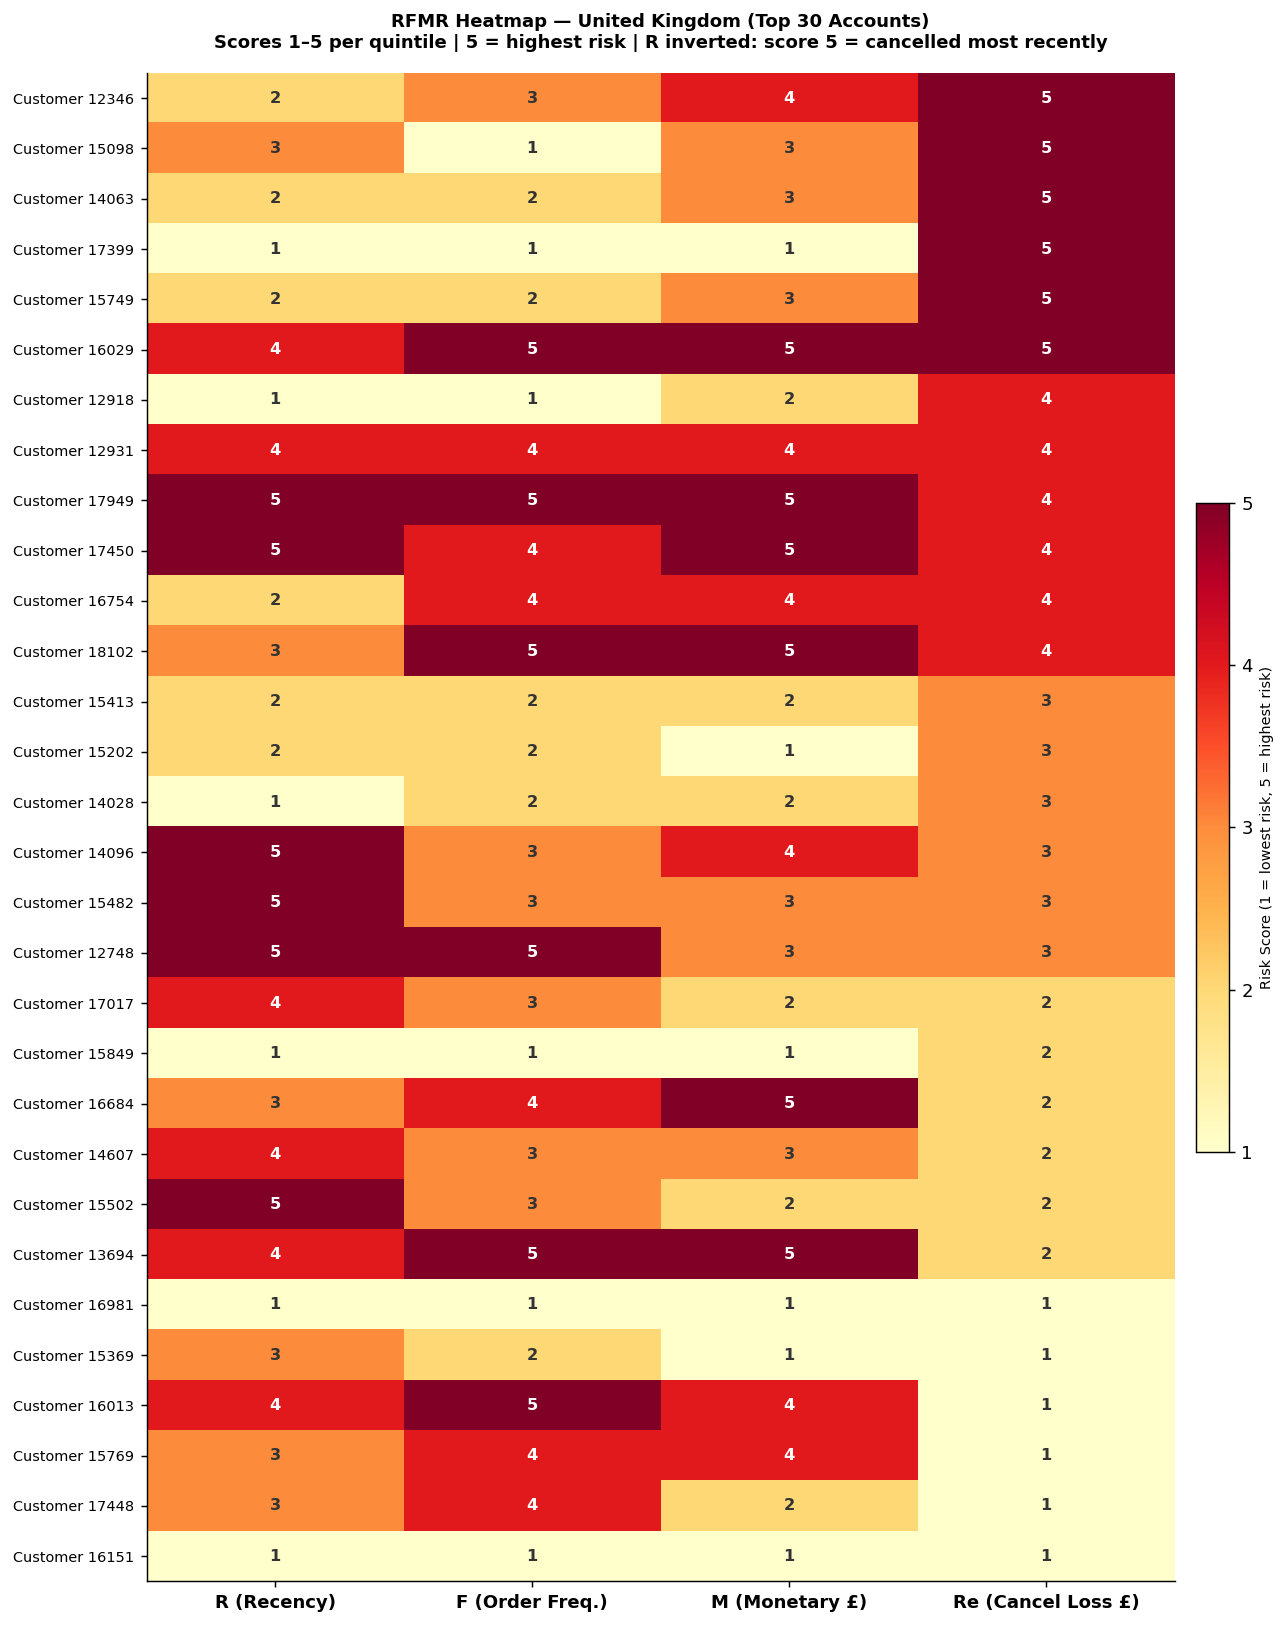

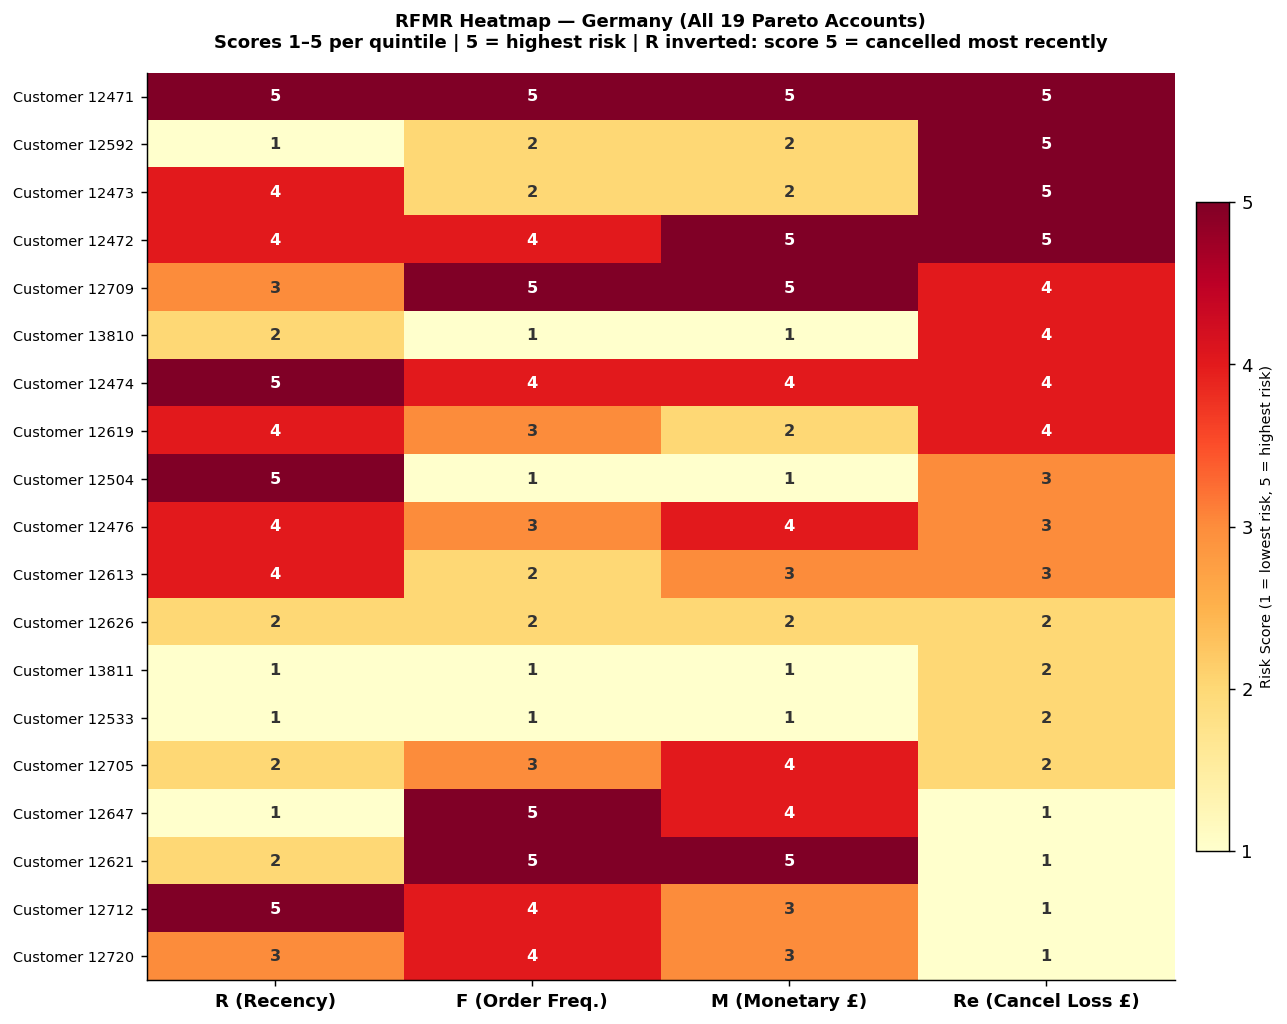

In [20]:
# ── Scoring function (1–5 quintiles) ─────────────────────────────────────────
def score_rfmr(group_df, top_n=None):
    df_plot = group_df[display_cols].copy()
    df_plot = df_plot.sort_values('Re_CancelLoss', ascending=False)
    if top_n:
        df_plot = df_plot.head(top_n)
    df_plot['Re_CancelLoss'] = df_plot['Re_CancelLoss'].fillna(0)
    df_plot['Label'] = df_plot[cid_col].apply(
        lambda x: f'Customer {int(x)}' if not pd.isna(x) else 'Unknown')
    df_plot = df_plot.set_index('Label')
    scored = pd.DataFrame(index=df_plot.index)
    scored['R (Recency)']        = pd.qcut(df_plot['R_Recency'],
                                            q=5, labels=[5,4,3,2,1]).astype(int)
    scored['F (Order Freq.)']    = pd.qcut(df_plot['F_TotalOrders'].rank(method='first'),
                                            q=5, labels=[1,2,3,4,5]).astype(int)
    scored['M (Monetary £)']     = pd.qcut(df_plot['M_GrossPurchases'].rank(method='first'),
                                            q=5, labels=[1,2,3,4,5]).astype(int)
    scored['Re (Cancel Loss £)'] = pd.qcut(df_plot['Re_CancelLoss'].rank(method='first'),
                                            q=5, labels=[1,2,3,4,5]).astype(int)
    return scored

# ── Heatmap function ──────────────────────────────────────────────────────────
def plot_rfmr_heatmap(scored_df, title):
    n_rows  = len(scored_df)
    fig_h   = max(6, n_rows * 0.42)
    fig, ax = plt.subplots(figsize=(10, fig_h))
    im = ax.imshow(scored_df.values.astype(float),
                   aspect='auto', cmap='YlOrRd', vmin=1, vmax=5)
    ax.set_xticks(range(len(scored_df.columns)))
    ax.set_xticklabels(scored_df.columns, fontsize=10, fontweight='bold')
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels(scored_df.index, fontsize=8)
    for i in range(n_rows):
        for j in range(len(scored_df.columns)):
            val   = scored_df.iloc[i, j]
            color = 'white' if val >= 4 else '#333333'
            ax.text(j, i, str(val), ha='center', va='center',
                    fontsize=9, fontweight='bold', color=color)
    cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_ticks([1, 2, 3, 4, 5])
    cbar.set_label('Risk Score (1 = lowest risk, 5 = highest risk)', fontsize=8)
    ax.set_title(
        f'{title}\nScores 1–5 per quintile | 5 = highest risk | R inverted: score 5 = cancelled most recently',
        pad=14, fontsize=10)
    plt.tight_layout()
    fname = title.lower().replace(' ', '_').replace('/', '').replace('—','').strip() + '.png'
    plt.savefig(fname, bbox_inches='tight', dpi=150)
    plt.show()

# ── Plot UK top 30 and Germany all 19 ────────────────────────────────────────
plot_rfmr_heatmap(score_rfmr(rfmr_uk, top_n=30),
                  'RFMR Heatmap — United Kingdom (Top 30 Accounts)')

plot_rfmr_heatmap(score_rfmr(rfmr_germany),
                  'RFMR Heatmap — Germany (All 19 Pareto Accounts)')

# Note: EIRE, France, Norway, Spain heatmaps excluded.
# Quintile scoring is not meaningful for groups dominated by 1–2 customers.
# These accounts are fully covered in the Pareto analysis above.

**Insight:**

Not uniformly. In the **UK**, high cancellation-loss customers are mostly medium-to-large buyers who canceled once and went quiet — order size, not behavior, is the differentiator. Low recency and low frequency confirm they are not chronic returners.

In **Germany**, two profiles emerge:

- *The One-Time Disengaged Buyer* (R: 4–5, F: 2, M: 2) — recent, low-frequency, low-spending customers who likely canceled and never came back. Possible product-market fit issue.
- *The High-Value Chronic Canceller* (R: 4–5, F: 4–5, M: 4–5) — frequent, high-spending customers with ongoing cancellation patterns. Suggests operational friction or speculative ordering behavior.

Unlike the UK, Germany's problem is active and current — not historical.

No single behavioral profile defines a high-return customer across both markets. **K-Means clustering on the full 190 UK and 19 Germany Pareto accounts is recommended** as a next step.

---
## 3: Is there a correlation between purchase frequency and return rate?

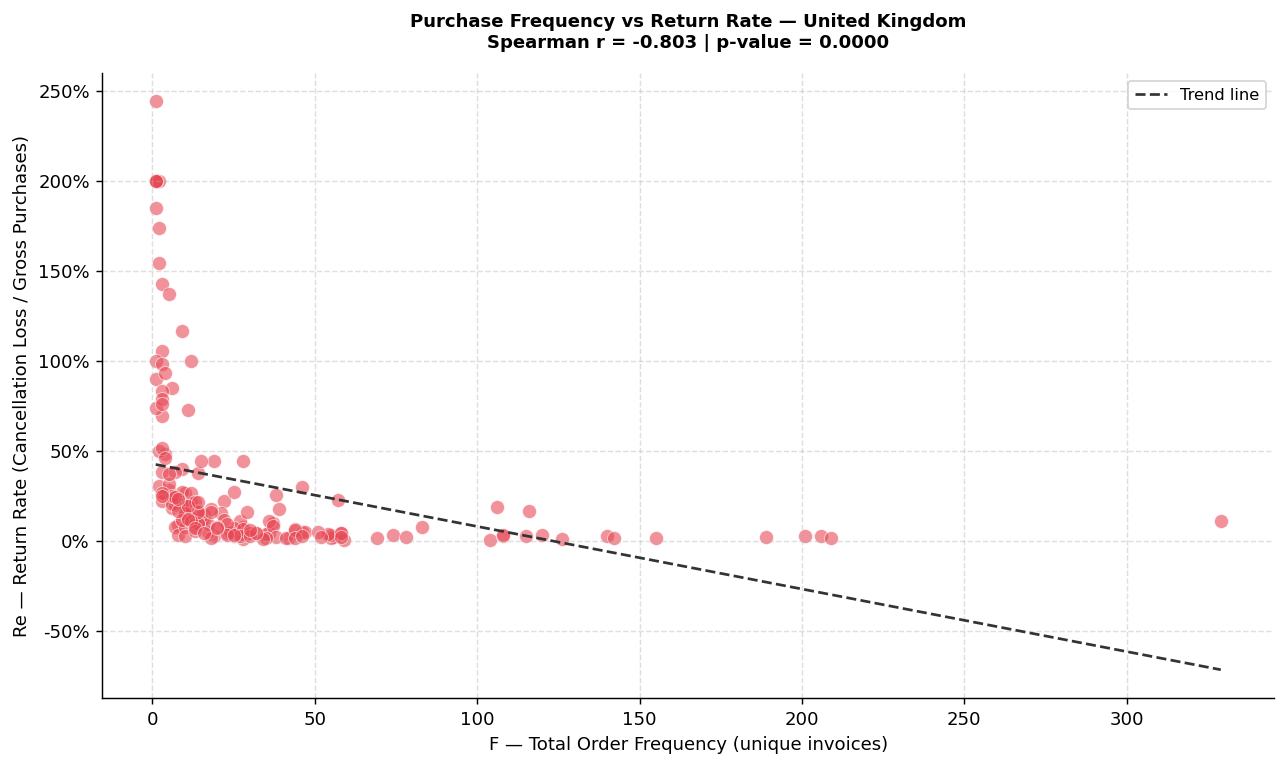

Spearman correlation : -0.803
P-value              : 0.0000
Interpretation       : statistically significant



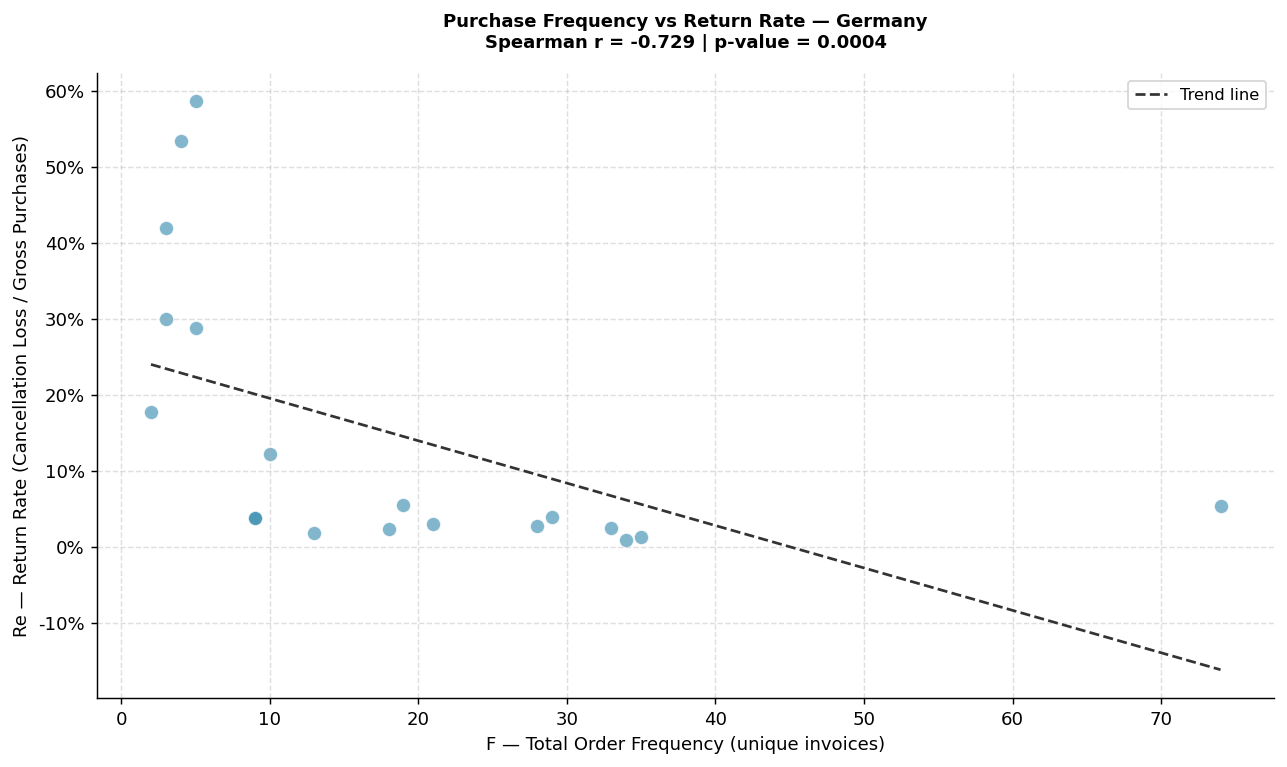

Spearman correlation : -0.729
P-value              : 0.0004
Interpretation       : statistically significant



In [21]:
from scipy.stats import spearmanr

# ── Return rate ratio for correlation ─────────────────────────────────────────
rfmr_corr = rfmr.copy()
rfmr_corr['Re_Ratio'] = (rfmr_corr['Re_CancelLoss'] /
                          rfmr_corr['M_GrossPurchases'].replace(0, float('nan'))).round(4)

rfmr_uk_corr      = rfmr_corr[rfmr_corr[cid_col].isin(uk_customers)].dropna(subset=['Re_Ratio'])
rfmr_germany_corr = rfmr_corr[rfmr_corr[cid_col].isin(germany_customers)].dropna(subset=['Re_Ratio'])

def plot_correlation_scatter(df_plot, title, color):
    x = df_plot['F_TotalOrders']
    y = df_plot['Re_Ratio']
    corr, pvalue = spearmanr(x, y)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(x, y, color=color, alpha=0.6, edgecolors='white', linewidths=0.5, s=60)
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    ax.plot(sorted(x), p(sorted(x)), color='#333333', linestyle='--', linewidth=1.5, label='Trend line')
    ax.set_xlabel('F — Total Order Frequency (unique invoices)', fontsize=10)
    ax.set_ylabel('Re — Return Rate (Cancellation Loss / Gross Purchases)', fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax.set_title(f'{title}\nSpearman r = {corr:.3f} | p-value = {pvalue:.4f}', pad=14, fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(linestyle='--', alpha=0.4)
    plt.tight_layout()
    fname = title.lower().replace(' ', '_').replace('—', '').strip() + '.png'
    plt.savefig(fname, bbox_inches='tight', dpi=150)
    plt.show()
    print(f'Spearman correlation : {corr:.3f}')
    print(f'P-value              : {pvalue:.4f}')
    print(f'Interpretation       : {"statistically significant" if pvalue < 0.05 else "not statistically significant"}')
    print()

plot_correlation_scatter(rfmr_uk_corr,
                         'Purchase Frequency vs Return Rate — United Kingdom', C_RED)
plot_correlation_scatter(rfmr_germany_corr,
                         'Purchase Frequency vs Return Rate — Germany', C_BLUE)

**Insight:**

Yes, and the direction is **negative**. Customers who order more frequently tend to cancel a smaller proportion of their purchases. The Spearman correlation confirms that this relationship is statistically significant.

**L-shaped distribution:** Low-frequency customers show a wide and unpredictable spread of return rates. As frequency increases, return rates converge toward zero and become consistent. Loyalty stabilizes cancellation behavior.

**Return rates above 100%:** A small number of customers show return rates above 100% (~250% max). This is mathematically possible when cancellation losses exceed recorded gross purchases — likely due to timing mismatches or StockCode M manual entries. These are edge cases and do not affect the overall correlation finding.

**In short:** Frequent buyers are lower risk. The danger zone is infrequent buyers whose behavior is unpredictable. Retaining frequent customers reduces both revenue risk and cancellation exposure.

---
# Section 3: Product Analysis

**Three key questions this section answers:**

5.1. Which products have the highest return rates as a share of units sold?

5.2. Do high-return products share characteristics such as price range or category?

5.3. Does a Pareto pattern hold — do a small number of products account for most returns?

---

In [22]:
# ── Product-specific filtering ────────────────────────────────────────────────
# This section requires additional cleaning beyond the shared cleaning cell.
# StockCode M (manual adjustments), S, AMAZONFEE, DOT, CRUK, BANK CHARGES
# have no product detail and are excluded from SKU-level analysis only.
# df remains unchanged for geographic and customer sections above.

NON_PRODUCT_EXTRA = ['M', 'S', 'AMAZONFEE', 'DOT', 'CRUK', 'BANK CHARGES']

df_product = df[~df['StockCode'].str.upper().isin(
    [x.upper() for x in NON_PRODUCT_EXTRA])].copy()
df_product = df_product[~df_product['StockCode'].str.upper().str.startswith('ADJUST')].copy()

cancelled_product = df_product[df_product['Cancelled']].copy()

print(f'Total transactions (product-cleaned) : {len(df_product):,}')
print(f'Cancelled rows (product-cleaned)     : {len(cancelled_product):,}')
print(f'Unique products (cancelled)          : {cancelled_product["StockCode"].nunique():,}')
print(f'Total cancellation loss              : £{cancelled_product["Loss"].sum():,.2f}')
print()
print('Note: StockCode M and other non-product codes excluded from this section only.')

Total transactions (product-cleaned) : 1,036,986
Cancelled rows (product-cleaned)     : 18,073
Unique products (cancelled)          : 2,874
Total cancellation loss              : £554,101.88

Note: StockCode M and other non-product codes excluded from this section only.


## 1. Pareto Analysis — Which Products Drive the Most Loss?
> **Q3:** Do a small number of products account for most cancellation losses?

In [23]:
prod = (cancelled_product
        .groupby(['StockCode', 'Description'])
        .agg(
            cancel_units    = ('Quantity',  lambda x: x.abs().sum()),
            cancel_loss     = ('Loss',      'sum'),
            cancel_invoices = ('Invoice',   'nunique')
        )
        .sort_values('cancel_loss', ascending=False)
        .reset_index())

sold = df_product[~df_product['Cancelled']].groupby('StockCode')['Quantity'].sum().rename('sold_units')
prod = prod.merge(sold.reset_index(), on='StockCode', how='left')
prod['return_rate_pct'] = (
    prod['cancel_units'] / (prod['cancel_units'] + prod['sold_units'].fillna(0)) * 100
).round(1)

total_loss_prod         = prod['cancel_loss'].sum()
prod['loss_share_pct']  = (prod['cancel_loss'] / total_loss_prod * 100).round(2)
prod['cumulative_loss'] = prod['loss_share_pct'].cumsum().round(2)

n_total = len(prod)
n_80    = (prod['cumulative_loss'] <= 80).sum()

print(f'Total SKUs with cancellations : {n_total:,}')
print(f'SKUs needed to reach 80% loss : {n_80} ({n_80/n_total*100:.1f}% of all cancelled SKUs)')
print()
print('Top 10 products by cancellation loss:')
print(prod.head(10)[['cancel_units','cancel_loss','cancel_invoices',
                      'return_rate_pct','loss_share_pct','cumulative_loss']].to_string())

Total SKUs with cancellations : 3,056
SKUs needed to reach 80% loss : 464 (15.2% of all cancelled SKUs)

Top 10 products by cancellation loss:
   cancel_units  cancel_loss  cancel_invoices  return_rate_pct  loss_share_pct  cumulative_loss
0         74494     77479.64               10             48.9           13.98            13.98
1          1460     16658.40              338              5.1            3.01            16.99
2          3637      9386.70              133              3.7            1.69            18.68
3          2523      6976.41               60             14.1            1.26            19.94
4          3159      6614.37                4             19.6            1.19            21.13
5          1072      6331.30              119             26.3            1.14            22.27
6           147      5187.65               20             11.5            0.94            23.21
7           946      4803.06                6             45.2            0.87           

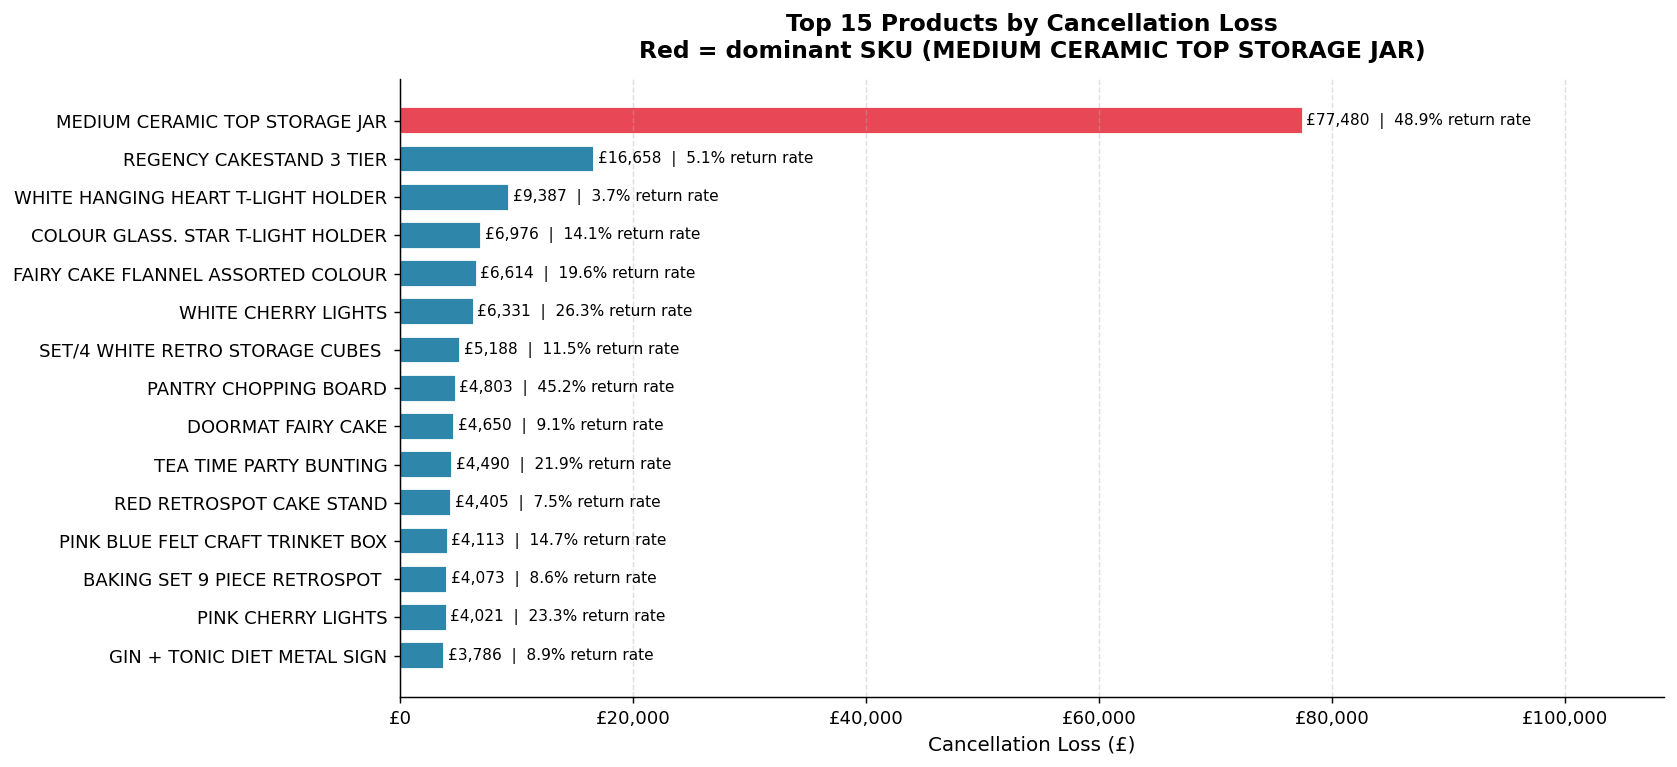


Business Insight: 464 SKUs (15.2%) account for 80% of all cancellation loss.
Less extreme than geographic Pareto — product interventions must be paired with account-level actions.


In [24]:
top15 = prod.head(15).copy()

fig, ax = plt.subplots(figsize=(13, 6))
colors = [C_RED if i == 0 else C_BLUE for i in range(len(top15))]
bars = ax.barh(top15['Description'][::-1], top15['cancel_loss'][::-1],
               color=colors[::-1], edgecolor='white', height=0.7)
for bar, rate in zip(bars, top15['return_rate_pct'][::-1]):
    ax.text(bar.get_width() + 300, bar.get_y() + bar.get_height() / 2,
            f'£{bar.get_width():,.0f}  |  {rate:.1f}% return rate', va='center', fontsize=8.5)
ax.set_xlabel('Cancellation Loss (£)')
ax.set_title('Top 15 Products by Cancellation Loss\nRed = dominant SKU (MEDIUM CERAMIC TOP STORAGE JAR)', pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'£{v:,.0f}'))
ax.set_xlim(0, top15['cancel_loss'].max() * 1.4)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('prod_chart1_pareto.png', bbox_inches='tight')
plt.show()

print()
print(f'Business Insight: {n_80} SKUs ({n_80/n_total*100:.1f}%) account for 80% of all cancellation loss.')
print('Less extreme than geographic Pareto — product interventions must be paired with account-level actions.')

## 2. Price Band Analysis
> **Q2:** Do high-return products share characteristics such as price range?

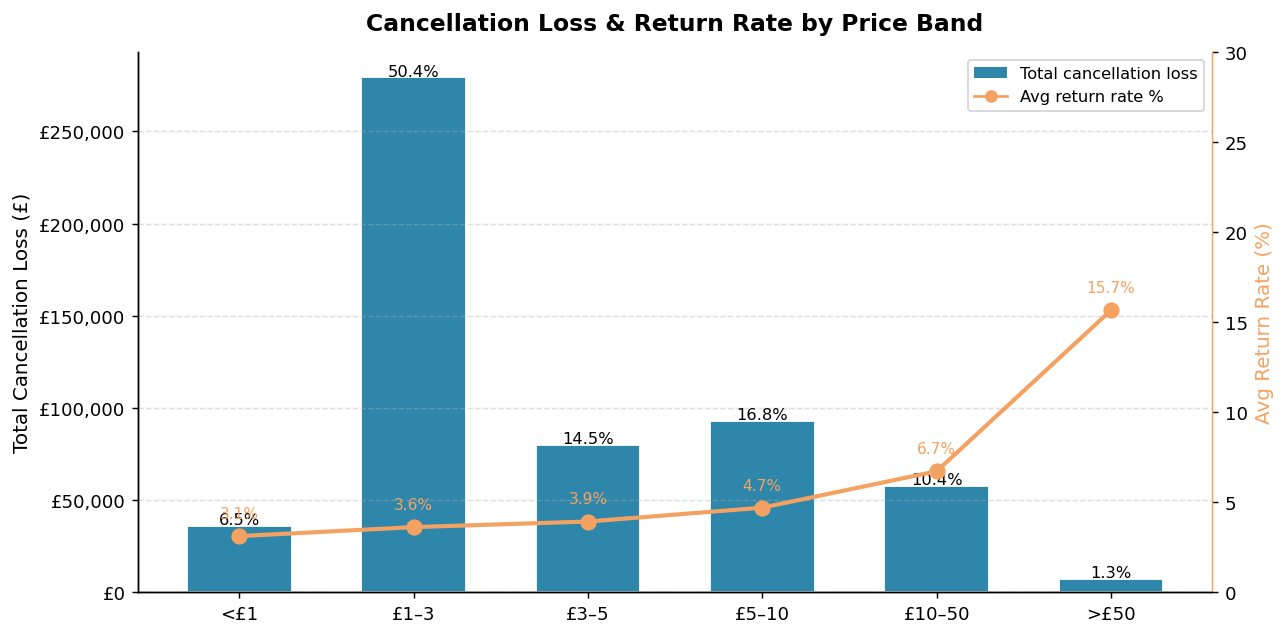


Business Insight — Price Bands:
  £1–3 band carries the most absolute loss (largest SKU count).
  Return RATE climbs with price — items above £50 return at ~16% vs ~3% for cheap items.
  Higher-priced items are riskier per-unit even if fewer in volume.


In [25]:
prod_price = df_product[~df_product['Cancelled']].groupby('StockCode')['Price'].median().rename('median_price')
prod = prod.merge(prod_price.reset_index(), on='StockCode', how='left')

bins   = [0, 1, 3, 5, 10, 50, 9999]
labels = ['<£1', '£1–3', '£3–5', '£5–10', '£10–50', '>£50']
prod['price_band'] = pd.cut(prod['median_price'], bins=bins, labels=labels)

price_grp = prod.groupby('price_band', observed=True).agg(
    num_skus        = ('cancel_loss',     'count'),
    total_loss      = ('cancel_loss',     'sum'),
    avg_return_rate = ('return_rate_pct', 'mean')
).round(2)
price_grp['loss_share_pct'] = (price_grp['total_loss'] / price_grp['total_loss'].sum() * 100).round(1)

fig, ax1 = plt.subplots(figsize=(10, 5))
bars = ax1.bar(price_grp.index, price_grp['total_loss'], color=C_BLUE, edgecolor='white', width=0.6)
for bar, share in zip(bars, price_grp['loss_share_pct']):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1000,
             f'{share:.1f}%', ha='center', fontsize=9)
ax1.set_ylabel('Total Cancellation Loss (£)')
ax1.set_title('Cancellation Loss & Return Rate by Price Band', pad=12)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'£{v:,.0f}'))
ax1.grid(axis='y', linestyle='--', alpha=0.4)

ax2 = ax1.twinx()
ax2.plot(price_grp.index, price_grp['avg_return_rate'],
         color=C_ORANGE, marker='o', linewidth=2.3, markersize=8)
for x, y in zip(price_grp.index, price_grp['avg_return_rate']):
    ax2.annotate(f'{y:.1f}%', (x, y), textcoords='offset points',
                 xytext=(0, 10), ha='center', fontsize=8.5, color=C_ORANGE)
ax2.set_ylabel('Avg Return Rate (%)', color=C_ORANGE)
ax2.set_ylim(0, 30)
ax2.spines['right'].set_visible(True)
ax2.spines['right'].set_color(C_ORANGE)
legend_el = [
    mpatches.Patch(facecolor=C_BLUE, label='Total cancellation loss'),
    plt.Line2D([0],[0], color=C_ORANGE, marker='o', label='Avg return rate %')
]
ax1.legend(handles=legend_el, loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('prod_chart2_pricebands.png', bbox_inches='tight')
plt.show()

print()
print('Business Insight — Price Bands:')
print('  £1–3 band carries the most absolute loss (largest SKU count).')
print('  Return RATE climbs with price — items above £50 return at ~16% vs ~3% for cheap items.')
print('  Higher-priced items are riskier per-unit even if fewer in volume.')

## 3. MEDIUM CERAMIC TOP STORAGE JAR — Quality Issue or Bulk B2B Event?

In [26]:
JAR_SKU = '23166'

jar_cancelled = cancelled_product[cancelled_product['StockCode'] == JAR_SKU].copy()
jar_normal    = df_product[(df_product['StockCode'] == JAR_SKU) & (~df_product['Cancelled'])].copy()

print('=== MEDIUM CERAMIC TOP STORAGE JAR (23166) ===')
print()
print('Cancellation events:')
print(jar_cancelled[['Invoice', cid_col, 'Country', 'Quantity', 'Loss', 'Month']].to_string())
print()

jan_event = jar_cancelled[jar_cancelled['Month'] == '2011-01']
jan_cust  = jan_event[cid_col].values[0]
jan_units = jan_event['Quantity'].abs().values[0]
jan_loss  = jan_event['Loss'].values[0]

print(f'Jan 2011 event: Customer {int(jan_cust)} cancelled {jan_units:,} units = £{jan_loss:,.2f}')
print(f'First normal sale of this SKU: {jar_normal["Month"].min()}')
print()
print('Normal monthly sales after the event:')
print(jar_normal.groupby('Month').agg(
    units=("Quantity", 'sum'), customers=(cid_col, 'nunique')).to_string())

=== MEDIUM CERAMIC TOP STORAGE JAR (23166) ===

Cancellation events:
        Invoice  Customer ID         Country  Quantity      Loss    Month
587085  C541433      12346.0  United Kingdom    -74215  77183.60  2011-01
729086  C554527      15251.0  United Kingdom        -9      9.36  2011-05
759825  C557508      16684.0  United Kingdom      -240    249.60  2011-06
795545  C560540      12415.0       Australia        -1      1.25  2011-07
815818  C562375      14911.0            EIRE       -12     15.00  2011-08
822991  C562952      12749.0  United Kingdom        -1      1.25  2011-08
875309  C567535      15253.0  United Kingdom        -1      1.25  2011-09
878173  C567677      12409.0     Switzerland        -2      2.08  2011-09
919463  C570867      12607.0             USA       -12     15.00  2011-10
946962  C572991      17672.0  United Kingdom        -1      1.25  2011-10

Jan 2011 event: Customer 12346 cancelled 74,215 units = £77,183.60
First normal sale of this SKU: 2011-01

Normal mo

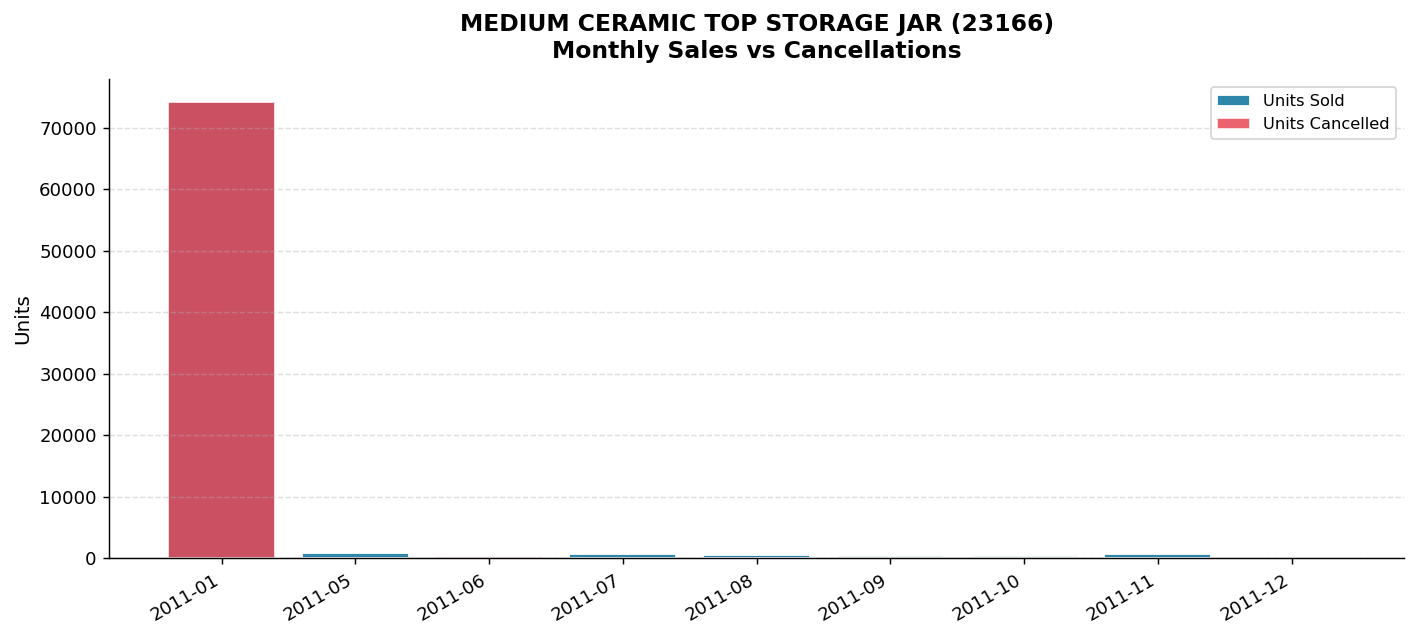


Finding: NOT a quality issue. Single bulk B2B event.
  Customer 12346 cancelled 74,215 units in Jan 2011.
  SKU did not exist before Jan 2011. Return rate <5% in all subsequent months.


In [27]:
jar_monthly_c = jar_cancelled.groupby('Month')['Quantity'].apply(lambda x: x.abs().sum()).rename('cancelled')
jar_monthly_s = jar_normal.groupby('Month')['Quantity'].sum().rename('sold')
jar_monthly   = pd.concat([jar_monthly_s, jar_monthly_c], axis=1).fillna(0)

months = [str(m) for m in jar_monthly.index]
x      = range(len(months))

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x, jar_monthly['sold'],      color=C_BLUE, label='Units Sold',      edgecolor='white')
ax.bar(x, jar_monthly['cancelled'], color=C_RED,  label='Units Cancelled', edgecolor='white', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(months, rotation=30, ha='right')
ax.set_ylabel('Units')
ax.set_title('MEDIUM CERAMIC TOP STORAGE JAR (23166)\nMonthly Sales vs Cancellations', pad=12)
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('prod_chart3_jar.png', bbox_inches='tight')
plt.show()

print()
print('Finding: NOT a quality issue. Single bulk B2B event.')
print(f'  Customer {int(jan_cust)} cancelled {jan_units:,} units in Jan 2011.')
print('  SKU did not exist before Jan 2011. Return rate <5% in all subsequent months.')

### September 2010 Spike — What Caused ~94k Cancelled Units?

In [28]:
sep = cancelled_product[cancelled_product['Month'] == '2010-09'].copy()

print(f'Sep 2010 cancellations: {len(sep):,} rows')
print(f'Unique customers      : {sep[cid_col].nunique()}')
print(f'Unique invoices       : {sep["Invoice"].nunique()}')
print()

top_inv = (sep.groupby('Invoice')
              .agg(units    = ('Quantity', lambda x: x.abs().sum()),
                   loss     = ('Loss',     'sum'),
                   customer = (cid_col,   'first'),
                   country  = ('Country',  'first'))
              .sort_values('units', ascending=False)
              .head(3))
print('Top invoices by units:')
print(top_inv.to_string())
print()

dom_inv  = top_inv.index[0]
dom_skus = (sep[sep['Invoice'] == dom_inv]
            .groupby('Description')
            .agg(units=('Quantity', lambda x: x.abs().sum()), loss=('Loss', 'sum'))
            .sort_values('units', ascending=False)
            .head(8)
            .reset_index())
print(f'Contents of dominant invoice {dom_inv}:')
print(dom_skus.to_string())

Sep 2010 cancellations: 754 rows
Unique customers      : 253
Unique invoices       : 319

Top invoices by units:
         units      loss  customer country
Invoice                                   
C524235  87167  11880.84   14277.0  France
C524154   2020   3787.88   14911.0    EIRE
C524158    672   1251.20   14911.0    EIRE

Contents of dominant invoice C524235:
                          Description  units     loss
0        SET/6 FRUIT SALAD PAPER CUPS   7128   570.24
1     SET/6 FRUIT SALAD  PAPER PLATES   7008   911.04
2             POP ART PEN CASE & PENS   5184   414.72
3       MULTICOLOUR SPRING FLOWER MUG   4992   499.20
4  BLACK SILVER FLOWER T-LIGHT HOLDER   4752   332.64
5             TEATIME PEN CASE & PENS   4608   368.64
6        WHITE BIRD GARDEN DESIGN MUG   4320   561.60
7      S/4 BLUE ROUND DECOUPAGE BOXES   3936  1653.12


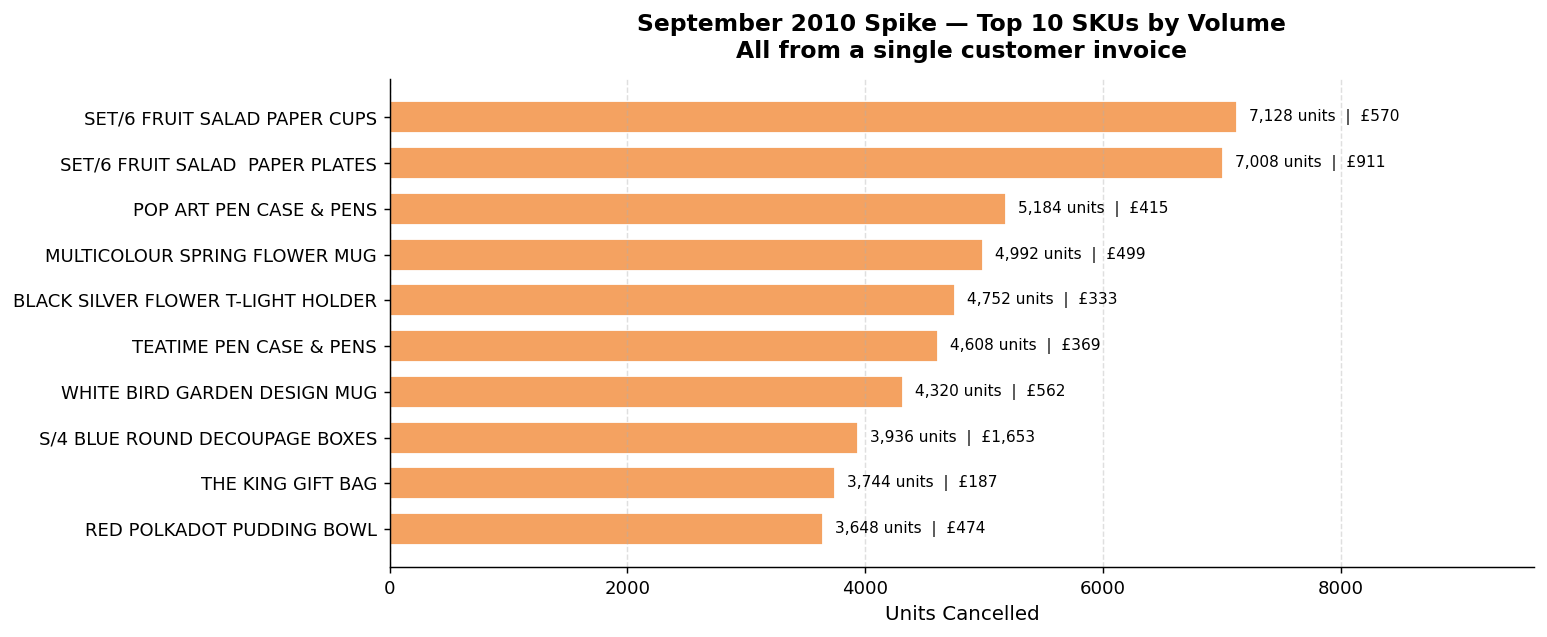


Finding — September 2010 Spike:
  87,167 units (92%) from ONE invoice.
  Customer 14277 (France) — bulk wholesale cancellation across ~20 SKUs.
  Same customer (14277) = 45.5% of France total cancellation loss.
  Account management problem, not a product issue.


In [29]:
top_sep = (sep.groupby(['StockCode','Description'])
              .agg(units=('Quantity', lambda x: x.abs().sum()), loss=('Loss', 'sum'))
              .sort_values('units', ascending=False)
              .head(10)
              .reset_index())

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(top_sep['Description'][::-1], top_sep['units'][::-1],
        color=C_ORANGE, edgecolor='white', height=0.7)
for i, (units, loss) in enumerate(zip(top_sep['units'][::-1], top_sep['loss'][::-1])):
    ax.text(units + 100, i, f'{units:,} units  |  £{loss:,.0f}', va='center', fontsize=8.5)
ax.set_xlabel('Units Cancelled')
ax.set_title('September 2010 Spike — Top 10 SKUs by Volume\nAll from a single customer invoice', pad=12)
ax.set_xlim(0, top_sep['units'].max() * 1.35)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('prod_chart4_sep2010.png', bbox_inches='tight')
plt.show()

dom_cust  = top_inv['customer'].iloc[0]
dom_units = top_inv['units'].iloc[0]
dom_ctry  = top_inv['country'].iloc[0]
print()
print('Finding — September 2010 Spike:')
print(f'  {dom_units:,} units ({dom_units/sep["Quantity"].abs().sum()*100:.0f}%) from ONE invoice.')
print(f'  Customer {int(dom_cust)} ({dom_ctry}) — bulk wholesale cancellation across ~20 SKUs.')
print('  Same customer (14277) = 45.5% of France total cancellation loss.')
print('  Account management problem, not a product issue.')

## 4. Key Account Product Breakdown — EIRE, Norway, France, Spain

In [30]:
KEY_ACCOUNTS = {
    'EIRE'   : [14911, 14156],
    'Norway' : [15760],
    'France' : [14277, 12536, 12589],
    'Spain'  : [12454, 12539]
}

results = {}

for country, customers in KEY_ACCOUNTS.items():
    sub = cancelled_product[
        (cancelled_product['Country'] == country) &
        (cancelled_product[cid_col].isin(customers))
    ].copy()

    breakdown = (sub.groupby([cid_col, 'StockCode', 'Description'])
                    .agg(times_cancelled = ('Invoice',  'nunique'),
                         total_units     = ('Quantity', lambda x: x.abs().sum()),
                         total_loss      = ('Loss',     'sum'))
                    .sort_values([cid_col, 'total_loss'], ascending=[True, False])
                    .reset_index())

    results[country] = breakdown
    print(f'\n=== {country} ===')
    print(breakdown.head(15).to_string())


=== EIRE ===
    Customer ID StockCode                          Description  times_cancelled  total_units  total_loss
0       14156.0     22838        3 TIER CAKE TIN RED AND CREAM                1           96     1224.00
1       14156.0     22199             FRYING PAN RED POLKADOT                 1          264      990.00
2       14156.0     20715            LITTLE FLOWER SHOPPER BAG                1          400      424.00
3       14156.0     22630                 DOLLY GIRL LUNCH BOX                1          192      316.80
4       14156.0     22363                 GLASS JAR MARMALADE                 1          120      306.00
5       14156.0     22699     ROSES REGENCY TEACUP AND SAUCER                 1          120      306.00
6       14156.0     22935     BAKING MOULD ROSE MILK CHOCOLATE                1           72      198.00
7       14156.0     22936    BAKING MOULD ROSE WHITE CHOCOLATE                1           72      198.00
8       14156.0     20725              LU

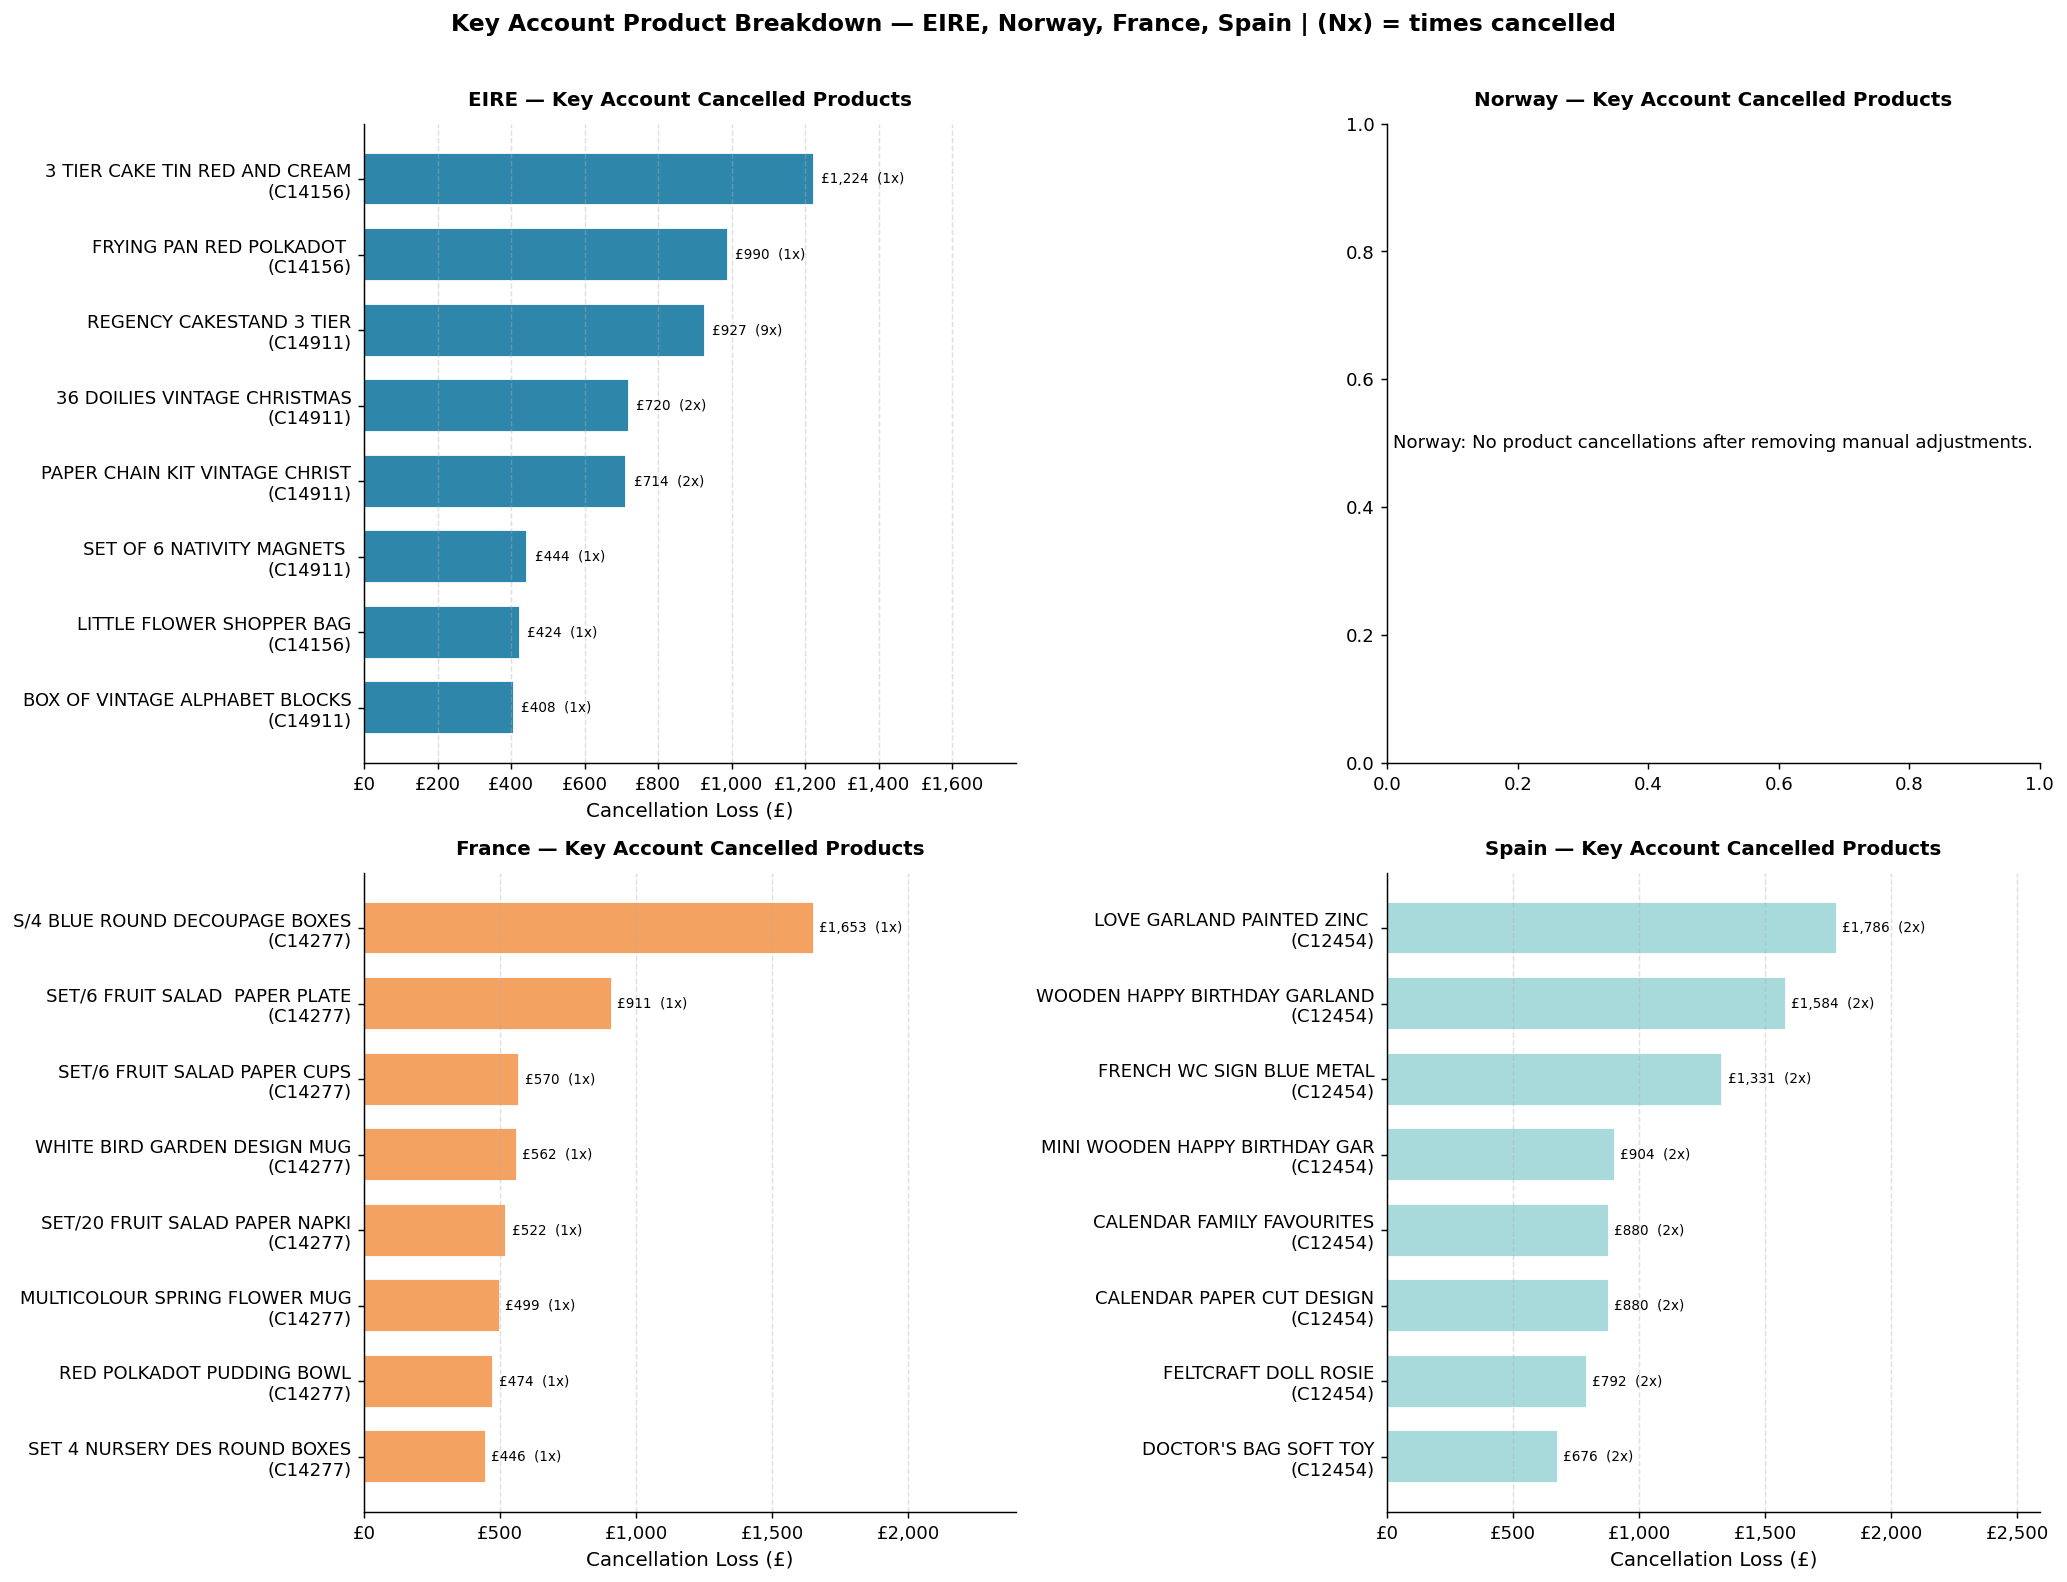


EIRE   : Mixed SKUs. Exception: Customer 14156 cancels REGENCY CAKESTAND repeatedly.
Norway : Negligible real product cancellations after removing Manual codes.
France : One-off bulk event (14277, Sep 2010). No recurring product pattern.
Spain  : RECURRING PATTERN. Customer 12454 cancels same home décor SKUs
         (LOVE GARLAND, WOODEN HAPPY BIRTHDAY GARLAND, FRENCH WC SIGN)
         across multiple invoices. Strongest product-market fit signal in dataset.


In [31]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

country_colors = {'EIRE': C_BLUE, 'Norway': C_RED, 'France': C_ORANGE, 'Spain': C_TEAL}

for ax, (country, breakdown) in zip(axes, results.items()):
    top = breakdown.nlargest(8, 'total_loss')

    if top.empty:
        ax.text(0.5, 0.5,
                f'{country}: No product cancellations after removing manual adjustments.',
                ha='center', va='center', transform=ax.transAxes, fontsize=10)
        ax.set_title(f'{country} — Key Account Cancelled Products', fontsize=11, pad=10)
        continue

    labels = [f"{row['Description'][:30]}\n(C{int(row[cid_col])})" for _, row in top.iterrows()]
    bars = ax.barh(labels[::-1], top['total_loss'][::-1],
                   color=country_colors[country], edgecolor='white', height=0.7)
    for bar, times in zip(bars, top['times_cancelled'][::-1]):
        ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
                f'£{bar.get_width():,.0f}  ({times}x)', va='center', fontsize=7.5)
    ax.set_title(f'{country} — Key Account Cancelled Products', fontsize=11, pad=10)
    ax.set_xlabel('Cancellation Loss (£)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'£{v:,.0f}'))
    ax.set_xlim(0, top['total_loss'].max() * 1.45)
    ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.suptitle('Key Account Product Breakdown — EIRE, Norway, France, Spain | (Nx) = times cancelled',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('prod_chart6_key_accounts.png', bbox_inches='tight')
plt.show()

print()
print('EIRE   : Mixed SKUs. Exception: Customer 14156 cancels REGENCY CAKESTAND repeatedly.')
print('Norway : Negligible real product cancellations after removing Manual codes.')
print('France : One-off bulk event (14277, Sep 2010). No recurring product pattern.')
print('Spain  : RECURRING PATTERN. Customer 12454 cancels same home décor SKUs')
print('         (LOVE GARLAND, WOODEN HAPPY BIRTHDAY GARLAND, FRENCH WC SIGN)')
print('         across multiple invoices. Strongest product-market fit signal in dataset.')

## Business Insights:

**Q1 — Pareto:** 464 SKUs (15%) account for 80% of cancellation loss. Less extreme than the geographic Pareto — product interventions must be paired with account-level actions.

**Q2 — Price Bands:** Return *rate* rises with price — items above £50 return at ~16% vs ~3% for cheap items. Absolute loss is concentrated in the £1–3 range due to SKU volume.

**Q3a — Ceramic Jar:** Bulk B2B event. Customer 12346 canceled 74,215 units in Jan 2011—no quality signal.

**Q3b — Sep 2010 Spike:** Bulk B2B event. Customer 14277 (France) canceled one large wholesale order across ~20 SKUs—no product pattern.

**Key Account Patterns:** EIRE and France are account problems, not product problems. Norway losses are mostly manual credits (StockCode M). Spain 12454 is the only account showing a genuine recurring product-cancellation pattern — worth further investigation.

# ─────────────────────────────────────────────────────────────────────────────
# PART 2: ADVANCED ANALYTICS
# ─────────────────────────────────────────────────────────────────────────────

---
# Part 2: Advanced Analytics

**Two objectives:**

4. **Customer Segmentation** — K-Means clustering of all UK and German customers 
with at least one cancellation, using five RFMR dimensions to identify natural 
behavioral segments beyond the Pareto 80% threshold.

5. **Forecasting & Cancellation Prediction** — Time series forecasting of UK gross 
sales (Prophet vs ARIMA) combined with ML-based cancellation prediction at the 
customer level (XGBoost vs Random Forest), to project the expected cancellation 
rate and support resource allocation planning ahead of peak periods.

---

# Section 4: Customer Segmentation — K-Means Clustering

**Objective:** Cluster all customers with at least one cancellation in the UK 
(2,292 customers) and Germany (66 customers) separately, using five RFMR dimensions 
as input features. The goal is to identify natural behavioral segments that go beyond 
the Pareto concentration analysis and provide a foundation for targeted intervention 
strategies.

**Markets:** United Kingdom and Germany — clustered independently.  
**Input features:** R (Cancel Recency), R_Purchase (Purchase Recency), F (Total Order 
Frequency), M (Gross Purchases £), Re (Cancellation Loss £).  
**Method:** K-Means with elbow method and silhouette analysis to determine optimal K. 
Customer 12346 isolated as a standalone outlier before clustering due to a single bulk 
B2B event (74,215 units, £77,183, January 2011).

---

# Section 5: Forecasting & Cancellation Prediction — United Kingdom

**Objective:** Forecast UK gross sales and cancellation losses to support resource allocation planning — identifying when demand peaks, when cancellation risk is highest, and which customer clusters drive that risk in each period.

**Market:** United Kingdom only — 85.2% of total cancellation losses.  
**Forecast horizon:** 6 months (January–June 2012).  
**Methods:**
- Gross sales forecast: Prophet — MAE and RMSE evaluated on test set  
  (Aug–Nov 2011). ARIMA run for comparison only — produced a flat forecast,  
  not suitable for planning.
- Cancellation forecast by cluster: Prophet for Normal Bypass;  
  Historical mean ± 95% CI for Question Mark, Stars, and Anonymous.
- Projected cancellation rate: Total expected cancellations / Gross sales  
  forecast per month.
  
---

# Section 6: ML Cancellation Prediction — United Kingdom

**Objective:** Predict which individual UK customers are most likely to cancel 
in a future period and estimate their expected cancellation loss, using 
behavioral features from the RFMR framework as model inputs.

**Market:** United Kingdom.  
**Method:** XGBoost vs Random Forest — model comparison by MAE, RMSE,  
and feature importance.  
**Target variable:** Total cancellation loss in £ per customer (Re_CancelLoss).  
**Input features:** R_Recency, R_PurchaseRecency, F_TotalOrders,  
M_GrossPurchases, Re_CancelLoss (historical), Cluster label.

---

# Section 4: Customer Segmentation — K-Means Clustering
## 1. Data Preparation — Build RFMR for All Canceling Customers

In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# 4.1 Build RFMR for ALL customers with at least one cancellation
# UK: 2,292 customers | Germany: 66 customers
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

DATASET_END = df['InvoiceDate'].max()

# ── Step 1: All customers with at least one cancellation per country ──────────
uk_all_cancellers = (df_top6_cancelled[df_top6_cancelled['Country'] == 'United Kingdom']
                     [cid_col].dropna().unique())

germany_all_cancellers = (df_top6_cancelled[df_top6_cancelled['Country'] == 'Germany']
                          [cid_col].dropna().unique())

print(f'UK customers with at least one cancellation     : {len(uk_all_cancellers):,}')
print(f'Germany customers with at least one cancellation: {len(germany_all_cancellers):,}')
print()

# ── Step 2: R — days since last cancellation ──────────────────────────────────
recency = (df_top6_cancelled
           .groupby(cid_col)['InvoiceDate']
           .max()
           .reset_index()
           .rename(columns={'InvoiceDate': 'LastCancel'}))
recency['R_Recency'] = (DATASET_END - recency['LastCancel']).dt.days


# ── Step 3: F — total order frequency from full dataset ──────────────────────
frequency = (df[df['Is_Return'] == False]
             .groupby(cid_col)['Invoice']
             .nunique()
             .reset_index()
             .rename(columns={'Invoice': 'F_TotalOrders'}))

# ── Step 3b: R_Purchase — days since last purchase ────────────────────────────
purchase_recency = (df[df['Is_Return'] == False]
                    .groupby(cid_col)['InvoiceDate']
                    .max()
                    .reset_index()
                    .rename(columns={'InvoiceDate': 'LastPurchase'}))
purchase_recency['R_PurchaseRecency'] = (DATASET_END - purchase_recency['LastPurchase']).dt.days

# ── Step 4: M — total gross purchases from full dataset ──────────────────────
monetary = (df[df['Is_Return'] == False]
            .assign(GrossValue=lambda x: x['Quantity'] * x['Price'])
            .groupby(cid_col)['GrossValue']
            .sum()
            .reset_index()
            .rename(columns={'GrossValue': 'M_GrossPurchases'}))

# ── Step 5: Re — total cancellation loss ─────────────────────────────────────
cancel_loss = (df_top6_cancelled
               .groupby(cid_col)['Loss']
               .sum()
               .reset_index()
               .rename(columns={'Loss': 'Re_CancelLoss'}))

# ── Step 6: Merge all dimensions ──────────────────────────────────────────────
rfmr_all = (recency[[cid_col, 'R_Recency']]
            .merge(purchase_recency[[cid_col, 'R_PurchaseRecency']], on=cid_col, how='left')
            .merge(frequency,   on=cid_col, how='left')
            .merge(monetary,    on=cid_col, how='left')
            .merge(cancel_loss, on=cid_col, how='left'))

rfmr_all['R_PurchaseRecency'] = rfmr_all['R_PurchaseRecency'].fillna(rfmr_all['R_Recency'])

# ── Step 7: Add country ───────────────────────────────────────────────────────
country_map = (df_top6_cancelled
               .groupby(cid_col)['Country']
               .first()
               .reset_index())
rfmr_all = rfmr_all.merge(country_map, on=cid_col, how='left')

# ── Step 8: Split into UK and Germany ────────────────────────────────────────
rfmr_uk_all      = rfmr_all[rfmr_all[cid_col].isin(uk_all_cancellers)].copy()
rfmr_germany_all = rfmr_all[rfmr_all[cid_col].isin(germany_all_cancellers)].copy()

# ── Fill missing F and M for customers with no purchase history ───────────────
rfmr_uk_all['F_TotalOrders']         = rfmr_uk_all['F_TotalOrders'].fillna(0)
rfmr_uk_all['M_GrossPurchases']      = rfmr_uk_all['M_GrossPurchases'].fillna(0)
rfmr_germany_all['F_TotalOrders']    = rfmr_germany_all['F_TotalOrders'].fillna(0)
rfmr_germany_all['M_GrossPurchases'] = rfmr_germany_all['M_GrossPurchases'].fillna(0)

print('NaN check after fill:')
print('UK:')
print(rfmr_uk_all[['R_Recency','R_PurchaseRecency','F_TotalOrders',
                    'M_GrossPurchases','Re_CancelLoss']].isna().sum())
print()
print('Germany:')
print(rfmr_germany_all[['R_Recency','R_PurchaseRecency','F_TotalOrders',
                         'M_GrossPurchases','Re_CancelLoss']].isna().sum())

# ── Summary ───────────────────────────────────────────────────────────────────
print('UK RFMR stats:')
print(rfmr_uk_all[['R_Recency', 'R_PurchaseRecency', 'F_TotalOrders', 'M_GrossPurchases', 'Re_CancelLoss']]
      .describe().round(2).to_string())
print()
print('Germany RFMR stats:')
print(rfmr_germany_all[['R_Recency', 'R_PurchaseRecency', 'F_TotalOrders', 'M_GrossPurchases', 'Re_CancelLoss']]
      .describe().round(2).to_string())

UK customers with at least one cancellation     : 2,292
Germany customers with at least one cancellation: 66

NaN check after fill:
UK:
R_Recency            0
R_PurchaseRecency    0
F_TotalOrders        0
M_GrossPurchases     0
Re_CancelLoss        0
dtype: int64

Germany:
R_Recency            0
R_PurchaseRecency    0
F_TotalOrders        0
M_GrossPurchases     0
Re_CancelLoss        0
dtype: int64
UK RFMR stats:
       R_Recency  R_PurchaseRecency  F_TotalOrders  M_GrossPurchases  Re_CancelLoss
count    2292.00            2292.00        2292.00           2292.00        2292.00
mean      289.44             154.49          10.42           5024.94         314.53
std       219.45             189.84          16.79          17429.57        2313.82
min         0.00               0.00           0.00              0.00           0.42
25%        74.00              16.00           3.00            831.35          15.95
50%       265.00              57.50           6.00           1977.90          3

## 2. Feature Scaling

In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# 4.2 Feature Scaling — RobustScaler
# Using median and IQR instead of mean/std — handles extreme outliers in
# UK M and Re dimensions (Customer 12346 would otherwise distort the space)
# 5 features: R_Recency, R_PurchaseRecency, F_TotalOrders,
#             M_GrossPurchases, Re_CancelLoss
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.preprocessing import RobustScaler

FEATURES = ['R_Recency', 'R_PurchaseRecency', 'F_TotalOrders',
            'M_GrossPurchases', 'Re_CancelLoss']

# ── Remove UK outlier before scaling ─────────────────────────────────────────
OUTLIER_ID = 12346.0

outlier_row  = rfmr_uk_all[rfmr_uk_all[cid_col] == OUTLIER_ID].copy()
rfmr_uk_core = rfmr_uk_all[rfmr_uk_all[cid_col] != OUTLIER_ID].copy().reset_index(drop=True)

print(f'Customer {int(OUTLIER_ID)} removed before scaling.')
print(f'Outlier cancel loss       : £{outlier_row["Re_CancelLoss"].values[0]:,.2f}')
print(f'Outlier gross purchases   : £{outlier_row["M_GrossPurchases"].values[0]:,.2f}')
print(f'UK customers for scaling  : {len(rfmr_uk_core):,}')
print()

# ── Scale UK ──────────────────────────────────────────────────────────────────
scaler_uk = RobustScaler()
X_uk_core = scaler_uk.fit_transform(rfmr_uk_core[FEATURES])

# ── Scale Germany ─────────────────────────────────────────────────────────────
scaler_de = RobustScaler()
X_de      = scaler_de.fit_transform(rfmr_germany_all[FEATURES])

print('Scaling complete.')
print()
print(f'UK scaled matrix shape      : {X_uk_core.shape}')
print(f'Germany scaled matrix shape : {X_de.shape}')
print()
print('UK scaled stats:')
print(pd.DataFrame(X_uk_core, columns=FEATURES).describe().round(3).to_string())
print()
print('Germany scaled stats:')
print(pd.DataFrame(X_de, columns=FEATURES).describe().round(3).to_string())

Customer 12346 removed before scaling.
Outlier cancel loss       : £77,620.14
Outlier gross purchases   : £77,556.46
UK customers for scaling  : 2,291

Scaling complete.

UK scaled matrix shape      : (2291, 5)
Germany scaled matrix shape : (66, 5)

UK scaled stats:
       R_Recency  R_PurchaseRecency  F_TotalOrders  M_GrossPurchases  Re_CancelLoss
count   2291.000           2291.000       2291.000          2291.000       2291.000
mean       0.065              0.419          0.491             0.840          2.380
std        0.584              0.817          1.866             4.833         16.368
min       -0.705             -0.245         -0.667            -0.550         -0.390
25%       -0.508             -0.176         -0.333            -0.319         -0.236
50%        0.000              0.000          0.000             0.000          0.000
75%        0.492              0.824          0.667             0.681          0.764
max        1.245              2.908         35.889           

## 3 Optimal K — Elbow Method and Silhouette Analysis

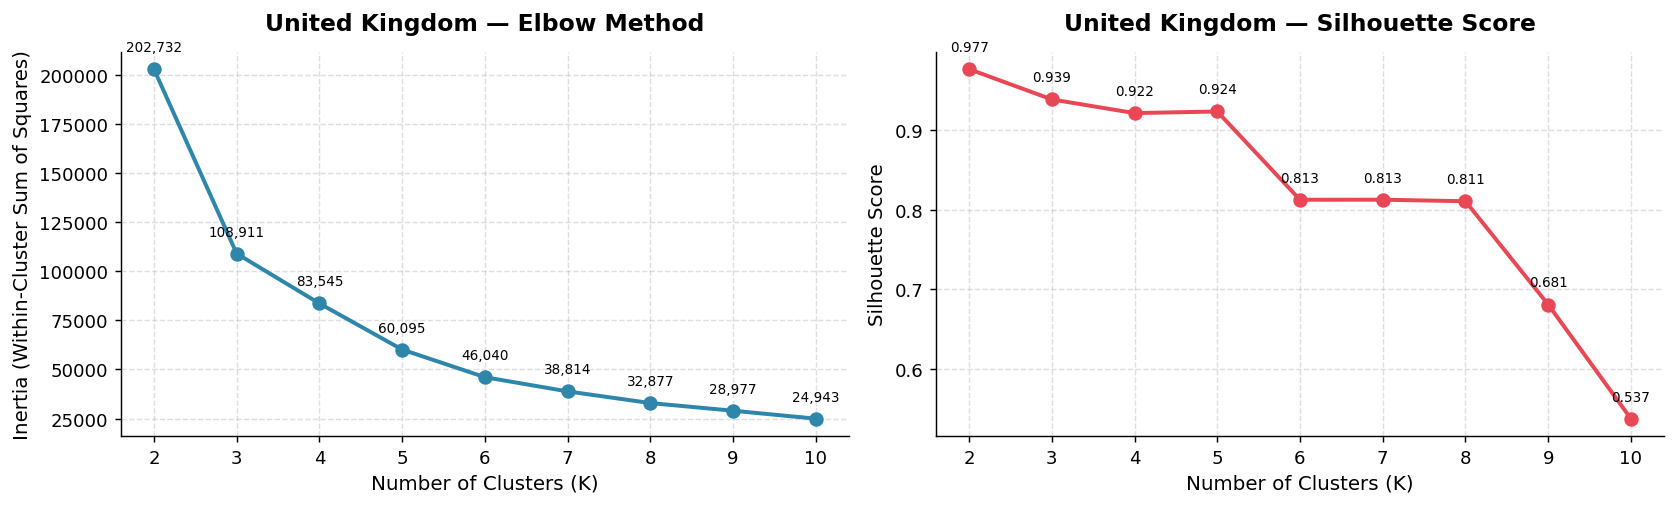

United Kingdom
──────────────────────────────────────────────────
  K=2 | Inertia=202,731.9 | Silhouette=0.977 ← best silhouette
  K=3 | Inertia=108,911.3 | Silhouette=0.939
  K=4 | Inertia=83,545.0 | Silhouette=0.922
  K=5 | Inertia=60,095.1 | Silhouette=0.924
  K=6 | Inertia=46,040.3 | Silhouette=0.813
  K=7 | Inertia=38,813.6 | Silhouette=0.813
  K=8 | Inertia=32,876.9 | Silhouette=0.811
  K=9 | Inertia=28,977.5 | Silhouette=0.681
  K=10 | Inertia=24,943.3 | Silhouette=0.537



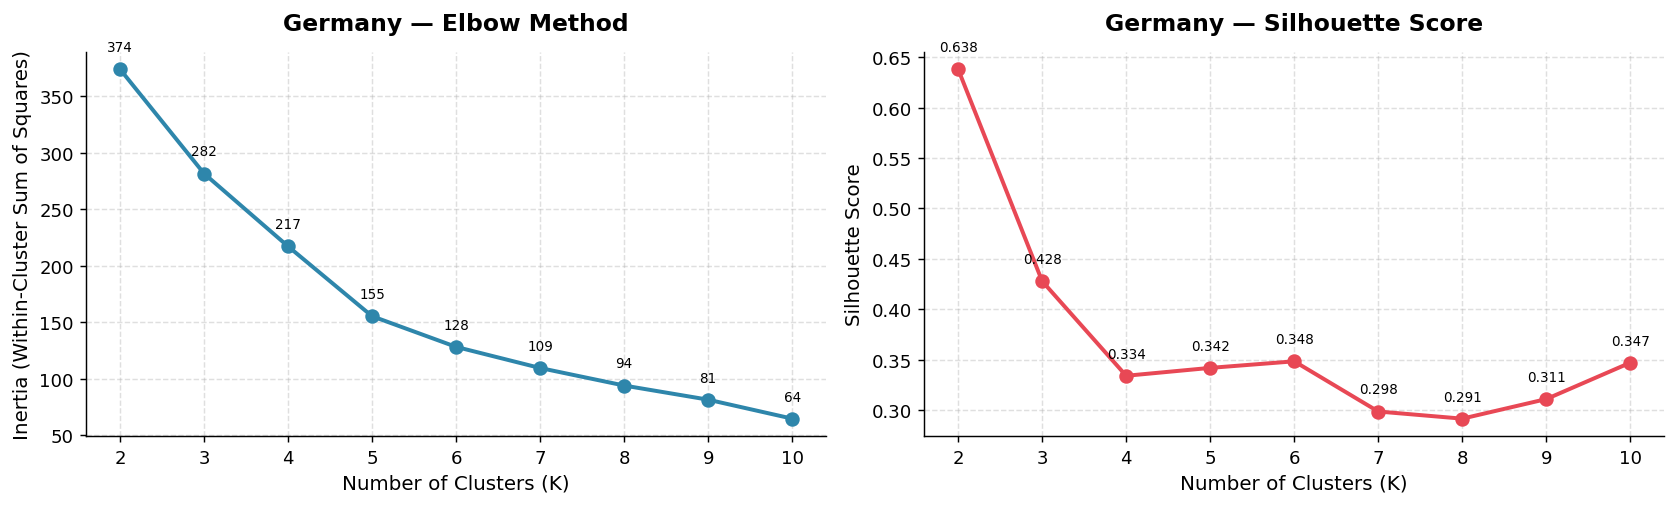

Germany
──────────────────────────────────────────────────
  K=2 | Inertia=374.1 | Silhouette=0.638 ← best silhouette
  K=3 | Inertia=281.7 | Silhouette=0.428
  K=4 | Inertia=217.1 | Silhouette=0.334
  K=5 | Inertia=155.2 | Silhouette=0.342
  K=6 | Inertia=128.1 | Silhouette=0.348
  K=7 | Inertia=109.4 | Silhouette=0.298
  K=8 | Inertia=93.8 | Silhouette=0.291
  K=9 | Inertia=81.3 | Silhouette=0.311
  K=10 | Inertia=64.5 | Silhouette=0.347

Recommended K — UK      : 2
Recommended K — Germany : 2


In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# 6.3 Optimal K — Elbow Method and Silhouette Analysis
# Run for UK and Germany separately
# ─────────────────────────────────────────────────────────────────────────────

def find_optimal_k(X, label, k_range=range(2, 11)):
    inertias    = []
    silhouettes = []

    for k in k_range:
        km     = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(X, labels))

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    ax1.plot(list(k_range), inertias, marker='o', color=C_BLUE,
             linewidth=2.2, markersize=7)
    ax1.set_xlabel('Number of Clusters (K)')
    ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)')
    ax1.set_title(f'{label} — Elbow Method', pad=12)
    ax1.grid(linestyle='--', alpha=0.4)
    for k, v in zip(k_range, inertias):
        ax1.annotate(f'{v:,.0f}', (k, v), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=7.5)

    ax2.plot(list(k_range), silhouettes, marker='o', color=C_RED,
             linewidth=2.2, markersize=7)
    ax2.set_xlabel('Number of Clusters (K)')
    ax2.set_ylabel('Silhouette Score')
    ax2.set_title(f'{label} — Silhouette Score', pad=12)
    ax2.grid(linestyle='--', alpha=0.4)
    for k, v in zip(k_range, silhouettes):
        ax2.annotate(f'{v:.3f}', (k, v), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=7.5)

    plt.tight_layout()
    plt.savefig(f'cluster_{label.lower().replace(" ", "_")}_optimal_k.png',
                bbox_inches='tight')
    plt.show()

    # ── Summary table ─────────────────────────────────────────────────────────
    best_k = list(k_range)[silhouettes.index(max(silhouettes))]
    print(f'{label}')
    print(f'{"─" * 50}')
    for k, inertia, sil in zip(k_range, inertias, silhouettes):
        flag = ' ← best silhouette' if k == best_k else ''
        print(f'  K={k} | Inertia={inertia:,.1f} | Silhouette={sil:.3f}{flag}')
    print()
    return best_k

best_k_uk = find_optimal_k(X_uk_core, 'United Kingdom')
best_k_de = find_optimal_k(X_de, 'Germany')

print(f'Recommended K — UK      : {best_k_uk}')
print(f'Recommended K — Germany : {best_k_de}')


## 4. Applying K-means to the UK & Germany. 

UK clustering complete — K=3

Cluster sizes:
Cluster
0    2259
1       8
2      24

UK Cluster Profiles:
         Num_Customers  Avg_CancelRecency  Avg_PurchaseRecency  Avg_Frequency  Avg_Monetary  Avg_CancelLoss  Total_CancelLoss  Loss_Share_Pct
Cluster                                                                                                                                      
0                 2259             290.69               153.58           9.77       3978.53          131.52         297105.63           46.19
1                    8             257.00               255.25          36.88      55149.66        24767.46         198139.69           30.80
2                   24             182.17               199.79          62.75      83787.65         6168.18         148036.34           23.01



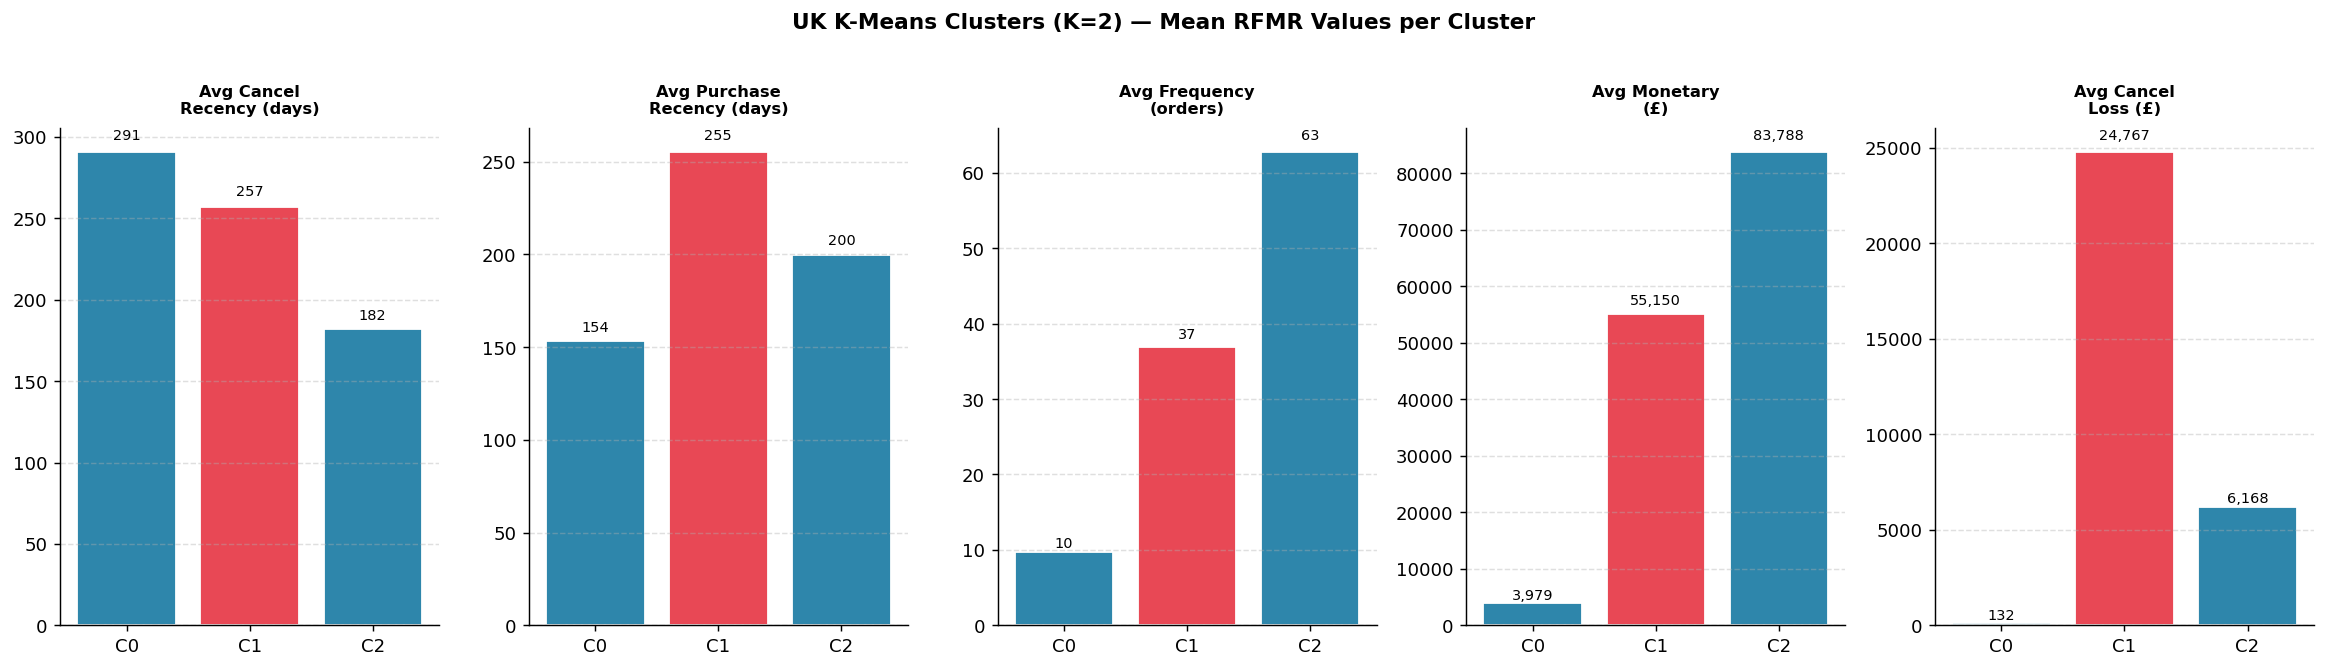

In [35]:
# ─────────────────────────────────────────────────────────────────────────────
# 6.4 K-Means Clustering — United Kingdom (K=2)
# ─────────────────────────────────────────────────────────────────────────────

K_UK = 3

km_uk     = KMeans(n_clusters=K_UK, random_state=42, n_init=10)
uk_labels = km_uk.fit_predict(X_uk_core)

rfmr_uk_core['Cluster'] = uk_labels

print(f'UK clustering complete — K={K_UK}')
print()
print('Cluster sizes:')
print(rfmr_uk_core['Cluster'].value_counts().sort_index().to_string())
print()

# ── Cluster profiles ──────────────────────────────────────────────────────────
uk_profile = (rfmr_uk_core
              .groupby('Cluster')
              .agg(
                  Num_Customers       = (cid_col,              'count'),
                  Avg_CancelRecency   = ('R_Recency',           'mean'),
                  Avg_PurchaseRecency = ('R_PurchaseRecency',   'mean'),
                  Avg_Frequency       = ('F_TotalOrders',       'mean'),
                  Avg_Monetary        = ('M_GrossPurchases',    'mean'),
                  Avg_CancelLoss      = ('Re_CancelLoss',       'mean'),
                  Total_CancelLoss    = ('Re_CancelLoss',       'sum')
              )
              .round(2))

uk_profile['Loss_Share_Pct'] = (
    uk_profile['Total_CancelLoss'] / uk_profile['Total_CancelLoss'].sum() * 100
).round(2)

print('UK Cluster Profiles:')
print(uk_profile.to_string())
print()

# ── Visual ────────────────────────────────────────────────────────────────────
dims   = ['Avg_CancelRecency', 'Avg_PurchaseRecency', 'Avg_Frequency',
          'Avg_Monetary', 'Avg_CancelLoss']
labels = ['Avg Cancel\nRecency (days)', 'Avg Purchase\nRecency (days)',
          'Avg Frequency\n(orders)', 'Avg Monetary\n(£)', 'Avg Cancel\nLoss (£)']
colors = [C_BLUE, C_RED]

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for i, (dim, label) in enumerate(zip(dims, labels)):
    ax = axes[i]
    bars = ax.bar(
        [f'C{c}' for c in uk_profile.index],
        uk_profile[dim],
        color=colors,
        edgecolor='white'
    )
    for bar, val in zip(bars, uk_profile[dim]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.02,
                f'{val:,.0f}', ha='center', va='bottom', fontsize=8)
    ax.set_title(label, fontsize=9, pad=8)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle('UK K-Means Clusters (K=2) — Mean RFMR Values per Cluster',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cluster_uk_profiles.png', bbox_inches='tight')
plt.show()

In [36]:
# ─────────────────────────────────────────────────────────────────────────────
# 4.6 Cluster Profiling and Business Interpretation — United Kingdom
# ─────────────────────────────────────────────────────────────────────────────

# ── Add cluster names to rfmr_uk_core ────────────────────────────────────────
cluster_names_uk = {
    0: 'Normal Bypass',
    1: 'Question Mark',
    2: 'Stars'
}
rfmr_uk_core['Cluster_Name'] = rfmr_uk_core['Cluster'].map(cluster_names_uk)

# ── Add outlier back for complete summary ─────────────────────────────────────
outlier_row['Cluster']      = -1
outlier_row['Cluster_Name'] = 'The Event'

uk_complete = pd.concat([rfmr_uk_core, outlier_row], ignore_index=True)

# ── Full summary table including outlier ──────────────────────────────────────
full_summary = (uk_complete
                .groupby('Cluster_Name')
                .agg(
                    Num_Customers       = (cid_col,            'count'),
                    Avg_CancelRecency   = ('R_Recency',         'mean'),
                    Avg_PurchaseRecency = ('R_PurchaseRecency', 'mean'),
                    Avg_Frequency       = ('F_TotalOrders',     'mean'),
                    Avg_Monetary        = ('M_GrossPurchases',  'mean'),
                    Avg_CancelLoss      = ('Re_CancelLoss',     'mean'),
                    Total_CancelLoss    = ('Re_CancelLoss',     'sum')
                )
                .round(2))

full_summary['Loss_Share_Pct'] = (
    full_summary['Total_CancelLoss'] / full_summary['Total_CancelLoss'].sum() * 100
).round(2)

print('UK Complete Cluster Summary (including outlier):')
print(full_summary.to_string())

UK Complete Cluster Summary (including outlier):
               Num_Customers  Avg_CancelRecency  Avg_PurchaseRecency  Avg_Frequency  Avg_Monetary  Avg_CancelLoss  Total_CancelLoss  Loss_Share_Pct
Cluster_Name                                                                                                                                       
Normal Bypass           2259             290.69               153.58           9.77       3978.53          131.52         297105.63           41.21
Question Mark              8             257.00               255.25          36.88      55149.66        24767.46         198139.69           27.48
Stars                     24             182.17               199.79          62.75      83787.65         6168.18         148036.34           20.53
The Event                  1             320.00               320.00          12.00      77556.46        77620.14          77620.14           10.77


***Business Insights: UK Market***

**Cluster 0 — "Normal Bypass" | 2,259 customers | £297k | 46.2% of losses**

This group represents the majority of the UK customer base. These customers canceled at some point, on average nearly 10 months ago, but have continued purchasing, with an average purchase recency of 154 days. Individually, their impact is small (£131 average cancel loss), but collectively they account for the largest share of total losses due to volume. The gap between cancel recency and purchase recency suggests many have moved past cancellation and remain active buyers. A blanket policy on order conditions for infrequent and one-time buyers is appropriate; individual account management is not required.

**Cluster 1 — "Question Mark" | 8 customers | £198k | 30.8% of losses**

This is the most ambiguous segment. These customers have a high frequency of orders (37 on average) and very high spend (£55k average gross purchases), but their cancel recency and purchase recency are nearly identical, both around 257 days. Their last purchase and last cancellation occurred at almost the same time, after which both activities stopped. They entered, spent significantly, canceled nearly half the value, and then disengaged. It is unclear from the data whether the cancellation led to their exit or vice versa. These are potentially recoverable high-value accounts, but understanding their behavior requires individual account review.

**Cluster 2 — "Stars" | 24 customers | £148k | 23.0% of losses**

This is the most valuable segment, with the highest order frequency (63 on average), highest monetary spend (£83k average), lowest cancel recency (182 days, indicating recent activity), and lowest cancellation loss relative to purchases (£6k average). These customers remain engaged and active, and their cancellations are a minor byproduct of high activity rather than a behavioral issue. They would benefit from a tailored loyalty and retention program to strengthen the relationship and address any friction points that lead to occasional cancellations.

**Customer 12346 — "The Event" | 1 customer | £77k | 10.8% of losses**

This customer was isolated before clustering due to a single bulk B2B cancellation of 74,215 units in January 2011, valued at £77,183. This is not a behavioral segment and should be treated as a one-off event. No ongoing intervention is needed beyond ensuring order confirmation protocols are in place for similarly sized future orders.

Germany clustering complete — K=3

Cluster sizes:
Cluster
0    54
1     5
2     7

Germany Cluster Profiles:
         Num_Customers  Avg_CancelRecency  Avg_PurchaseRecency  Avg_Frequency  Avg_Monetary  Avg_CancelLoss  Total_CancelLoss  Loss_Share_Pct
Cluster                                                                                                                                      
0                   54             184.78                60.04           9.31       4727.12          112.80           6091.42           48.67
1                    5             121.80                29.80          27.20      17221.84         1201.86           6009.32           48.01
2                    7             444.14               440.14           2.14        865.69           59.38            415.66            3.32



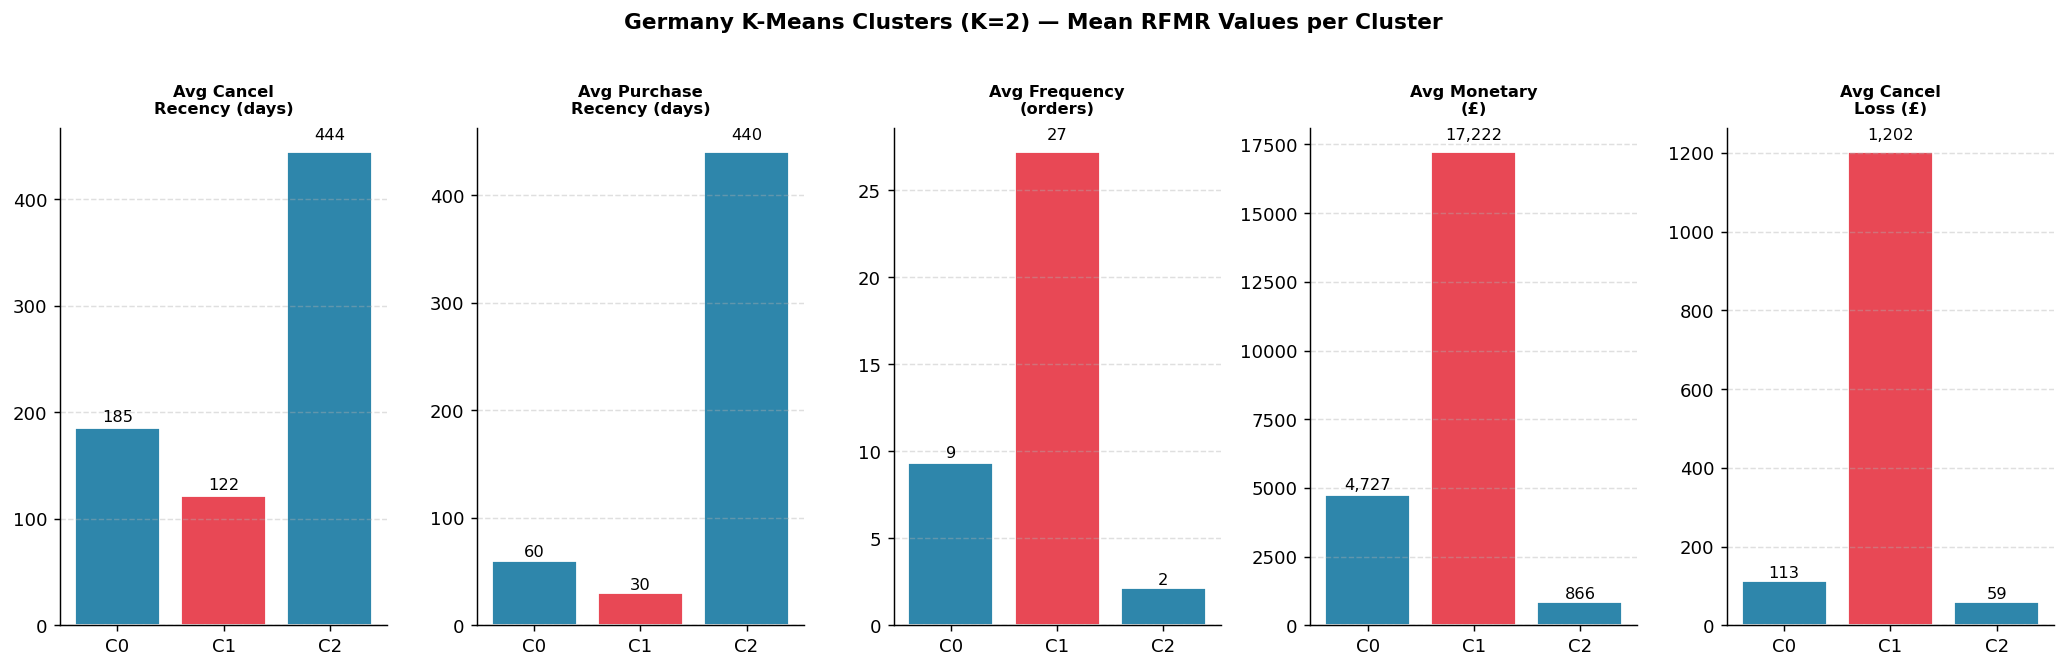

In [37]:
# ─────────────────────────────────────────────────────────────────────────────
# 4.5 K-Means Clustering — Germany (K=2)
# ─────────────────────────────────────────────────────────────────────────────

K_DE = 3

km_de     = KMeans(n_clusters=K_DE, random_state=42, n_init=10)
de_labels = km_de.fit_predict(X_de)

rfmr_germany_all['Cluster'] = de_labels

print(f'Germany clustering complete — K={K_DE}')
print()
print('Cluster sizes:')
print(rfmr_germany_all['Cluster'].value_counts().sort_index().to_string())
print()

# ── Cluster profiles ──────────────────────────────────────────────────────────
de_profile = (rfmr_germany_all
              .groupby('Cluster')
              .agg(
                  Num_Customers       = (cid_col,              'count'),
                  Avg_CancelRecency   = ('R_Recency',           'mean'),
                  Avg_PurchaseRecency = ('R_PurchaseRecency',   'mean'),
                  Avg_Frequency       = ('F_TotalOrders',       'mean'),
                  Avg_Monetary        = ('M_GrossPurchases',    'mean'),
                  Avg_CancelLoss      = ('Re_CancelLoss',       'mean'),
                  Total_CancelLoss    = ('Re_CancelLoss',       'sum')
              )
              .round(2))

de_profile['Loss_Share_Pct'] = (
    de_profile['Total_CancelLoss'] / de_profile['Total_CancelLoss'].sum() * 100
).round(2)

print('Germany Cluster Profiles:')
print(de_profile.to_string())
print()

# ── Visual ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(16, 5))
colors_de = [C_BLUE, C_RED]

for i, (dim, label) in enumerate(zip(dims, labels)):
    ax = axes[i]
    bars = ax.bar(
        [f'C{c}' for c in de_profile.index],
        de_profile[dim],
        color=colors_de,
        edgecolor='white'
    )
    for bar, val in zip(bars, de_profile[dim]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.02,
                f'{val:,.0f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(label, fontsize=9, pad=8)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle('Germany K-Means Clusters (K=2) — Mean RFMR Values per Cluster',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cluster_de_profiles.png', bbox_inches='tight')
plt.show()

In [38]:
# ─────────────────────────────────────────────────────────────────────────────
# 4.6 Cluster Profiling and Business Interpretation — Germany
# ─────────────────────────────────────────────────────────────────────────────

# ── Add cluster names to rfmr_germany_all ────────────────────────────────────
cluster_names_de = {
    0: 'Regulars',
    1: 'Recents Risky',
    2: 'One-and-Gone'
}
rfmr_germany_all['Cluster_Name'] = rfmr_germany_all['Cluster'].map(cluster_names_de)

# ── Full summary table ────────────────────────────────────────────────────────
de_full_summary = (rfmr_germany_all
                   .groupby('Cluster_Name')
                   .agg(
                       Num_Customers       = (cid_col,            'count'),
                       Avg_CancelRecency   = ('R_Recency',         'mean'),
                       Avg_PurchaseRecency = ('R_PurchaseRecency', 'mean'),
                       Avg_Frequency       = ('F_TotalOrders',     'mean'),
                       Avg_Monetary        = ('M_GrossPurchases',  'mean'),
                       Avg_CancelLoss      = ('Re_CancelLoss',     'mean'),
                       Total_CancelLoss    = ('Re_CancelLoss',     'sum')
                   )
                   .round(2))

de_full_summary['Loss_Share_Pct'] = (
    de_full_summary['Total_CancelLoss'] / de_full_summary['Total_CancelLoss'].sum() * 100
).round(2)

print('Germany Complete Cluster Summary:')
print(de_full_summary.to_string())

Germany Complete Cluster Summary:
               Num_Customers  Avg_CancelRecency  Avg_PurchaseRecency  Avg_Frequency  Avg_Monetary  Avg_CancelLoss  Total_CancelLoss  Loss_Share_Pct
Cluster_Name                                                                                                                                       
One-and-Gone               7             444.14               440.14           2.14        865.69           59.38            415.66            3.32
Recents Risky              5             121.80                29.80          27.20      17221.84         1201.86           6009.32           48.01
Regulars                  54             184.78                60.04           9.31       4727.12          112.80           6091.42           48.67


***Business Insights: German Market***

**Cluster 0 — “Active Regulars” | 54 customers | £6,091 | 48.7% of losses**

Most German customers follow a bypass pattern similar to UK Cluster 0. Cancellation recency averages 185 days, while purchase recency averages 60 days, creating a 125-day gap. This indicates these customers canceled at some point but continued purchasing. The average cancellation loss of £112 is less than 3% of their average gross spend of £4,727. These are typical active customers with occasional cancellations and low individual risk. A blanket order policy is sufficient; individual account management is not required.

**Cluster 1 — “Recent High-Value Risk” | 5 customers | £6,009 | 48.0% of losses**

This is the most active and at-risk segment in Germany. Cancellation recency and purchase recency are both recent, at 122 and 30 days, respectively, indicating these customers are actively buying and canceling simultaneously. An average of 27 orders and £17k in spend confirm these are established accounts with ongoing relationships. The average cancellation loss of £1,202 is about 7% of their spend. While not individually catastrophic, this group represents the most current cancellation risk in the German market. These accounts require close monitoring and proactive outreach to address cancellation drivers before the relationship declines.

**Cluster 2 — “One-and-Gone” | 7 customers | £416 | 3.3% of losses**

This group is a behaviorally distinct outlier, correctly identified by K-Means. Cancellation recency and purchase recency are nearly identical at 444 and 440 days, both long ago. With an average of just 2 orders, a monetary value of £865, and an average cancellation loss of £59, these customers made minimal purchases, canceled a small amount, and then disengaged. Representing only 3.3% of German losses, they pose no significant financial risk and require no intervention.

## 6. Customer Enrichment Profile and Recommendations.

In [39]:
# ─────────────────────────────────────────────────────────────────────────────
# 4.6 Enriched Cluster Profiling — UK and Germany
# Adds: Total Gross Sales, Cluster Return Rate %,
#       Avg Cancel Loss as % of Avg Monetary,
#       Customer names for small clusters
# ─────────────────────────────────────────────────────────────────────────────

# ── Display settings ──────────────────────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

# ═════════════════════════════════════════════════════════════════════════════
# UK
# ═════════════════════════════════════════════════════════════════════════════

uk_profile_enriched = (rfmr_uk_core
                       .groupby(['Cluster', 'Cluster_Name'])
                       .agg(
                           Num_Customers       = (cid_col,            'count'),
                           Avg_CancelRecency   = ('R_Recency',         'mean'),
                           Avg_PurchaseRecency = ('R_PurchaseRecency', 'mean'),
                           Avg_Frequency       = ('F_TotalOrders',     'mean'),
                           Avg_Monetary        = ('M_GrossPurchases',  'mean'),
                           Total_GrossSales    = ('M_GrossPurchases',  'sum'),
                           Avg_CancelLoss      = ('Re_CancelLoss',     'mean'),
                           Total_CancelLoss    = ('Re_CancelLoss',     'sum')
                       )
                       .round(2)
                       .reset_index())

outlier_gross  = outlier_row['M_GrossPurchases'].values[0]
outlier_cancel = outlier_row['Re_CancelLoss'].values[0]

uk_profile_enriched['Loss_Share_Pct'] = (
    uk_profile_enriched['Total_CancelLoss'] /
    uk_profile_enriched['Total_CancelLoss'].sum() * 100
).round(2)

uk_profile_enriched['Cluster_Return_Rate_Pct'] = (
    uk_profile_enriched['Total_CancelLoss'] /
    uk_profile_enriched['Total_GrossSales'] * 100
).round(2)

uk_profile_enriched['Avg_CancelLoss_Pct_of_Monetary'] = (
    uk_profile_enriched['Avg_CancelLoss'] /
    uk_profile_enriched['Avg_Monetary'] * 100
).round(2)

print('UK Enriched Cluster Profiles:')
print(uk_profile_enriched.set_index('Cluster_Name').drop(columns='Cluster').T.to_string())
print()

# ── Customer names for small UK clusters ──────────────────────────────────────
print('─' * 60)
print('UK — Question Mark (Cluster 1) — Individual Accounts:')
print('─' * 60)
qm = (rfmr_uk_core[rfmr_uk_core['Cluster'] == 1]
      [[cid_col, 'R_Recency', 'R_PurchaseRecency',
        'F_TotalOrders', 'M_GrossPurchases', 'Re_CancelLoss']]
      .sort_values('Re_CancelLoss', ascending=False))
qm[cid_col] = qm[cid_col].apply(lambda x: f'Customer {int(x)}')
print(qm.to_string(index=False))
print()

print('─' * 60)
print('UK — Stars (Cluster 2) — Top 10 by Gross Purchases:')
print('─' * 60)
stars = (rfmr_uk_core[rfmr_uk_core['Cluster'] == 2]
         [[cid_col, 'R_Recency', 'R_PurchaseRecency',
           'F_TotalOrders', 'M_GrossPurchases', 'Re_CancelLoss']]
         .sort_values('M_GrossPurchases', ascending=False)
         .head(10))
stars[cid_col] = stars[cid_col].apply(lambda x: f'Customer {int(x)}')
print(stars.to_string(index=False))
print()

print('─' * 60)
print('UK — The Event — Customer 12346:')
print('─' * 60)
print(f'  Gross Purchases  : £{outlier_gross:,.2f}')
print(f'  Cancel Loss      : £{outlier_cancel:,.2f}')
print(f'  Return Rate      : {outlier_cancel/outlier_gross*100:.1f}%')
print()


UK Enriched Cluster Profiles:
Cluster_Name                    Normal Bypass  Question Mark        Stars
Num_Customers                        2,259.00           8.00        24.00
Avg_CancelRecency                      290.69         257.00       182.17
Avg_PurchaseRecency                    153.58         255.25       199.79
Avg_Frequency                            9.77          36.88        62.75
Avg_Monetary                         3,978.53      55,149.66    83,787.65
Total_GrossSales                 8,987,499.94     441,197.31 2,010,903.61
Avg_CancelLoss                         131.52      24,767.46     6,168.18
Total_CancelLoss                   297,105.63     198,139.69   148,036.34
Loss_Share_Pct                          46.19          30.80        23.01
Cluster_Return_Rate_Pct                  3.31          44.91         7.36
Avg_CancelLoss_Pct_of_Monetary           3.31          44.91         7.36

────────────────────────────────────────────────────────────
UK — Question Mark (

### UK Cluster Business Recommendation

**Cluster 0 — Normal Bypass | Accept the Risk**

This group consists of 2,259 customers and generates £8.99 million in gross sales, making it the largest segment of the UK customer base. The average loss per cancellation is £131 per customer, and the return rate of 3.31 percent is acceptable for this market size. These customers have canceled before.
Purchasing activity continues, with an average of 154 days since the last purchase, indicating ongoing engagement. A general policy on order conditions is sufficient for this group.

**Cluster 1 — Question Mark | Investigate and Recover**

Eight customers generated £441,197 in gross sales and had a 44.91% return rate. Their cancellation and purchase recency were nearly identical, at 257 and 255 days, respectively, suggesting both activities stopped at the same time. These individuals were likely new wholesale customers. The data does not clarify whether cancellation prompted their exit or vice versa.

These may be high-value accounts with recovery potential. Review each account by examining order history, cancellation timing, and communication records, then assess re-engagement feasibility. Recovering just three of these eight accounts would result in significant revenue recovery. 

**Cluster 2 — Stars | Protect and Reduce Friction | Target**

Twenty-four customers generate £2.01 million in gross sales, making this the highest-value segment in the UK market. An average order frequency of 63 invoices and an average spend of £83,787 confirm these are the most active and valuable buyers. Their return rate of 7.36 percent is double that of Normal Bypass, which, on a base of £2 million in gross sales, represents a significant and addressable financial exposure. Financial exposure.

***Two targeted strategies are recommended:***

Dedicated account management: Assign a single point of contact to each of the 24 accounts. High-frequency buyers typically respond well to direct relationship management.

Real-time inventory visibility: Provide these customers with access to live stock levels before they place orders. This will help prevent cancellations due to unavailable stock, as buyers can confirm availability before committing.

In [40]:
# ═════════════════════════════════════════════════════════════════════════════
# Germany
# ═════════════════════════════════════════════════════════════════════════════

de_profile_enriched = (rfmr_germany_all
                       .groupby(['Cluster', 'Cluster_Name'])
                       .agg(
                           Num_Customers       = (cid_col,            'count'),
                           Avg_CancelRecency   = ('R_Recency',         'mean'),
                           Avg_PurchaseRecency = ('R_PurchaseRecency', 'mean'),
                           Avg_Frequency       = ('F_TotalOrders',     'mean'),
                           Avg_Monetary        = ('M_GrossPurchases',  'mean'),
                           Total_GrossSales    = ('M_GrossPurchases',  'sum'),
                           Avg_CancelLoss      = ('Re_CancelLoss',     'mean'),
                           Total_CancelLoss    = ('Re_CancelLoss',     'sum')
                       )
                       .round(2)
                       .reset_index())

de_profile_enriched['Loss_Share_Pct'] = (
    de_profile_enriched['Total_CancelLoss'] /
    de_profile_enriched['Total_CancelLoss'].sum() * 100
).round(2)

de_profile_enriched['Cluster_Return_Rate_Pct'] = (
    de_profile_enriched['Total_CancelLoss'] /
    de_profile_enriched['Total_GrossSales'] * 100
).round(2)

de_profile_enriched['Avg_CancelLoss_Pct_of_Monetary'] = (
    de_profile_enriched['Avg_CancelLoss'] /
    de_profile_enriched['Avg_Monetary'] * 100
).round(2)

print('Germany Enriched Cluster Profiles:')
print(de_profile_enriched.set_index('Cluster_Name').drop(columns='Cluster').T.to_string())
print()

# ── Customer names for small Germany clusters ─────────────────────────────────
print('─' * 60)
print('Germany — Recent Risky (Cluster 1) — Individual Accounts:')
print('─' * 60)
risky_de = (rfmr_germany_all[rfmr_germany_all['Cluster'] == 1]
            [[cid_col, 'R_Recency', 'R_PurchaseRecency',
              'F_TotalOrders', 'M_GrossPurchases', 'Re_CancelLoss']]
            .sort_values('Re_CancelLoss', ascending=False))
risky_de[cid_col] = risky_de[cid_col].apply(lambda x: f'Customer {int(x)}')
print(risky_de.to_string(index=False))
print()

print('─' * 60)
print('Germany — One-and-Gone (Cluster 2) — Individual Accounts:')
print('─' * 60)
gone_de = (rfmr_germany_all[rfmr_germany_all['Cluster'] == 2]
           [[cid_col, 'R_Recency', 'R_PurchaseRecency',
             'F_TotalOrders', 'M_GrossPurchases', 'Re_CancelLoss']]
           .sort_values('Re_CancelLoss', ascending=False))
gone_de[cid_col] = gone_de[cid_col].apply(lambda x: f'Customer {int(x)}')
print(gone_de.to_string(index=False))

Germany Enriched Cluster Profiles:
Cluster_Name                     Regulars  Recents Risky  One-and-Gone
Num_Customers                       54.00           5.00          7.00
Avg_CancelRecency                  184.78         121.80        444.14
Avg_PurchaseRecency                 60.04          29.80        440.14
Avg_Frequency                        9.31          27.20          2.14
Avg_Monetary                     4,727.12      17,221.84        865.69
Total_GrossSales               255,264.66      86,109.22      6,059.82
Avg_CancelLoss                     112.80       1,201.86         59.38
Total_CancelLoss                 6,091.42       6,009.32        415.66
Loss_Share_Pct                      48.67          48.01          3.32
Cluster_Return_Rate_Pct              2.39           6.98          6.86
Avg_CancelLoss_Pct_of_Monetary       2.39           6.98          6.86

────────────────────────────────────────────────────────────
Germany — Recent Risky (Cluster 1) — Individual Acc

### Germany Cluster Business Recommendations

**Cluster 0 — Regulars | Accept the Risk**

Fifty-four customers generated £255,264 in total gross sales. The 2.39% return rate is the lowest among all clusters in both markets and is below the UK Normal Bypass equivalent of 3.31%. An average purchase recency of 60 days indicates these customers are actively buying, while an average cancel recency of 185 days shows cancellations are mostly in the past. The gap between these metrics reflects the same bypass pattern seen in the UK, where customers moved past cancellations and continued purchasing. No action is needed beyond standard order policies.

**Cluster 1 — Recent Risky | Reduce and Monitor | Target**

Five accounts generated £86,109 in total gross sales with a 6.98% return rate. An average purchase recency of 30 days confirms these are the most active buyers in the German market, likely re-wholesalers placing regular orders. The 92-day gap between purchase recency (30 days) and cancel recency (122 days) shows their most recent cancellation occurred over three months before their latest purchase. They continue to buy despite past cancellations, indicating the relationship remains but may be strained. Assign a dedicated account manager to each account to identify cancellation causes and intervene before issues escalate.

**Cluster 2 — One-and-Gone | No Action Required**

Seven accounts generated £6,060 in total gross sales, with both average cancellation and purchase recency exceeding 440 days. These customers have been inactive for over a year. An average of two orders and £865 in spend confirm these were minimal, one-time engagements with no ongoing relationship. Representing 3.32% of German losses, they are not a financial priority. Reactivation is not recommended.

# Section 5: Forecasting & Cancellation Prediction — United Kingdom
## 1. Gross Sales Forecast — Prophet vs ARIMA

In [41]:
import subprocess
subprocess.run(['pip', 'install', 'prophet', 'pmdarima'], check=True)

CompletedProcess(args=['pip', 'install', 'prophet', 'pmdarima'], returncode=0)

In [42]:
# ── Imports — run once after installing prophet and pmdarima ──────────────────
from prophet import Prophet
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error
import statsmodels.api as sm

UK Monthly Gross Sales Series:
        Month   GrossSales
0  2009-12-01   750,286.27
1  2010-01-01   511,797.66
2  2010-02-01   454,762.72
3  2010-03-01   721,045.46
4  2010-04-01   584,552.10
5  2010-05-01   560,085.82
6  2010-06-01   652,304.49
7  2010-07-01   559,438.04
8  2010-08-01   596,023.47
9  2010-09-01   773,008.50
10 2010-10-01 1,000,334.10
11 2010-11-01 1,275,469.99
12 2010-12-01 1,153,335.42
13 2011-01-01   561,260.55
14 2011-02-01   430,027.95
15 2011-03-01   586,067.71
16 2011-04-01   476,512.81
17 2011-05-01   631,167.61
18 2011-06-01   619,497.19
19 2011-07-01   601,807.13
20 2011-08-01   607,924.88
21 2011-09-01   896,992.75
22 2011-10-01   938,847.55
23 2011-11-01 1,325,338.23
24 2011-12-01   112,764.94

Total months     : 25
Date range       : Dec 2009 → Dec 2011
Total gross sales: £17,380,653.35


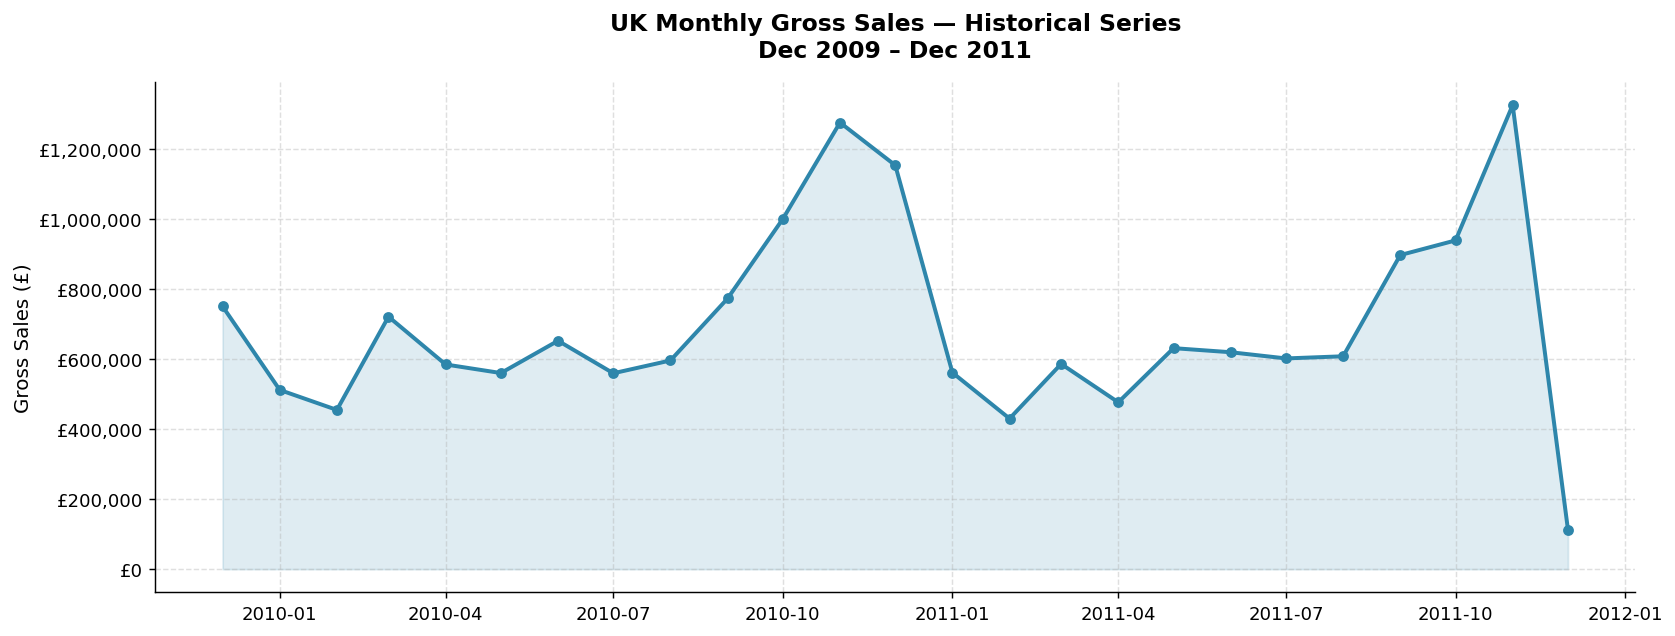

Train set: 20 months (Dec 2009 → Jul 2011)
Test set : 5 months (Aug 2011 → Dec 2011)



Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.
11:47:27 - cmdstanpy - INFO - Chain [1] start processing
11:47:37 - cmdstanpy - INFO - Chain [1] done processing


Prophet — Test MAE  : £565,320.69
Prophet — Test RMSE : £724,640.43

Prophet 6-Month Forecast:
        ds       yhat  yhat_lower  yhat_upper
2012-01-01 575,837.05  571,330.30  580,531.56
2012-02-01 386,473.45  382,719.13  390,330.03
2012-03-01 835,924.96  825,670.67  846,692.97
2012-04-01 678,588.95  668,659.05  689,067.26
2012-05-01 319,604.14  313,911.73  325,423.19
2012-06-01 572,667.16  560,977.74  584,927.28

ARIMA best order: (0, 0, 1) | Seasonal: (0, 1, 0, 12)

ARIMA — Test MAE  : £258,186.28
ARIMA — Test RMSE : £470,032.36

ARIMA 6-Month Forecast:
        ds       yhat  yhat_lower   yhat_upper
2012-01-01 695,226.13  167,552.75 1,222,899.52
2012-02-01 695,226.13  167,552.75 1,222,899.52
2012-03-01 695,226.13  167,552.75 1,222,899.52
2012-04-01 695,226.13  167,552.75 1,222,899.52
2012-05-01 695,226.13  167,552.75 1,222,899.52
2012-06-01 695,226.13  167,552.75 1,222,899.52



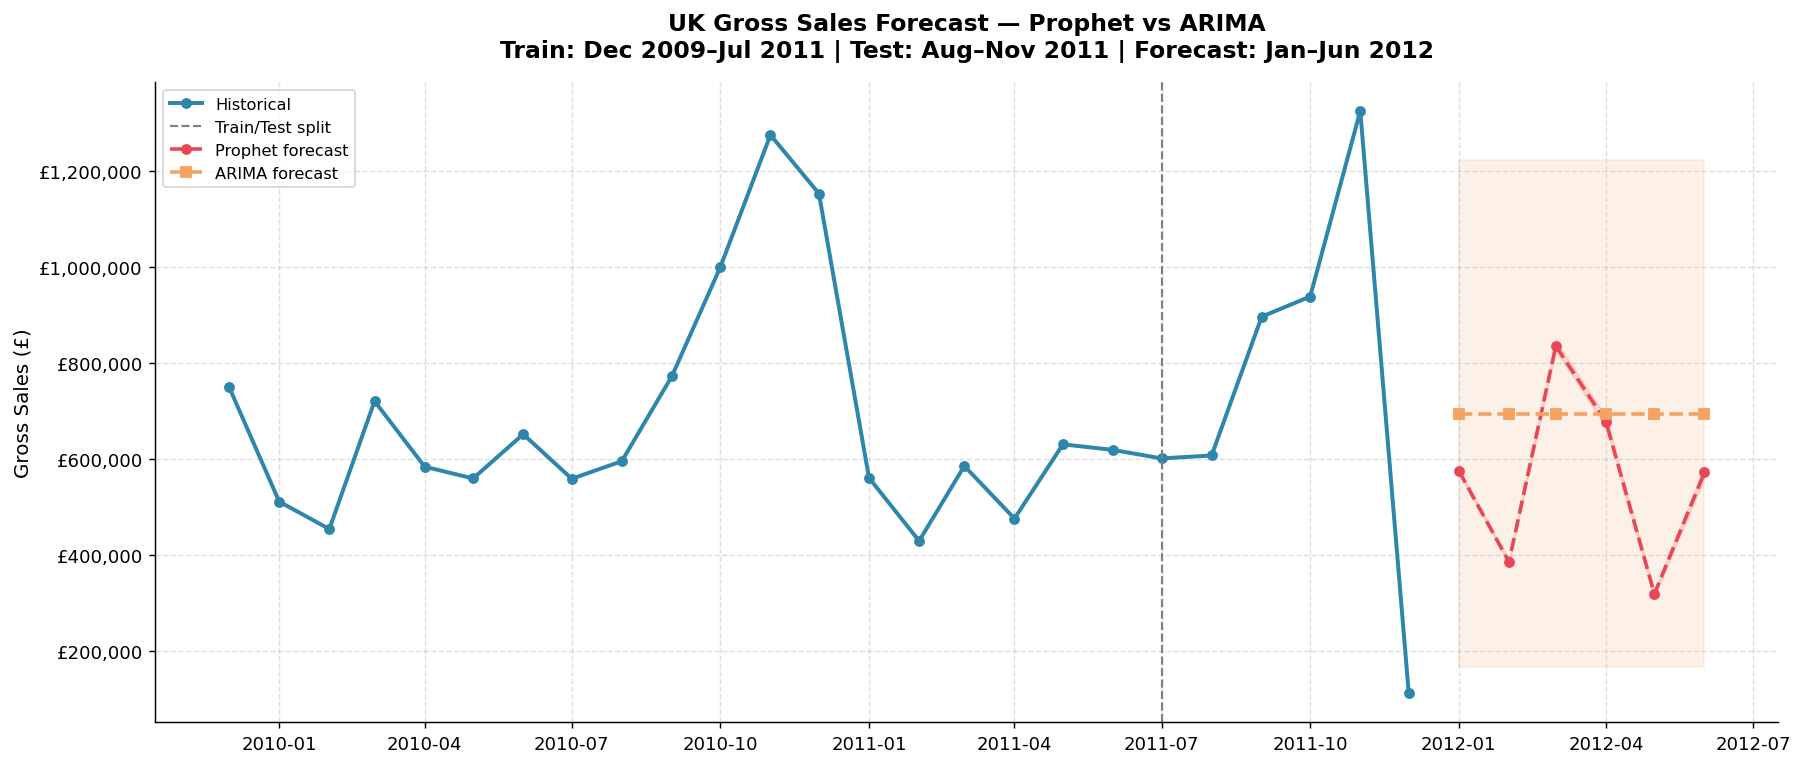

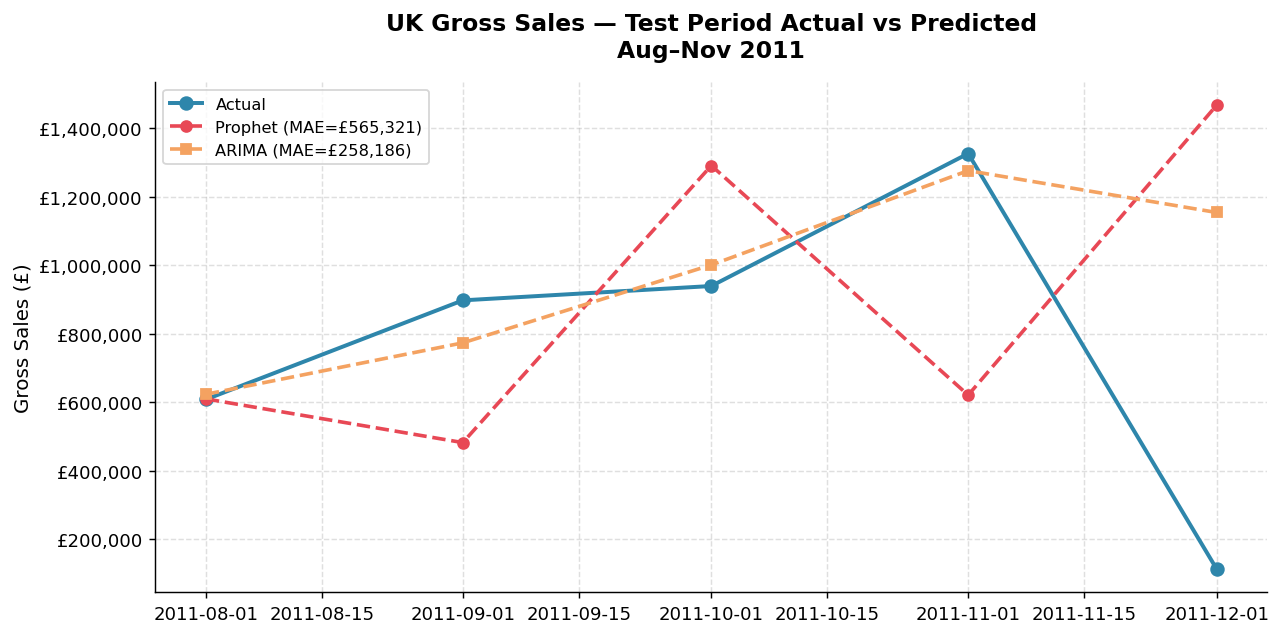

In [43]:
# ─────────────────────────────────────────────────────────────────────────────
# 5.1 Gross Sales Forecast — Prophet vs ARIMA
# UK market only | Monthly gross sales in £
# Train: first 20 months | Test: last 4 months | Forecast: 6 months ahead
# ─────────────────────────────────────────────────────────────────────────────

# ── Step 1: Build monthly gross sales series — UK only ────────────────────────
uk_sales = (df[(df['Country'] == 'United Kingdom') &
               (df['Is_Return'] == False)]
            .assign(GrossValue=lambda x: x['Quantity'] * x['Price'])
            .groupby(df['InvoiceDate'].dt.to_period('M'))['GrossValue']
            .sum()
            .reset_index())

uk_sales.columns    = ['Month', 'GrossSales']
uk_sales['Month']   = uk_sales['Month'].dt.to_timestamp()
uk_sales            = uk_sales.sort_values('Month').reset_index(drop=True)

print('UK Monthly Gross Sales Series:')
print(uk_sales.to_string())
print()
print(f'Total months     : {len(uk_sales)}')
print(f'Date range       : {uk_sales["Month"].min().strftime("%b %Y")} → {uk_sales["Month"].max().strftime("%b %Y")}')
print(f'Total gross sales: £{uk_sales["GrossSales"].sum():,.2f}')

# ── Step 2: Plot the series before modelling ──────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(uk_sales['Month'], uk_sales['GrossSales'],
        color=C_BLUE, linewidth=2.2, marker='o', markersize=5)
ax.fill_between(uk_sales['Month'], uk_sales['GrossSales'],
                alpha=0.15, color=C_BLUE)
ax.set_title('UK Monthly Gross Sales — Historical Series\nDec 2009 – Dec 2011',
             pad=14)
ax.set_ylabel('Gross Sales (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('forecast_uk_sales_historical.png', bbox_inches='tight')
plt.show()

# ── Step 3: Train / Test split ────────────────────────────────────────────────
TRAIN_SIZE = 20
train = uk_sales.iloc[:TRAIN_SIZE].copy()
test  = uk_sales.iloc[TRAIN_SIZE:].copy()

print(f'Train set: {len(train)} months ({train["Month"].iloc[0].strftime("%b %Y")} → {train["Month"].iloc[-1].strftime("%b %Y")})')
print(f'Test set : {len(test)} months ({test["Month"].iloc[0].strftime("%b %Y")} → {test["Month"].iloc[-1].strftime("%b %Y")})')
print()

# ── Step 4: Prophet ───────────────────────────────────────────────────────────
# Prepare Prophet dataframe
prophet_train = train.rename(columns={'Month': 'ds', 'GrossSales': 'y'})
prophet_full  = uk_sales.rename(columns={'Month': 'ds', 'GrossSales': 'y'})

# Initialize and fit
prophet_model = Prophet(
    seasonality_mode='multiplicative',  # sales scale with volume — multiplicative fits better
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    interval_width=0.95
)
prophet_model.fit(prophet_train)

# Predict on test period + 6 months ahead
future_prophet = prophet_model.make_future_dataframe(
    periods=len(test) + 6,
    freq='MS'
)
forecast_prophet = prophet_model.predict(future_prophet)

# Extract test predictions
prophet_test_pred = forecast_prophet[
    forecast_prophet['ds'].isin(test['Month'])
]['yhat'].values

# Extract 6-month forward forecast
prophet_future = forecast_prophet[
    forecast_prophet['ds'] > uk_sales['Month'].max()
][['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head(6)

# Metrics on test set
prophet_mae  = mean_absolute_error(test['GrossSales'], prophet_test_pred)
prophet_rmse = mean_squared_error(test['GrossSales'], prophet_test_pred) ** 0.5

print(f'Prophet — Test MAE  : £{prophet_mae:,.2f}')
print(f'Prophet — Test RMSE : £{prophet_rmse:,.2f}')
print()
print('Prophet 6-Month Forecast:')
print(prophet_future.to_string(index=False))
print()

# ── Step 5: ARIMA ─────────────────────────────────────────────────────────────
# auto_arima finds optimal p, d, q automatically
arima_model = auto_arima(
    train['GrossSales'],
    seasonal=True,
    m=12,                  # monthly seasonality
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    information_criterion='aic'
)

print(f'ARIMA best order: {arima_model.order} | Seasonal: {arima_model.seasonal_order}')
print()

# Predict test set
arima_test_pred = arima_model.predict(n_periods=len(test))

# Forecast 6 months ahead — refit on full series first
arima_full = auto_arima(
    uk_sales['GrossSales'],
    seasonal=True,
    m=12,
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    information_criterion='aic'
)
arima_future_pred, arima_conf_int = arima_full.predict(
    n_periods=6,
    return_conf_int=True
)

# Build ARIMA future dataframe
future_dates = pd.date_range(
    start=uk_sales['Month'].max() + pd.DateOffset(months=1),
    periods=6,
    freq='MS'
)
arima_future = pd.DataFrame({
    'ds'         : future_dates,
    'yhat'       : arima_future_pred,
    'yhat_lower' : arima_conf_int[:, 0],
    'yhat_upper' : arima_conf_int[:, 1]
})

# Metrics on test set
arima_mae  = mean_absolute_error(test['GrossSales'], arima_test_pred)
arima_rmse = mean_squared_error(test['GrossSales'], arima_test_pred) ** 0.5

print(f'ARIMA — Test MAE  : £{arima_mae:,.2f}')
print(f'ARIMA — Test RMSE : £{arima_rmse:,.2f}')
print()
print('ARIMA 6-Month Forecast:')
print(arima_future.to_string(index=False))
print()

# ── Step 6: Plot both forecasts together ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

# Historical
ax.plot(uk_sales['Month'], uk_sales['GrossSales'],
        color=C_BLUE, linewidth=2.2, marker='o', markersize=5, label='Historical')

# Train/test split line
ax.axvline(x=train['Month'].iloc[-1], color='grey',
           linestyle='--', linewidth=1.2, label='Train/Test split')

# Prophet forecast
ax.plot(prophet_future['ds'], prophet_future['yhat'],
        color=C_RED, linewidth=2, linestyle='--', marker='o',
        markersize=5, label='Prophet forecast')
ax.fill_between(prophet_future['ds'],
                prophet_future['yhat_lower'],
                prophet_future['yhat_upper'],
                alpha=0.15, color=C_RED)

# ARIMA forecast
ax.plot(arima_future['ds'], arima_future['yhat'],
        color=C_ORANGE, linewidth=2, linestyle='--', marker='s',
        markersize=5, label='ARIMA forecast')
ax.fill_between(arima_future['ds'],
                arima_future['yhat_lower'],
                arima_future['yhat_upper'],
                alpha=0.15, color=C_ORANGE)

ax.set_title('UK Gross Sales Forecast — Prophet vs ARIMA\n'
             'Train: Dec 2009–Jul 2011 | Test: Aug–Nov 2011 | Forecast: Jan–Jun 2012',
             pad=14)
ax.set_ylabel('Gross Sales (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend(fontsize=9)
ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('forecast_uk_sales_prophet_vs_arima.png', bbox_inches='tight')
plt.show()

# ── Step 7: Test period overlay — how well did each model fit? ────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(test['Month'], test['GrossSales'],
        color=C_BLUE, linewidth=2.2, marker='o', markersize=7, label='Actual')
ax.plot(test['Month'], prophet_test_pred,
        color=C_RED, linewidth=2, linestyle='--', marker='o',
        markersize=6, label=f'Prophet (MAE=£{prophet_mae:,.0f})')
ax.plot(test['Month'], arima_test_pred,
        color=C_ORANGE, linewidth=2, linestyle='--', marker='s',
        markersize=6, label=f'ARIMA (MAE=£{arima_mae:,.0f})')

ax.set_title('UK Gross Sales — Test Period Actual vs Predicted\nAug–Nov 2011',
             pad=14)
ax.set_ylabel('Gross Sales (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend(fontsize=9)
ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('forecast_uk_sales_test_comparison.png', bbox_inches='tight')
plt.show()

In [44]:
#Checking Model Overall Sales for Outliers
print('Test set actual values:')
print(test[['Month', 'GrossSales']].to_string(index=False))
print()
print(f'Test mean : £{test["GrossSales"].mean():,.2f}')
print(f'Test min  : £{test["GrossSales"].min():,.2f}')
print(f'Test max  : £{test["GrossSales"].max():,.2f}')

Test set actual values:
     Month   GrossSales
2011-08-01   607,924.88
2011-09-01   896,992.75
2011-10-01   938,847.55
2011-11-01 1,325,338.23
2011-12-01   112,764.94

Test mean : £776,373.67
Test min  : £112,764.94
Test max  : £1,325,338.23


Metrics recalculated on complete months only (Aug–Nov 2011)
December 2011 excluded — partial month, 9 days of data only

Prophet — MAE  : £368,159.94
Prophet — RMSE : £445,056.45

ARIMA   — MAE  : £62,590.23
ARIMA   — RMSE : £73,934.41



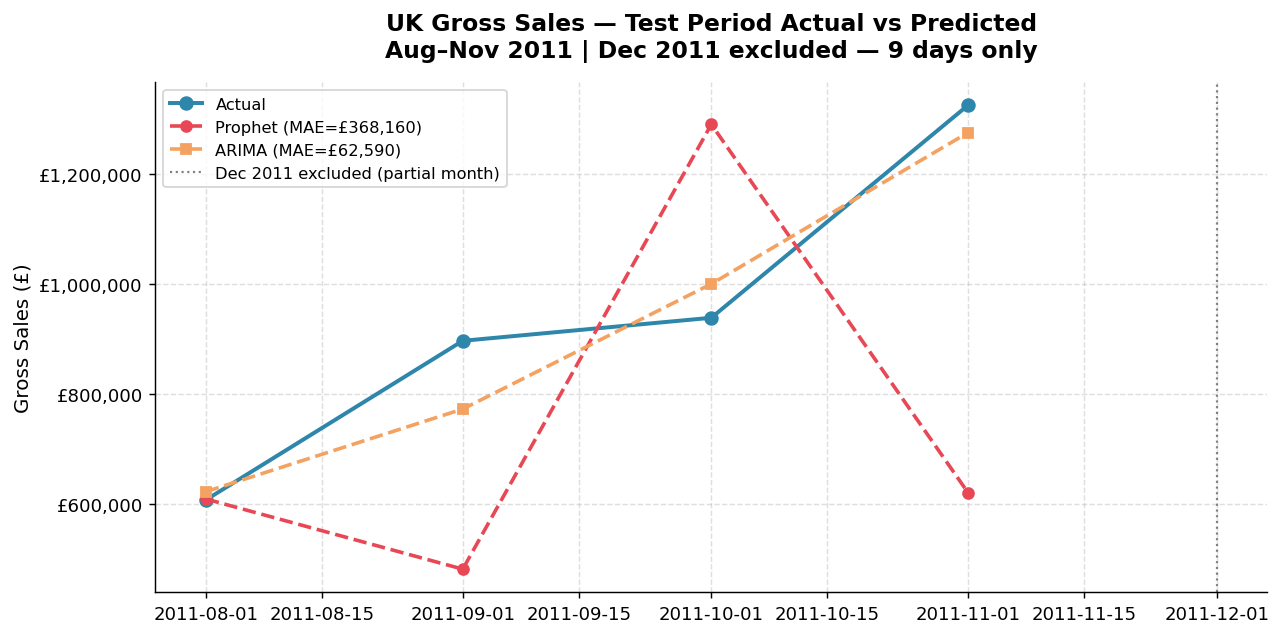

In [45]:
# ── Recalculate metrics excluding December 2011 (incomplete month — 9 days only)
test_clean = test[test['Month'] < '2011-12-01'].copy()

# Prophet predictions for clean test period
prophet_test_pred_clean = forecast_prophet[
    forecast_prophet['ds'].isin(test_clean['Month'])
]['yhat'].values

# ARIMA predictions for clean test period
arima_test_pred_clean = arima_model.predict(n_periods=len(test_clean))

# Recalculate metrics
prophet_mae_clean  = mean_absolute_error(test_clean['GrossSales'], prophet_test_pred_clean)
prophet_rmse_clean = mean_squared_error(test_clean['GrossSales'], prophet_test_pred_clean) ** 0.5

arima_mae_clean  = mean_absolute_error(test_clean['GrossSales'], arima_test_pred_clean)
arima_rmse_clean = mean_squared_error(test_clean['GrossSales'], arima_test_pred_clean) ** 0.5

print('Metrics recalculated on complete months only (Aug–Nov 2011)')
print('December 2011 excluded — partial month, 9 days of data only')
print()
print(f'Prophet — MAE  : £{prophet_mae_clean:,.2f}')
print(f'Prophet — RMSE : £{prophet_rmse_clean:,.2f}')
print()
print(f'ARIMA   — MAE  : £{arima_mae_clean:,.2f}')
print(f'ARIMA   — RMSE : £{arima_rmse_clean:,.2f}')
print()

# ── Updated test period plot ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(test_clean['Month'], test_clean['GrossSales'],
        color=C_BLUE, linewidth=2.2, marker='o', markersize=7, label='Actual')
ax.plot(test_clean['Month'], prophet_test_pred_clean,
        color=C_RED, linewidth=2, linestyle='--', marker='o',
        markersize=6, label=f'Prophet (MAE=£{prophet_mae_clean:,.0f})')
ax.plot(test_clean['Month'], arima_test_pred_clean,
        color=C_ORANGE, linewidth=2, linestyle='--', marker='s',
        markersize=6, label=f'ARIMA (MAE=£{arima_mae_clean:,.0f})')

ax.axvline(x=pd.Timestamp('2011-12-01'), color='grey',
           linestyle=':', linewidth=1.2, label='Dec 2011 excluded (partial month)')

ax.set_title('UK Gross Sales — Test Period Actual vs Predicted\n'
             'Aug–Nov 2011 | Dec 2011 excluded — 9 days only', pad=14)
ax.set_ylabel('Gross Sales (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend(fontsize=9)
ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('forecast_uk_sales_test_clean.png', bbox_inches='tight')
plt.show()

In [46]:
# ─────────────────────────────────────────────────────────────────────────────
# Table 1: Model Comparison — MAE and RMSE (Dec 2011 excluded)
# Table 2: Forecast vs Last Year Actual with variance
# ─────────────────────────────────────────────────────────────────────────────

# ── Table 1: MAE and RMSE comparison ─────────────────────────────────────────
comparison_metrics = pd.DataFrame({
    'Model'  : ['Prophet', 'ARIMA'],
    'MAE (£)': [prophet_mae_clean, arima_mae_clean],
    'RMSE (£)': [prophet_rmse_clean, arima_rmse_clean],
    'MAE vs RMSE gap (£)': [
        prophet_rmse_clean - prophet_mae_clean,
        arima_rmse_clean   - arima_mae_clean
    ],
    'Winner' : ['', '✓']
})

pd.set_option('display.float_format', '{:,.2f}'.format)
print('Table 1 — Model Comparison: MAE and RMSE (Test: Aug–Nov 2011 | Dec excluded)')
print('=' * 70)
print(comparison_metrics.to_string(index=False))
print()
print('Note: Lower MAE and RMSE = better. ARIMA wins on precision.')
print('Note: ARIMA forecast is flat (£695k every month) — unusable for planning.')
print('Note: Prophet selected as primary forecast model for business planning.')
print()

# ── Table 2: Forecast vs Last Year Actual ────────────────────────────────────
# Last year actuals = Jan–Jun 2011 (same months as forecast period)
last_year_actuals = uk_sales[
    (uk_sales['Month'] >= '2011-01-01') &
    (uk_sales['Month'] <= '2011-06-01')
].copy().reset_index(drop=True)

forecast_comparison = pd.DataFrame({
    'Month'                : prophet_future['ds'].dt.strftime('%b %Y').values,
    'Prophet_Forecast (£)' : prophet_future['yhat'].values,
    'ARIMA_Forecast (£)'   : arima_future['yhat'].values,
    'Last_Year_Actual (£)' : last_year_actuals['GrossSales'].values,
})

forecast_comparison['Prophet_vs_LastYear (£)'] = (
    forecast_comparison['Prophet_Forecast (£)'] -
    forecast_comparison['Last_Year_Actual (£)']
).round(2)

forecast_comparison['Prophet_vs_LastYear (%)'] = (
    forecast_comparison['Prophet_vs_LastYear (£)'] /
    forecast_comparison['Last_Year_Actual (£)'] * 100
).round(2)

forecast_comparison['ARIMA_vs_LastYear (£)'] = (
    forecast_comparison['ARIMA_Forecast (£)'] -
    forecast_comparison['Last_Year_Actual (£)']
).round(2)

forecast_comparison['ARIMA_vs_LastYear (%)'] = (
    forecast_comparison['ARIMA_vs_LastYear (£)'] /
    forecast_comparison['Last_Year_Actual (£)'] * 100
).round(2)

# ── Table 2: Forecast vs Last Year Actual — split for readability ─────────────
print('Table 2a — Forecast Values (Jan–Jun 2012 vs Jan–Jun 2011)')
print('=' * 65)
print(forecast_comparison[['Month', 'Prophet_Forecast (£)',
                            'ARIMA_Forecast (£)',
                            'Last_Year_Actual (£)']].to_string(index=False))
print()

print('Table 2b — Variance vs Last Year')
print('=' * 65)
print(forecast_comparison[['Month',
                            'Prophet_vs_LastYear (£)', 'Prophet_vs_LastYear (%)',
                            'ARIMA_vs_LastYear (£)',   'ARIMA_vs_LastYear (%)']].to_string(index=False))
print()
print('Note: Positive = forecast higher than last year | Negative = lower')

Table 1 — Model Comparison: MAE and RMSE (Test: Aug–Nov 2011 | Dec excluded)
  Model    MAE (£)   RMSE (£)  MAE vs RMSE gap (£) Winner
Prophet 368,159.94 445,056.45            76,896.52       
  ARIMA  62,590.23  73,934.41            11,344.18      ✓

Note: Lower MAE and RMSE = better. ARIMA wins on precision.
Note: ARIMA forecast is flat (£695k every month) — unusable for planning.
Note: Prophet selected as primary forecast model for business planning.

Table 2a — Forecast Values (Jan–Jun 2012 vs Jan–Jun 2011)
   Month  Prophet_Forecast (£)  ARIMA_Forecast (£)  Last_Year_Actual (£)
Jan 2012            575,837.05          695,226.13            561,260.55
Feb 2012            386,473.45          695,226.13            430,027.95
Mar 2012            835,924.96          695,226.13            586,067.71
Apr 2012            678,588.95          695,226.13            476,512.81
May 2012            319,604.14          695,226.13            631,167.61
Jun 2012            572,667.16          695,2

#### Forecast insights - Sales Forecast.

ARIMA outperforms Prophet on test accuracy, with an MAE of £62,590 compared to £368,160. However, its 6-month forecast remains flat at £695,226 each month, offering no variation. This flat forecast does not support resource allocation planning, as it provides no guidance on when to scale up or reduce resources.

Prophet is less precise but generates forecasts with meaningful monthly variation. For example, March 2012 is projected at £835,925, while February is £386,473. This variation enables operations to pre-position or conserve resources as needed. For this reason, **Prophet is selected as the primary model.**

Both models are **limited by the two-year data window**. With only 24 monthly observations, neither model can fully capture annual seasonality. Expanding the dataset to four or more years would significantly improve reliability.



## 2. Cancellation Prediction

Monthly cancellation loss per cluster:
               count        sum      mean       std
Cluster_Name                                       
Anonymous         24 383,320.33 15,971.68 22,100.06
Normal Bypass     25 297,105.63 11,884.23  5,458.61
Question Mark     22 198,139.69  9,006.35 10,807.70
Stars             24 148,036.34  6,168.18  6,875.92
The Event          4  77,620.14 19,405.04 38,519.28



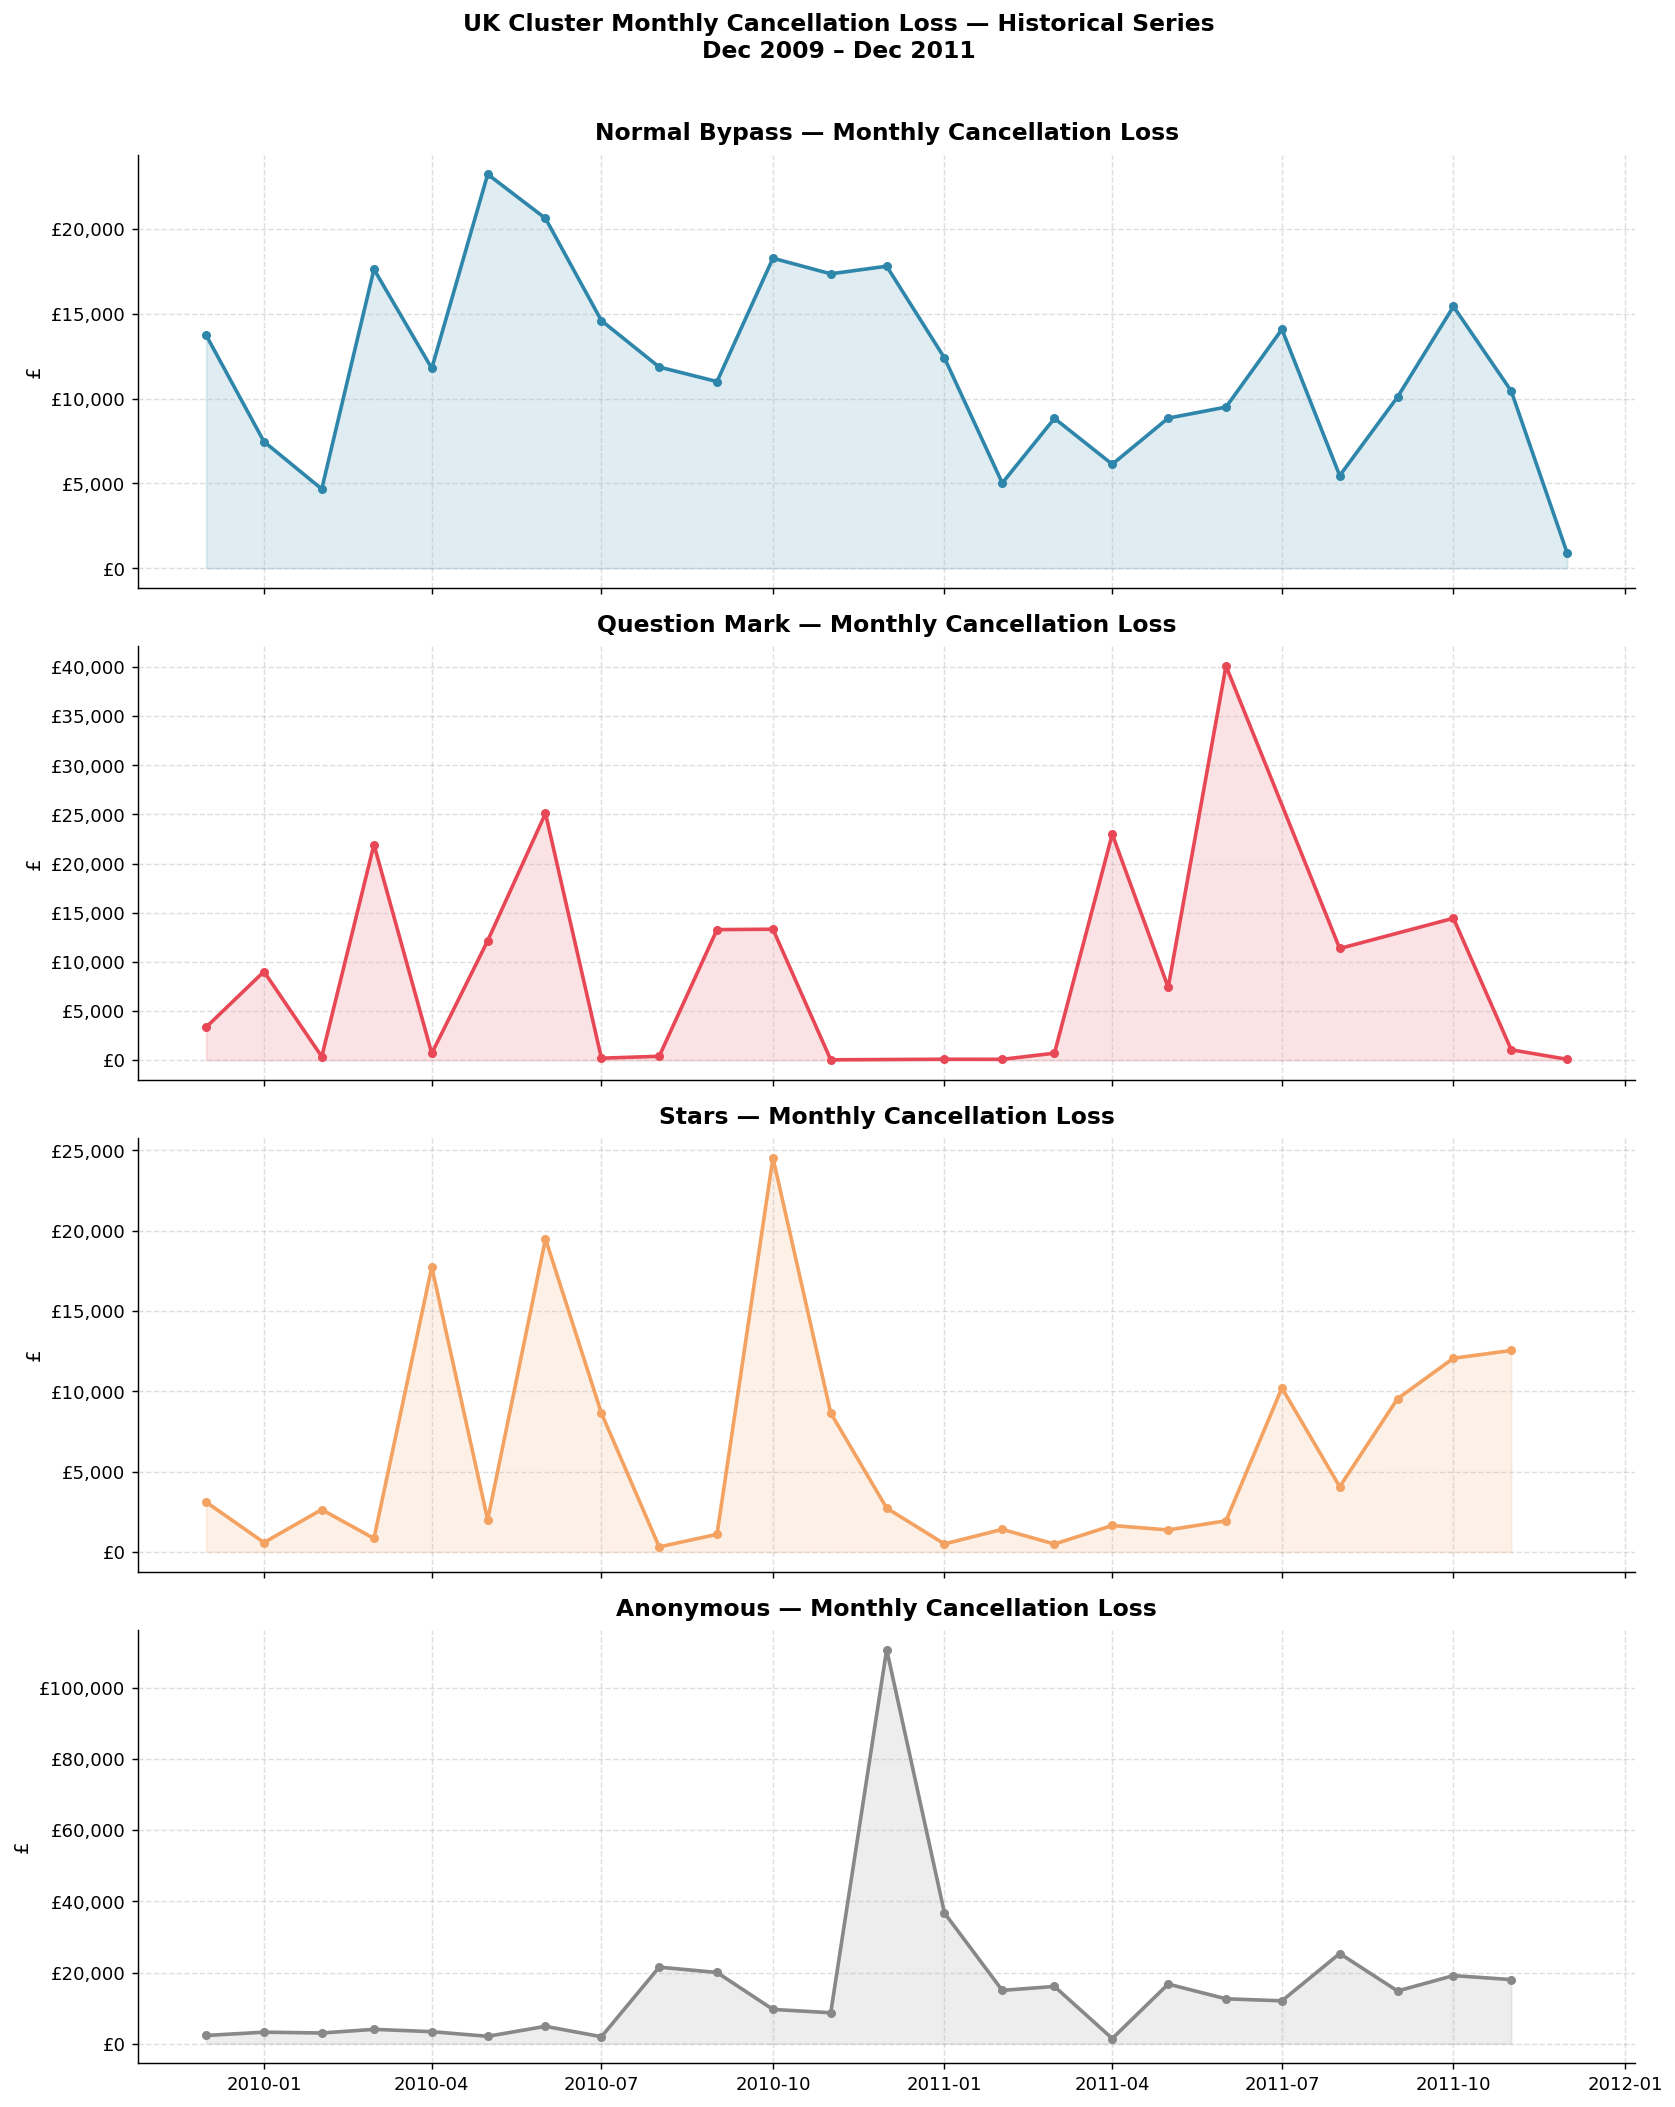

Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.
11:47:43 - cmdstanpy - INFO - Chain [1] start processing
11:47:58 - cmdstanpy - INFO - Chain [1] done processing


Normal Bypass — Prophet MAE  : £8,865.32
Normal Bypass — Prophet RMSE : £8,899.74

Normal Bypass 6-Month Forecast:
     Month     yhat  yhat_lower  yhat_upper
2012-01-01 8,995.03    8,890.19    9,093.84
2012-02-01 2,931.78    2,883.94    2,977.29
2012-03-01 6,215.45    6,076.17    6,348.07
2012-04-01 3,479.77    3,372.82    3,582.38
2012-05-01 8,188.02    7,837.29    8,522.85
2012-06-01 5,308.50    4,996.72    5,610.86

Question Mark — 6-Month Baseline Forecast (Mean ± 95% CI):
     Month      yhat  yhat_lower  yhat_upper
2012-01-01  4,550.10        0.00   16,912.87
2012-02-01    220.16        0.00      603.12
2012-03-01 11,320.80        0.00   40,744.63
2012-04-01 11,841.44        0.00   42,766.96
2012-05-01  9,778.71    3,212.98   16,344.44
2012-06-01 32,606.64   11,830.03   53,383.26

Stars — 6-Month Baseline Forecast (Mean ± 95% CI):
     Month      yhat  yhat_lower  yhat_upper
2012-01-01    538.02      416.81      659.23
2012-02-01  2,018.04      311.20    3,724.89
2012-03-01    6

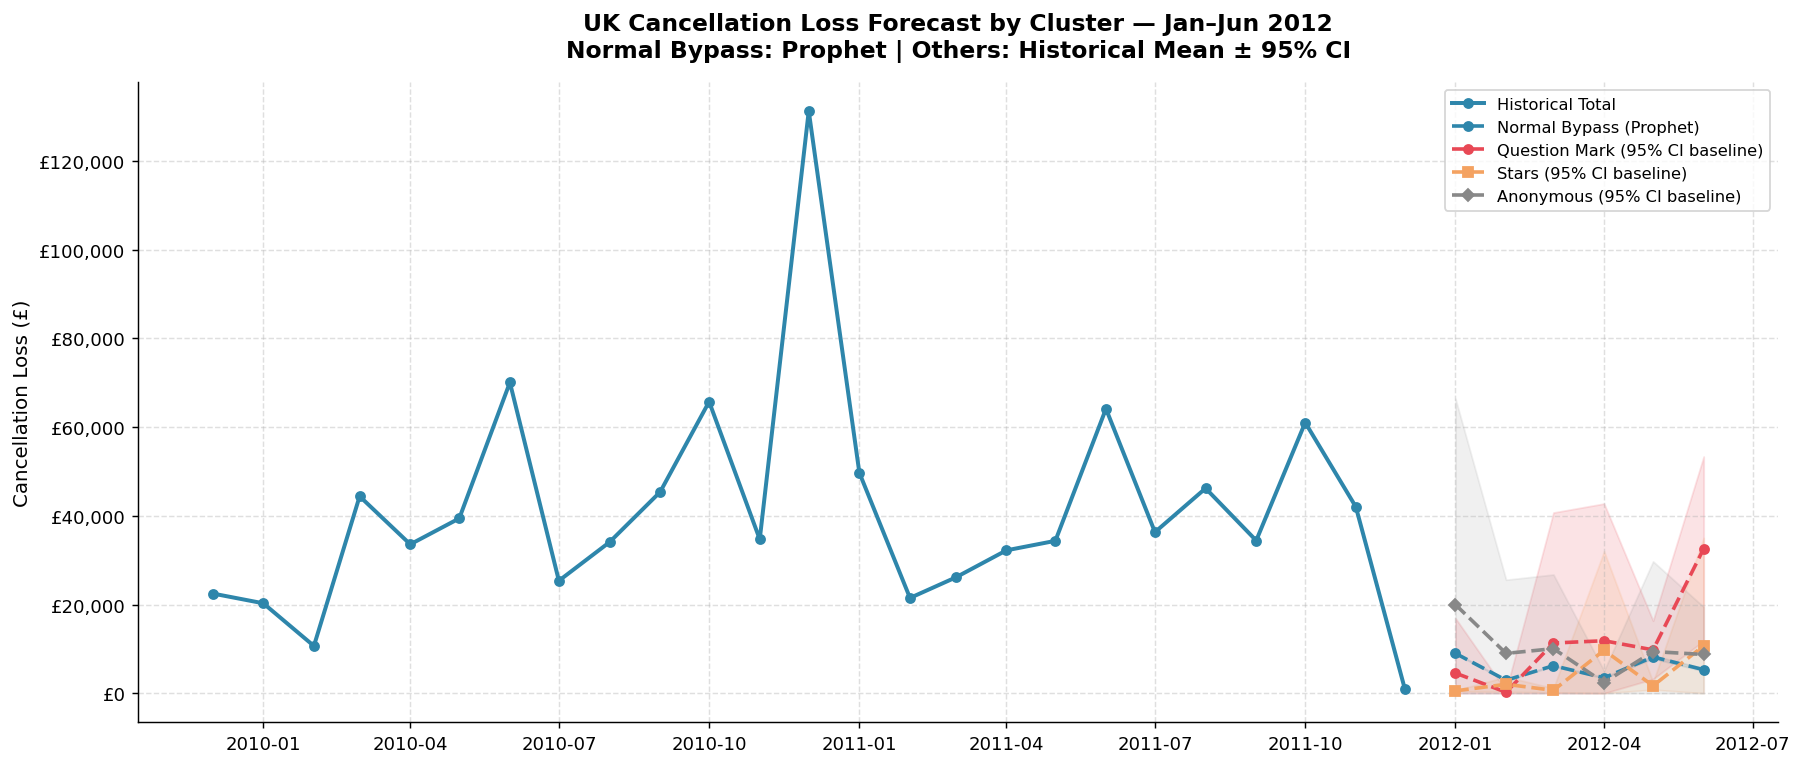

In [47]:
# ─────────────────────────────────────────────────────────────────────────────
# 5.2 Cancellation Forecast by Cluster — UK
# Normal Bypass  : Prophet monthly forecast
# Question Mark  : Historical mean ± 1.96 std per month (95% CI)
# Stars          : Historical mean ± 1.96 std per month (95% CI)
# Anonymous      : NaN Customer ID — Historical mean ± 1.96 std (95% CI)
# The Event      : Excluded — single one-off event Jan 2011
# ─────────────────────────────────────────────────────────────────────────────

# ── Step 1: Build monthly cancellation series per cluster ─────────────────────
uk_cancel_clustered = (df_top6_cancelled[
    df_top6_cancelled['Country'] == 'United Kingdom'].copy())

uk_cancel_clustered = uk_cancel_clustered.merge(
    uk_complete[[cid_col, 'Cluster_Name']],
    on=cid_col, how='left'
)
uk_cancel_clustered['Cluster_Name'] = uk_cancel_clustered['Cluster_Name'].fillna('Anonymous')
uk_cancel_clustered['Month'] = uk_cancel_clustered['InvoiceDate'].dt.to_period('M').dt.to_timestamp()

cluster_monthly = (uk_cancel_clustered
                   .groupby(['Cluster_Name', 'Month'])['Loss']
                   .sum()
                   .reset_index()
                   .rename(columns={'Loss': 'CancelLoss'}))

print('Monthly cancellation loss per cluster:')
print(cluster_monthly.groupby('Cluster_Name')['CancelLoss']
      .agg(['count', 'sum', 'mean', 'std']).round(2).to_string())
print()

# ── Step 2: Plot historical series per cluster ────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(13, 16), sharex=True)
cluster_colors = {
    'Normal Bypass': C_BLUE,
    'Question Mark': C_RED,
    'Stars'        : C_ORANGE,
    'Anonymous'    : '#888888'
}

for ax, cluster in zip(axes, ['Normal Bypass', 'Question Mark', 'Stars', 'Anonymous']):
    data = cluster_monthly[cluster_monthly['Cluster_Name'] == cluster]
    ax.plot(data['Month'], data['CancelLoss'],
            color=cluster_colors[cluster], linewidth=2, marker='o', markersize=4)
    ax.fill_between(data['Month'], data['CancelLoss'],
                    alpha=0.15, color=cluster_colors[cluster])
    ax.set_title(f'{cluster} — Monthly Cancellation Loss', pad=8)
    ax.set_ylabel('£')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
    ax.grid(linestyle='--', alpha=0.4)

plt.suptitle('UK Cluster Monthly Cancellation Loss — Historical Series\nDec 2009 – Dec 2011',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('forecast_cluster_historical.png', bbox_inches='tight')
plt.show()

# ── Step 3: Prophet forecast — Normal Bypass only ─────────────────────────────
nb_monthly = (cluster_monthly[cluster_monthly['Cluster_Name'] == 'Normal Bypass']
              .sort_values('Month').reset_index(drop=True))

TRAIN_SIZE_NB = 20
nb_train      = nb_monthly.iloc[:TRAIN_SIZE_NB].copy()
nb_test       = nb_monthly.iloc[TRAIN_SIZE_NB:].copy()
nb_test_clean = nb_test[nb_test['Month'] < '2011-12-01'].copy()

prophet_nb = Prophet(
    seasonality_mode ='multiplicative',
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality =False,
    interval_width    =0.95
)
prophet_nb.fit(nb_train.rename(columns={'Month': 'ds', 'CancelLoss': 'y'}))

future_nb   = prophet_nb.make_future_dataframe(periods=len(nb_test) + 6, freq='MS')
forecast_nb = prophet_nb.predict(future_nb)

nb_test_pred = forecast_nb[
    forecast_nb['ds'].isin(nb_test_clean['Month'])]['yhat'].values
nb_mae  = mean_absolute_error(nb_test_clean['CancelLoss'], nb_test_pred)
nb_rmse = mean_squared_error(nb_test_clean['CancelLoss'], nb_test_pred) ** 0.5

nb_future = forecast_nb[
    forecast_nb['ds'] > nb_monthly['Month'].max()
][['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head(6)
nb_future         = nb_future.rename(columns={'ds': 'Month'})
nb_future['yhat'] = nb_future['yhat'].clip(lower=0)

print(f'Normal Bypass — Prophet MAE  : £{nb_mae:,.2f}')
print(f'Normal Bypass — Prophet RMSE : £{nb_rmse:,.2f}')
print()
print('Normal Bypass 6-Month Forecast:')
print(nb_future.to_string(index=False))
print()

# ── Step 4: Baseline forecast function — Mean ± 95% CI ───────────────────────
def baseline_forecast_from_data(data, future_months):
    data             = data.copy()
    data['month_num'] = data['Month'].dt.month
    month_stats = (data.groupby('month_num')['CancelLoss']
                   .agg(['mean', 'std'])
                   .reset_index())
    month_stats['std'] = month_stats['std'].fillna(0)
    rows = []
    for dt in future_months:
        m     = dt.month
        stats = month_stats[month_stats['month_num'] == m]
        if len(stats) > 0:
            mean = stats['mean'].values[0]
            std  = stats['std'].values[0]
        else:
            mean = data['CancelLoss'].mean()
            std  = data['CancelLoss'].std()
        rows.append({
            'Month'     : dt,
            'yhat'      : round(mean, 2),
            'yhat_lower': round(max(mean - 1.96 * std, 0), 2),
            'yhat_upper': round(mean + 1.96 * std, 2)
        })
    return pd.DataFrame(rows)

future_months = pd.date_range(
    start=nb_monthly['Month'].max() + pd.DateOffset(months=1),
    periods=6, freq='MS'
)

# ── Step 5: Baseline forecasts — Question Mark, Stars, Anonymous ──────────────
def get_cluster_monthly(cluster_name):
    return (cluster_monthly[cluster_monthly['Cluster_Name'] == cluster_name]
            .sort_values('Month').reset_index(drop=True))

qm_future    = baseline_forecast_from_data(get_cluster_monthly('Question Mark'), future_months)
stars_future = baseline_forecast_from_data(get_cluster_monthly('Stars'),         future_months)
anon_future  = baseline_forecast_from_data(get_cluster_monthly('Anonymous'),     future_months)

print('Question Mark — 6-Month Baseline Forecast (Mean ± 95% CI):')
print(qm_future.to_string(index=False))
print()
print('Stars — 6-Month Baseline Forecast (Mean ± 95% CI):')
print(stars_future.to_string(index=False))
print()
print('Anonymous — 6-Month Baseline Forecast (Mean ± 95% CI):')
print(anon_future.to_string(index=False))
print()

# ── Step 6: Combined forecast table ──────────────────────────────────────────
combined_forecast = pd.DataFrame({
    'Month'                     : nb_future['Month'].dt.strftime('%b %Y').values,
    'Normal_Bypass_Forecast (£)': nb_future['yhat'].round(2).values,
    'NB_Lower (£)'              : nb_future['yhat_lower'].round(2).values,
    'NB_Upper (£)'              : nb_future['yhat_upper'].round(2).values,
    'Question_Mark_Mean (£)'    : qm_future['yhat'].values,
    'QM_Lower (£)'              : qm_future['yhat_lower'].values,
    'QM_Upper (£)'              : qm_future['yhat_upper'].values,
    'Stars_Mean (£)'            : stars_future['yhat'].values,
    'Stars_Lower (£)'           : stars_future['yhat_lower'].values,
    'Stars_Upper (£)'           : stars_future['yhat_upper'].values,
    'Anonymous_Mean (£)'        : anon_future['yhat'].values,
    'Anon_Lower (£)'            : anon_future['yhat_lower'].values,
    'Anon_Upper (£)'            : anon_future['yhat_upper'].values,
})

combined_forecast['Total_Expected (£)'] = (
    combined_forecast['Normal_Bypass_Forecast (£)'] +
    combined_forecast['Question_Mark_Mean (£)']     +
    combined_forecast['Stars_Mean (£)']             +
    combined_forecast['Anonymous_Mean (£)']
).round(2)

print('Combined Cluster Forecast — Jan–Jun 2012')
print('=' * 65)
print('Table A — Point Estimates:')
print(combined_forecast[['Month',
                          'Normal_Bypass_Forecast (£)',
                          'Question_Mark_Mean (£)',
                          'Stars_Mean (£)',
                          'Anonymous_Mean (£)',
                          'Total_Expected (£)']].to_string(index=False))
print()
print('Table B — Confidence Intervals:')
print(combined_forecast[['Month',
                          'NB_Lower (£)',    'NB_Upper (£)',
                          'QM_Lower (£)',    'QM_Upper (£)',
                          'Stars_Lower (£)', 'Stars_Upper (£)',
                          'Anon_Lower (£)',  'Anon_Upper (£)']].to_string(index=False))
print()
print('Note: Anonymous = cancellations with no Customer ID — not assignable to any cluster.')
print('Note: The Event (Customer 12346) excluded — single one-off bulk B2B event Jan 2011.')

# ── Step 7: Plot combined forecast ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

uk_cancel_total = (cluster_monthly[
    cluster_monthly['Cluster_Name'].isin(
        ['Normal Bypass', 'Question Mark', 'Stars', 'Anonymous'])]
    .groupby('Month')['CancelLoss'].sum().reset_index())

ax.plot(uk_cancel_total['Month'], uk_cancel_total['CancelLoss'],
        color=C_BLUE, linewidth=2.2, marker='o', markersize=5, label='Historical Total')

ax.plot(nb_future['Month'], nb_future['yhat'],
        color=C_BLUE, linewidth=2, linestyle='--', marker='o',
        markersize=5, label='Normal Bypass (Prophet)')
ax.fill_between(nb_future['Month'],
                nb_future['yhat_lower'], nb_future['yhat_upper'],
                alpha=0.15, color=C_BLUE)

ax.plot(pd.to_datetime(qm_future['Month']), qm_future['yhat'],
        color=C_RED, linewidth=2, linestyle='--', marker='o',
        markersize=5, label='Question Mark (95% CI baseline)')
ax.fill_between(pd.to_datetime(qm_future['Month']),
                qm_future['yhat_lower'], qm_future['yhat_upper'],
                alpha=0.15, color=C_RED)

ax.plot(pd.to_datetime(stars_future['Month']), stars_future['yhat'],
        color=C_ORANGE, linewidth=2, linestyle='--', marker='s',
        markersize=5, label='Stars (95% CI baseline)')
ax.fill_between(pd.to_datetime(stars_future['Month']),
                stars_future['yhat_lower'], stars_future['yhat_upper'],
                alpha=0.15, color=C_ORANGE)

ax.plot(pd.to_datetime(anon_future['Month']), anon_future['yhat'],
        color='#888888', linewidth=2, linestyle='--', marker='D',
        markersize=5, label='Anonymous (95% CI baseline)')
ax.fill_between(pd.to_datetime(anon_future['Month']),
                anon_future['yhat_lower'], anon_future['yhat_upper'],
                alpha=0.12, color='#888888')

ax.set_title('UK Cancellation Loss Forecast by Cluster — Jan–Jun 2012\n'
             'Normal Bypass: Prophet | Others: Historical Mean ± 95% CI',
             pad=14)
ax.set_ylabel('Cancellation Loss (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend(fontsize=9)
ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('forecast_cluster_combined.png', bbox_inches='tight')
plt.show()

#### Cancellation Forecast Insights 

***Normal Bypass — stable and predictable***

Prophet reports consistent cancellation patterns. February has the lowest cancellations (£2,931), while January and May are the highest (£8,995 and £8,188). Current operational policies are adequate, and no escalation is required.

***June is the critical month***

Total cancellations are expected to reach £ 57,366, nearly double any other month. Question Mark accounts for £32,606 of this amount in June. Allocate account management resources in May to proactively engage the eight affected accounts before cancellations occur.

***January needs operational readiness***

£34,065 in cancellations is expected, making January the second-highest month. This is primarily due to Anonymous (£19,982), which cannot be managed at the account level. The recommended response is operational: ensure sufficient returns processing capacity is available before January.

***Anonymous is a business gap***

£383,000 in cancellations lack Customer ID, preventing intervention in 37% of UK cancellation volume. Consistently capturing Customer ID for all transactions would allow these accounts to be managed effectively.

## 3. Projected Cancellation Rate — Gross Sales vs. Cancellations

Projected Cancellation Rate — Jan–Jun 2012:
     Month  Sales_Forecast  Total_Expected (£)  Cancel_Rate_Pct
2012-01-01      575,837.05           34,065.43             5.92
2012-02-01      386,473.45           14,156.70             3.66
2012-03-01      835,924.96           28,253.29             3.38
2012-04-01      678,588.95           27,422.49             4.04
2012-05-01      319,604.14           29,053.07             9.09
2012-06-01      572,667.16           57,366.32            10.02



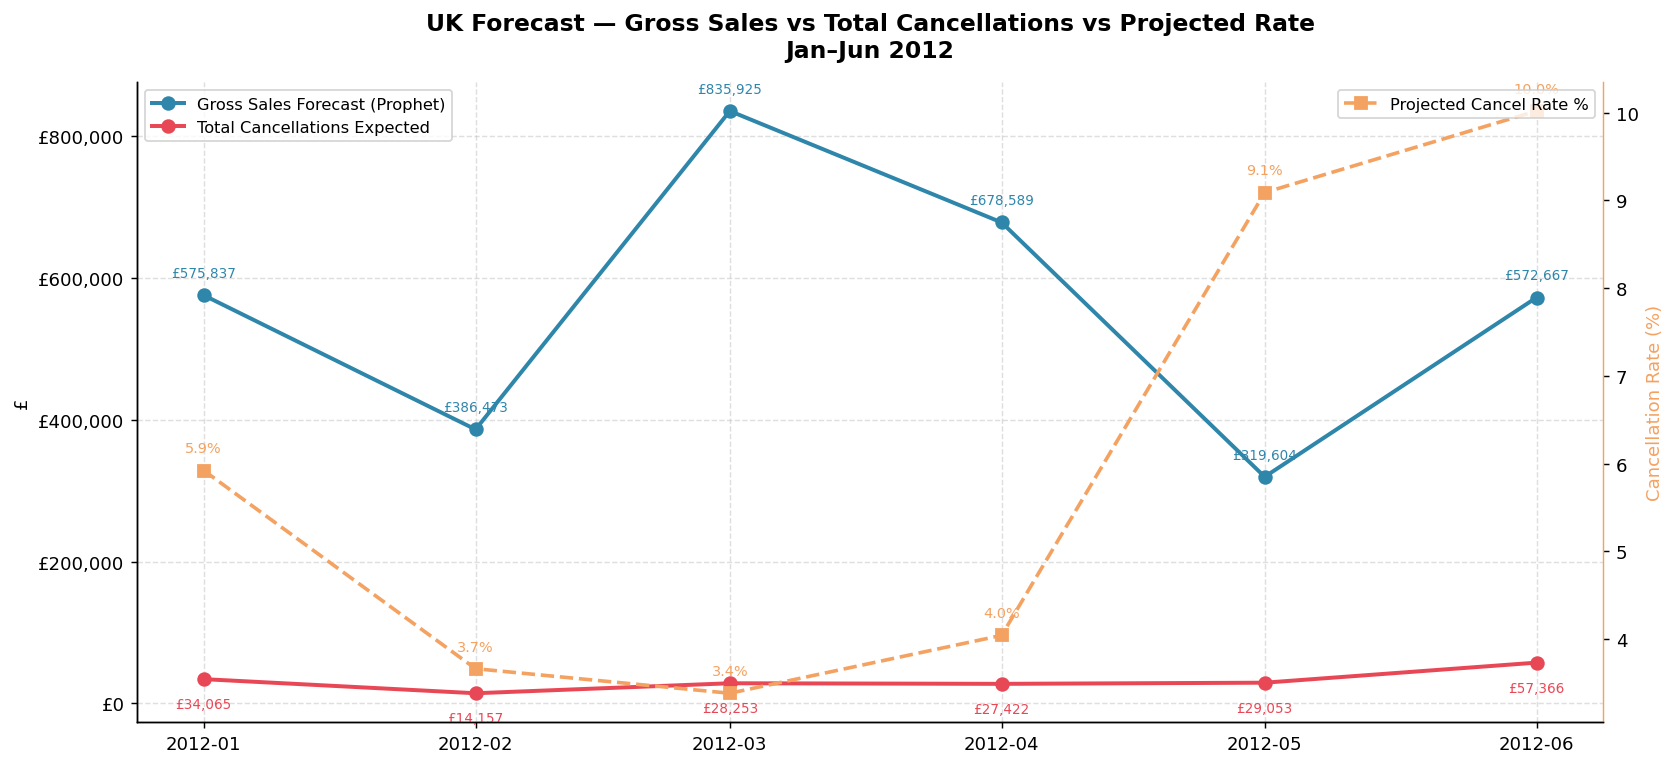

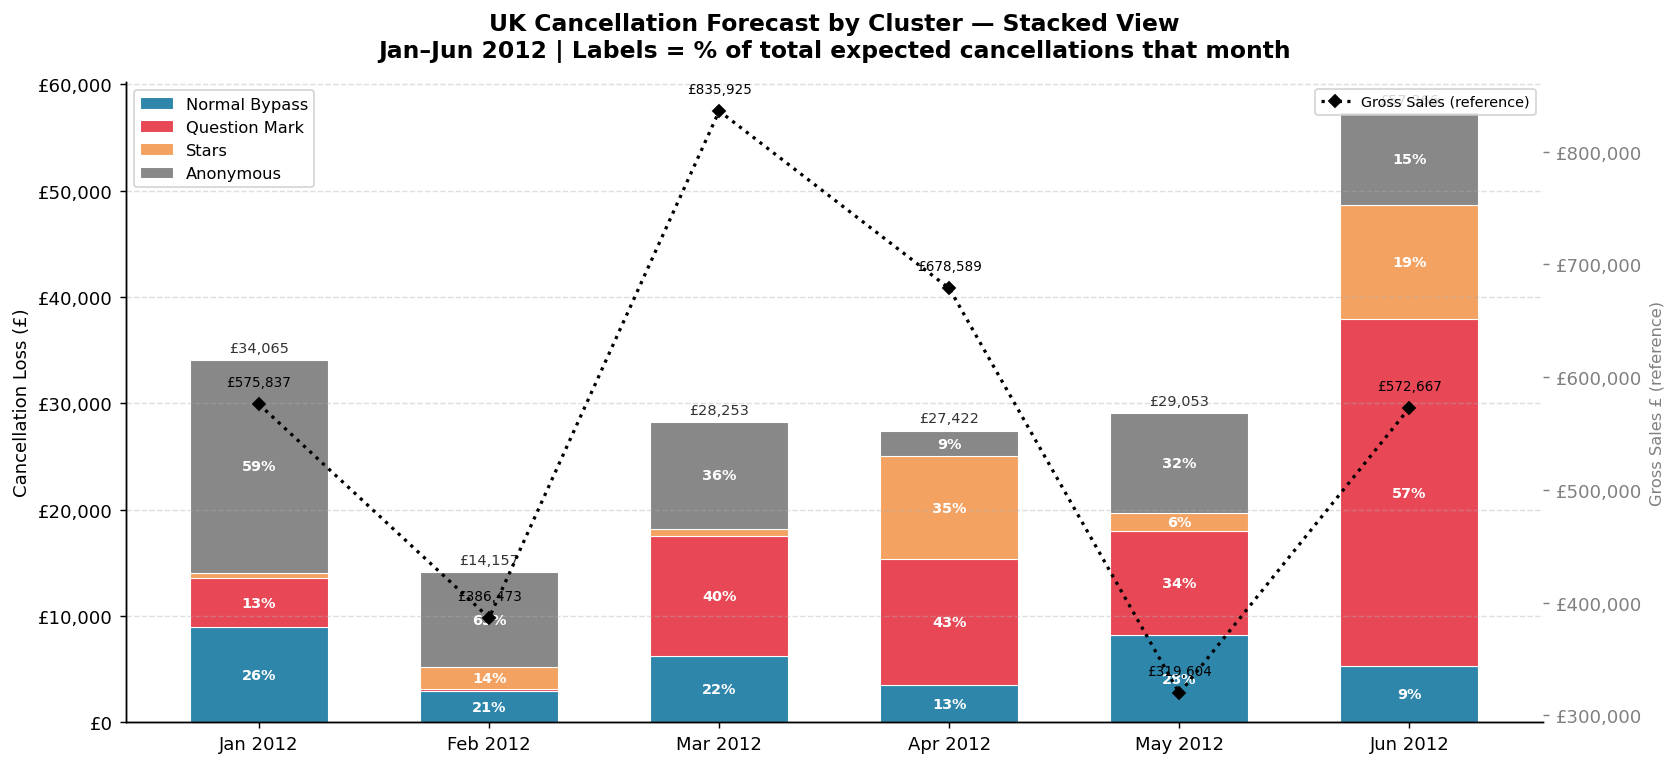

In [48]:
# ─────────────────────────────────────────────────────────────────────────────
# 5.3 Projected Cancellation Rate — Gross Sales vs Cancellations
# Chart 1: Aggregated — Sales forecast vs Total cancellations vs Rate %
# Chart 2: By cluster — Cancellation lines with % share labels
# ─────────────────────────────────────────────────────────────────────────────

# ── Prepare data ──────────────────────────────────────────────────────────────
# Prophet gross sales forecast (from 5.1)
sales_forecast = prophet_future[['ds', 'yhat']].copy()
sales_forecast.columns = ['Month', 'Sales_Forecast']
sales_forecast['Month'] = pd.to_datetime(sales_forecast['Month'])

# Total cancellations forecast (from 5.2)
cancel_total = combined_forecast[['Month',
                                   'Normal_Bypass_Forecast (£)',
                                   'Question_Mark_Mean (£)',
                                   'Stars_Mean (£)',
                                   'Anonymous_Mean (£)',
                                   'Total_Expected (£)']].copy()
cancel_total['Month'] = pd.to_datetime(
    cancel_total['Month'], format='%b %Y')

# Merge
rate_df = sales_forecast.merge(cancel_total, on='Month', how='inner')
rate_df['Cancel_Rate_Pct'] = (
    rate_df['Total_Expected (£)'] /
    rate_df['Sales_Forecast'] * 100
).round(2)

print('Projected Cancellation Rate — Jan–Jun 2012:')
print(rate_df[['Month', 'Sales_Forecast',
               'Total_Expected (£)',
               'Cancel_Rate_Pct']].to_string(index=False))
print()

# ── Chart 1 — Aggregated ──────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(13, 6))

ax1.plot(rate_df['Month'], rate_df['Sales_Forecast'],
         color=C_BLUE, linewidth=2.2, marker='o', markersize=7,
         label='Gross Sales Forecast (Prophet)')
ax1.plot(rate_df['Month'], rate_df['Total_Expected (£)'],
         color=C_RED, linewidth=2.2, marker='o', markersize=7,
         label='Total Cancellations Expected')

for _, row in rate_df.iterrows():
    ax1.annotate(f'£{row["Sales_Forecast"]:,.0f}',
                 (row['Month'], row['Sales_Forecast']),
                 textcoords='offset points', xytext=(0, 10),
                 ha='center', fontsize=7.5, color=C_BLUE)
    ax1.annotate(f'£{row["Total_Expected (£)"]:,.0f}',
                 (row['Month'], row['Total_Expected (£)']),
                 textcoords='offset points', xytext=(0, -16),
                 ha='center', fontsize=7.5, color=C_RED)

ax1.set_ylabel('£', fontsize=10)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax1.grid(linestyle='--', alpha=0.4)
ax1.legend(loc='upper left', fontsize=9)

ax2 = ax1.twinx()
ax2.plot(rate_df['Month'], rate_df['Cancel_Rate_Pct'],
         color=C_ORANGE, linewidth=2, linestyle='--',
         marker='s', markersize=7, label='Projected Cancel Rate %')
for _, row in rate_df.iterrows():
    ax2.annotate(f'{row["Cancel_Rate_Pct"]:.1f}%',
                 (row['Month'], row['Cancel_Rate_Pct']),
                 textcoords='offset points', xytext=(0, 10),
                 ha='center', fontsize=8, color=C_ORANGE)
ax2.set_ylabel('Cancellation Rate (%)', color=C_ORANGE, fontsize=10)
ax2.spines['right'].set_visible(True)
ax2.spines['right'].set_color(C_ORANGE)
ax2.legend(loc='upper right', fontsize=9)

ax1.set_title('UK Forecast — Gross Sales vs Total Cancellations vs Projected Rate\n'
              'Jan–Jun 2012', pad=14)
plt.tight_layout()
plt.savefig('forecast_5_3_aggregated.png', bbox_inches='tight')
plt.show()

# ── Chart 2 — By cluster with % share labels ──────────────────────────────────
# ── Chart 2 — By cluster — Stacked bars with % share labels ──────────────────
fig, ax = plt.subplots(figsize=(13, 6))

months_str = rate_df['Month'].dt.strftime('%b %Y').values
x          = range(len(months_str))

cluster_cols_ordered = [
    ('Normal Bypass', 'Normal_Bypass_Forecast (£)', C_BLUE),
    ('Question Mark', 'Question_Mark_Mean (£)',      C_RED),
    ('Stars',         'Stars_Mean (£)',              C_ORANGE),
    ('Anonymous',     'Anonymous_Mean (£)',          '#888888')
]

bottoms = np.zeros(len(rate_df))

for cluster_name, col, color in cluster_cols_ordered:
    values = rate_df[col].values
    bars   = ax.bar(x, values, bottom=bottoms,
                    color=color, edgecolor='white',
                    linewidth=0.6, label=cluster_name, width=0.6)

    # % share label on each bar segment
    for i, (val, bot, total) in enumerate(zip(
            values, bottoms, rate_df['Total_Expected (£)'].values)):
        pct = val / total * 100
        if pct > 5:  # only label if segment is large enough to read
            ax.text(i, bot + val / 2, f'{pct:.0f}%',
                    ha='center', va='center',
                    fontsize=8, fontweight='bold', color='white')
    bottoms += values

# Total label on top of each bar
for i, (total, bot) in enumerate(zip(
        rate_df['Total_Expected (£)'].values, bottoms)):
    ax.text(i, bot + 500, f'£{total:,.0f}',
            ha='center', va='bottom', fontsize=8, color='#333')

# Gross sales reference line (secondary axis)
ax2 = ax.twinx()
ax2.plot(x, rate_df['Sales_Forecast'].values,
         color='black', linewidth=1.8, linestyle=':',
         marker='D', markersize=5, label='Gross Sales (reference)')
for i, val in enumerate(rate_df['Sales_Forecast'].values):
    ax2.annotate(f'£{val:,.0f}', (i, val),
                 textcoords='offset points', xytext=(0, 10),
                 ha='center', fontsize=7.5, color='black')
ax2.set_ylabel('Gross Sales £ (reference)', fontsize=9, color='grey')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax2.spines['right'].set_color('grey')
ax2.tick_params(axis='y', colors='grey')
ax2.legend(loc='upper right', fontsize=8)

ax.set_xticks(list(x))
ax.set_xticklabels(months_str, fontsize=10)
ax.set_ylabel('Cancellation Loss (£)', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend(loc='upper left', fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_title('UK Cancellation Forecast by Cluster — Stacked View\n'
             'Jan–Jun 2012 | Labels = % of total expected cancellations that month',
             pad=14)
plt.tight_layout()
plt.savefig('forecast_5_3_by_cluster.png', bbox_inches='tight')
plt.show()

## 4. Recommendations for Resource Allocation:

**January — 5.92% | £34,065**

Anonymous cancellations account for 59%. You can't manage these at the account level because the business cannot identify the customers. Allocate returns-processing resources accordingly, and prioritize capturing Customer ID at the point of sale through mandatory login or staff-assisted identification. Converting anonymous transactions into identified ones will permanently reduce this blind spot.

**February — 3.66% | £14,157**

This month has the lowest cancellation rate and volume in the forecast. Reduce operational resources accordingly. Use this period for internal reviews, staff training, and system preparation ahead of higher-risk months.

**March — 3.38% | £28,253**

Gross sales reach £835,925, with the lowest cancellation rate. The sales increase is stable. Prioritize fulfillment and logistics capacity to support peak volume. Question Mark accounts represent 40% of cancellations, but the absolute amount is manageable. Monitor this segment, but escalation is not yet required.

**April — 4.04% | £27,422**

Stars account for 35% of cancellations, becoming the dominant group. These are the most valuable accounts in the dataset. Initiate proactive account management outreach in March, before April cancellations, to identify and resolve any fulfillment or quality issues early.

**May — 9.09% | £29,053**

This is the most concerning month proportionally. Sales decrease to £319,604, but cancellations remain high, with the rate rising to 9.09%. Cancellations are distributed across Normal Bypass, Question Mark, and Anonymous, with no single cluster dominating. Maintain full returns processing capacity despite lower sales. This indicates an underlying stressed market. 

**June — 10.02% | £57,366**

June presents the highest risk across all dimensions. Question Mark rises to 57% of total cancellations, likely due to wholesale seasonal validation. Stars account for 19%. Begin account management engagement with Question Mark and Stars in May, one month in advance, to pre-empt cancellations through commercial negotiation or delivery guarantees. Returns processing capacity should be maximized.



---
# Section 6: ML Cancellation Prediction — United Kingdom
## 1. ML Implementation 
---

In [49]:
# ─────────────────────────────────────────────────────────────────────────────
# 6.1 Year Split Diagnostic — Customer survival per cluster
# Year 1: Dec 2009 – Nov 2010 (features)
# Year 2: Dec 2010 – Nov 2011 (target)
# ─────────────────────────────────────────────────────────────────────────────

YEAR1_START = '2009-12-01'
YEAR1_END   = '2010-11-30'
YEAR2_START = '2010-12-01'
YEAR2_END   = '2011-11-30'

# ── Active customers per year — UK only ───────────────────────────────────────
y1_customers = set(df[
    (df['Country'] == 'United Kingdom') &
    (df['InvoiceDate'] >= YEAR1_START) &
    (df['InvoiceDate'] <= YEAR1_END)
][cid_col].dropna().unique())

y2_customers = set(df[
    (df['Country'] == 'United Kingdom') &
    (df['InvoiceDate'] >= YEAR2_START) &
    (df['InvoiceDate'] <= YEAR2_END)
][cid_col].dropna().unique())

both_years = y1_customers & y2_customers

print(f'Year 1 customers (Dec 09 – Nov 10) : {len(y1_customers):,}')
print(f'Year 2 customers (Dec 10 – Nov 11) : {len(y2_customers):,}')
print(f'Active in both years               : {len(both_years):,}')
print(f'Year 1 only — churned              : {len(y1_customers - y2_customers):,}')
print(f'Year 2 only — new                  : {len(y2_customers - y1_customers):,}')
print()

# ── Survival per cluster ──────────────────────────────────────────────────────
print('Cluster Survival After Year Split:')
print('─' * 55)

clusters_to_check = {
    'Normal Bypass': rfmr_uk_core[rfmr_uk_core['Cluster_Name'] == 'Normal Bypass'][cid_col].values,
    'Question Mark': rfmr_uk_core[rfmr_uk_core['Cluster_Name'] == 'Question Mark'][cid_col].values,
    'Stars'        : rfmr_uk_core[rfmr_uk_core['Cluster_Name'] == 'Stars'][cid_col].values,
    'The Event'    : outlier_row[cid_col].values
}

for cluster_name, customers in clusters_to_check.items():
    cluster_set = set(customers)
    survived    = cluster_set & both_years
    dropped     = cluster_set - both_years
    total       = len(cluster_set)
    surv_pct    = len(survived) / total * 100 if total > 0 else 0

    print(f'{cluster_name}:')
    print(f'  Total customers : {total}')
    print(f'  Survived        : {len(survived)} ({surv_pct:.0f}%)')
    print(f'  Dropped         : {len(dropped)} ({100-surv_pct:.0f}%)')
    if len(survived) > 0 and len(survived) <= 10:
        survived_ids = [f'Customer {int(c)}' for c in survived]
        print(f'  Who survived    : {", ".join(survived_ids)}')
    print()

Year 1 customers (Dec 09 – Nov 10) : 3,986
Year 2 customers (Dec 10 – Nov 11) : 3,910
Active in both years               : 2,515
Year 1 only — churned              : 1,471
Year 2 only — new                  : 1,395

Cluster Survival After Year Split:
───────────────────────────────────────────────────────
Normal Bypass:
  Total customers : 2259
  Survived        : 1516 (67%)
  Dropped         : 743 (33%)

Question Mark:
  Total customers : 8
  Survived        : 3 (38%)
  Dropped         : 5 (62%)
  Who survived    : Customer 12931, Customer 17949, Customer 16029

Stars:
  Total customers : 24
  Survived        : 17 (71%)
  Dropped         : 7 (29%)

The Event:
  Total customers : 1
  Survived        : 1 (100%)
  Dropped         : 0 (0%)
  Who survived    : Customer 12346



In [50]:
# ─────────────────────────────────────────────────────────────────────────────
# 6.2 Feature Engineering — Year 1 features → Year 2 target
# Year 1: Dec 2009 – Nov 2010 | Year 2: Dec 2010 – Nov 2011
# ─────────────────────────────────────────────────────────────────────────────

# ── Year 1 features ───────────────────────────────────────────────────────────
Y1_END = pd.Timestamp('2010-11-30')
Y2_END = pd.Timestamp('2011-11-30')

df_uk = df[df['Country'] == 'United Kingdom'].copy()

# R_Recency Y1 — days since last cancellation in Year 1
r_y1 = (df_uk[(df_uk['Cancelled']) &
              (df_uk['InvoiceDate'] <= Y1_END)]
        .groupby(cid_col)['InvoiceDate']
        .max()
        .reset_index()
        .rename(columns={'InvoiceDate': 'LastCancel_Y1'}))
r_y1['R_Recency_Y1'] = (Y1_END - r_y1['LastCancel_Y1']).dt.days

# R_PurchaseRecency Y1 — days since last purchase in Year 1
rp_y1 = (df_uk[(df_uk['Is_Return'] == False) &
               (df_uk['InvoiceDate'] <= Y1_END)]
         .groupby(cid_col)['InvoiceDate']
         .max()
         .reset_index()
         .rename(columns={'InvoiceDate': 'LastPurchase_Y1'}))
rp_y1['R_PurchaseRecency_Y1'] = (Y1_END - rp_y1['LastPurchase_Y1']).dt.days

# F_TotalOrders Y1 — unique purchase invoices in Year 1
f_y1 = (df_uk[(df_uk['Is_Return'] == False) &
              (df_uk['InvoiceDate'] <= Y1_END)]
        .groupby(cid_col)['Invoice']
        .nunique()
        .reset_index()
        .rename(columns={'Invoice': 'F_TotalOrders_Y1'}))

# M_GrossPurchases Y1 — total gross purchases in Year 1
m_y1 = (df_uk[(df_uk['Is_Return'] == False) &
              (df_uk['InvoiceDate'] <= Y1_END)]
        .assign(GrossValue=lambda x: x['Quantity'] * x['Price'])
        .groupby(cid_col)['GrossValue']
        .sum()
        .reset_index()
        .rename(columns={'GrossValue': 'M_GrossPurchases_Y1'}))

# Re_CancelLoss Y1 — total cancellation loss in Year 1
re_y1 = (df_uk[(df_uk['Cancelled']) &
               (df_uk['InvoiceDate'] <= Y1_END)]
         .groupby(cid_col)['Loss']
         .sum()
         .reset_index()
         .rename(columns={'Loss': 'Re_CancelLoss_Y1'}))

# ── Year 2 target ─────────────────────────────────────────────────────────────
re_y2 = (df_uk[(df_uk['Cancelled']) &
               (df_uk['InvoiceDate'] >  Y1_END) &
               (df_uk['InvoiceDate'] <= Y2_END)]
         .groupby(cid_col)['Loss']
         .sum()
         .reset_index()
         .rename(columns={'Loss': 'Re_CancelLoss_Y2'}))

# ── Merge all features ────────────────────────────────────────────────────────
model_df = (r_y1[[cid_col, 'R_Recency_Y1']]
            .merge(rp_y1[[cid_col, 'R_PurchaseRecency_Y1']], on=cid_col, how='left')
            .merge(f_y1,                                      on=cid_col, how='left')
            .merge(m_y1,                                      on=cid_col, how='left')
            .merge(re_y1,                                     on=cid_col, how='left')
            .merge(re_y2,                                     on=cid_col, how='left'))

# ── Keep only customers active in both years ──────────────────────────────────
model_df = model_df[model_df[cid_col].isin(both_years)].copy()

# ── Fill NaN ──────────────────────────────────────────────────────────────────
model_df['R_PurchaseRecency_Y1'] = model_df['R_PurchaseRecency_Y1'].fillna(
    model_df['R_Recency_Y1'])
model_df['F_TotalOrders_Y1']     = model_df['F_TotalOrders_Y1'].fillna(0)
model_df['M_GrossPurchases_Y1']  = model_df['M_GrossPurchases_Y1'].fillna(0)
model_df['Re_CancelLoss_Y1']     = model_df['Re_CancelLoss_Y1'].fillna(0)
model_df['Re_CancelLoss_Y2']     = model_df['Re_CancelLoss_Y2'].fillna(0)

# ── Add derived features ──────────────────────────────────────────────────────
model_df['Cancel_Rate_Y1'] = (
    model_df['Re_CancelLoss_Y1'] /
    model_df['M_GrossPurchases_Y1'].replace(0, float('nan'))
).fillna(0).round(4)

model_df['Avg_Order_Value_Y1'] = (
    model_df['M_GrossPurchases_Y1'] /
    model_df['F_TotalOrders_Y1'].replace(0, float('nan'))
).fillna(0).round(2)

# ── Add cluster labels ────────────────────────────────────────────────────────
cluster_map = pd.concat([
    rfmr_uk_core[[cid_col, 'Cluster_Name']],
    outlier_row[[cid_col, 'Cluster_Name']]
]).drop_duplicates()

model_df = model_df.merge(cluster_map, on=cid_col, how='left')
model_df['Cluster_Name'] = model_df['Cluster_Name'].fillna('Normal Bypass')

print(f'Total customers in model dataset : {len(model_df):,}')
print(f'Features                         : 7')
print(f'Target                           : Re_CancelLoss_Y2')
print()
print('Dataset stats:')
print(model_df[['R_Recency_Y1', 'R_PurchaseRecency_Y1', 'F_TotalOrders_Y1',
                'M_GrossPurchases_Y1', 'Re_CancelLoss_Y1',
                'Cancel_Rate_Y1', 'Avg_Order_Value_Y1',
                'Re_CancelLoss_Y2']].describe().round(2).to_string())
print()
print('Cluster distribution in model dataset:')
print(model_df['Cluster_Name'].value_counts().to_string())

Total customers in model dataset : 1,193
Features                         : 7
Target                           : Re_CancelLoss_Y2

Dataset stats:
       R_Recency_Y1  R_PurchaseRecency_Y1  F_TotalOrders_Y1  M_GrossPurchases_Y1  Re_CancelLoss_Y1  Cancel_Rate_Y1  Avg_Order_Value_Y1  Re_CancelLoss_Y2
count      1,193.00              1,193.00          1,193.00             1,193.00          1,193.00        1,193.00            1,193.00          1,193.00
mean         115.79                 47.55              8.36             4,059.65            159.20            0.05              425.43            196.72
std          102.33                 63.18             11.31            12,173.89            742.43            0.12              456.82          2,378.24
min            0.00                  0.00              0.00                 0.00              0.95            0.00                0.00              0.00
25%           27.00                  8.00              3.00               924.52         

In [51]:
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

Cluster encoding:
  Normal Bypass → 0
  Question Mark → 1
  Stars → 2
  The Event → 3

Training set : 954 customers
Test set     : 239 customers

XGBoost — MAE  : £117.30
XGBoost — RMSE : £600.49
XGBoost — R²   : 0.2055

Random Forest — MAE  : £120.15
Random Forest — RMSE : £654.72
Random Forest — R²   : 0.0555

Model Comparison — Test Set Performance (log transform + cluster label):
        Model  MAE (£)  RMSE (£)   R²  MAE vs RMSE gap (£) Winner
      XGBoost   117.30    600.49 0.21               483.19      ✓
Random Forest   120.15    654.72 0.06               534.58       

XGBoost Feature Importance:
             Feature  Importance
     Cluster_Encoded        0.46
 M_GrossPurchases_Y1        0.15
    F_TotalOrders_Y1        0.07
    Re_CancelLoss_Y1        0.07
      Cancel_Rate_Y1        0.06
  Avg_Order_Value_Y1        0.06
        R_Recency_Y1        0.06
R_PurchaseRecency_Y1        0.06

Random Forest Feature Importance:
             Feature  Importance
 M_GrossPurchases_Y1 

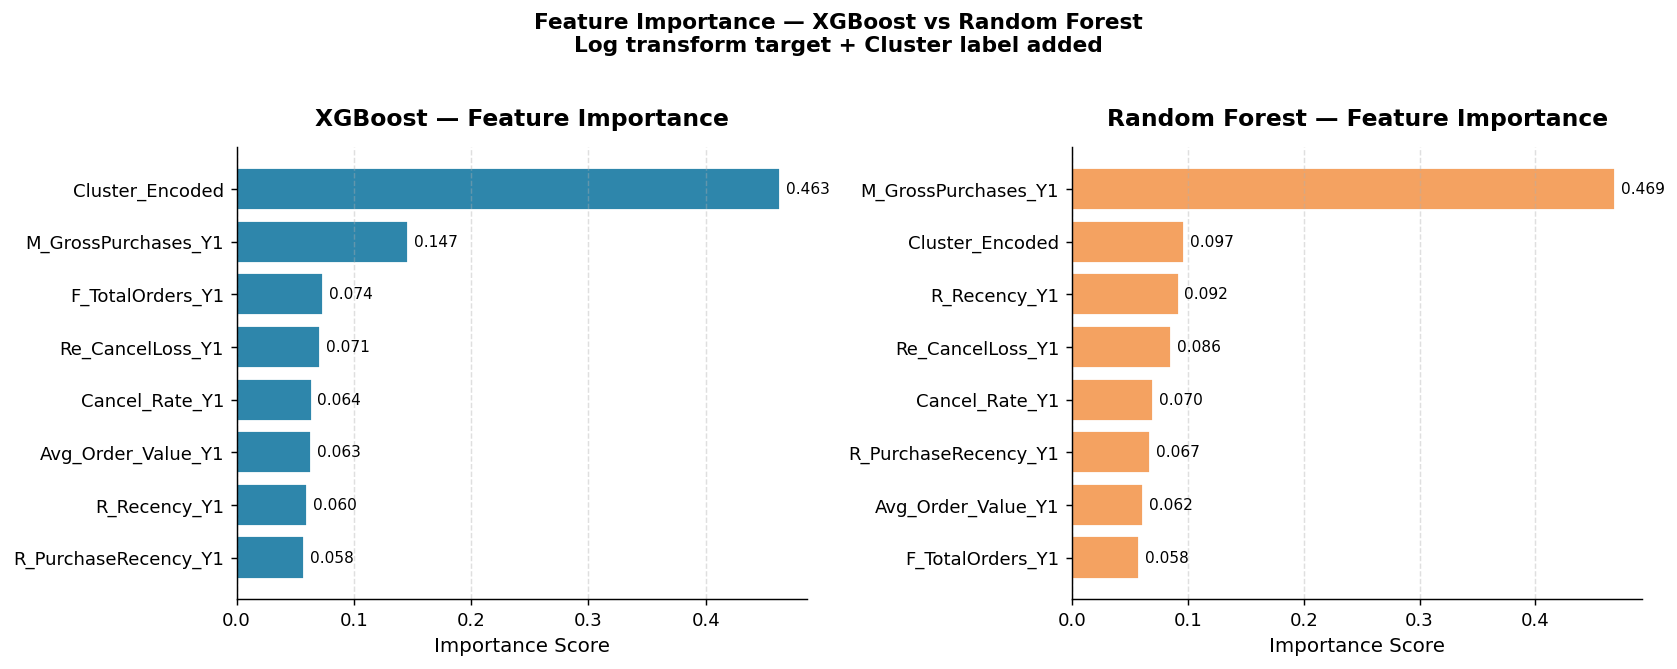

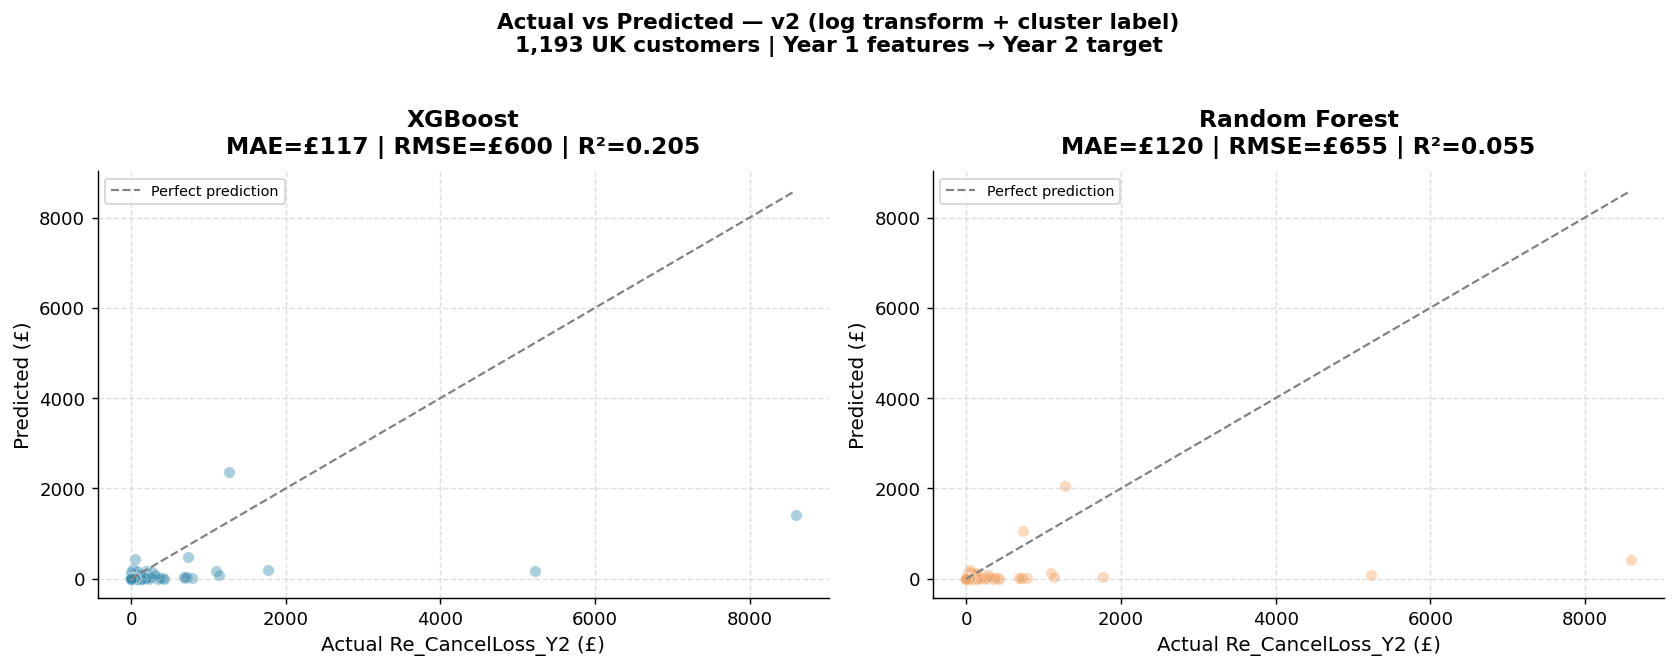

In [52]:
# ─────────────────────────────────────────────────────────────────────────────
# 6.3 Model Training v2 — Random Forest
# Fixes: log transform on target + cluster label as feature
# ─────────────────────────────────────────────────────────────────────────────

from xgboost                 import XGBRegressor
from sklearn.ensemble        import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics         import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing   import LabelEncoder
import numpy as np

# ── Encode cluster label ──────────────────────────────────────────────────────
le = LabelEncoder()
model_df['Cluster_Encoded'] = le.fit_transform(model_df['Cluster_Name'])

print('Cluster encoding:')
for name, code in zip(le.classes_, le.transform(le.classes_)):
    print(f'  {name} → {code}')
print()

FEATURES_V2 = ['R_Recency_Y1', 'R_PurchaseRecency_Y1', 'F_TotalOrders_Y1',
                'M_GrossPurchases_Y1', 'Re_CancelLoss_Y1',
                'Cancel_Rate_Y1', 'Avg_Order_Value_Y1',
                'Cluster_Encoded']
TARGET = 'Re_CancelLoss_Y2'

# ── Log transform target ──────────────────────────────────────────────────────
# log(y + 1) to handle zeros — exponentiate predictions back after
model_df['Target_Log'] = np.log1p(model_df[TARGET])

X = model_df[FEATURES_V2]
y = model_df['Target_Log']

# ── Train/test split ──────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

y_test_original = np.expm1(y_test)

print(f'Training set : {len(X_train):,} customers')
print(f'Test set     : {len(X_test):,} customers')
print()

# ── XGBoost ───────────────────────────────────────────────────────────────────
xgb_reg = XGBRegressor(
    n_estimators     = 300,
    learning_rate    = 0.05,
    max_depth        = 4,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    verbosity        = 0
)
xgb_reg.fit(X_train, y_train)
xgb_pred_log = xgb_reg.predict(X_test)
xgb_pred     = np.maximum(np.expm1(xgb_pred_log), 0)

xgb_mae  = mean_absolute_error(y_test_original, xgb_pred)
xgb_rmse = mean_squared_error(y_test_original, xgb_pred) ** 0.5
xgb_r2   = r2_score(y_test_original, xgb_pred)

print(f'XGBoost — MAE  : £{xgb_mae:,.2f}')
print(f'XGBoost — RMSE : £{xgb_rmse:,.2f}')
print(f'XGBoost — R²   : {xgb_r2:.4f}')
print()

# ── Random Forest ─────────────────────────────────────────────────────────────
rf_reg = RandomForestRegressor(
    n_estimators = 300,
    max_depth    = 6,
    random_state = 42,
    n_jobs       = -1
)
rf_reg.fit(X_train, y_train)
rf_pred_log = rf_reg.predict(X_test)
rf_pred     = np.maximum(np.expm1(rf_pred_log), 0)

rf_mae  = mean_absolute_error(y_test_original, rf_pred)
rf_rmse = mean_squared_error(y_test_original, rf_pred) ** 0.5
rf_r2   = r2_score(y_test_original, rf_pred)

print(f'Random Forest — MAE  : £{rf_mae:,.2f}')
print(f'Random Forest — RMSE : £{rf_rmse:,.2f}')
print(f'Random Forest — R²   : {rf_r2:.4f}')
print()

# ── Model comparison ──────────────────────────────────────────────────────────
print('Model Comparison — Test Set Performance (log transform + cluster label):')
print('=' * 65)
comparison = pd.DataFrame({
    'Model'              : ['XGBoost', 'Random Forest'],
    'MAE (£)'            : [xgb_mae,          rf_mae],
    'RMSE (£)'           : [xgb_rmse,         rf_rmse],
    'R²'                 : [xgb_r2,           rf_r2],
    'MAE vs RMSE gap (£)': [xgb_rmse - xgb_mae, rf_rmse - rf_mae]
}).round(4)
winner_idx = comparison['MAE (£)'].idxmin()
comparison['Winner'] = ''
comparison.loc[winner_idx, 'Winner'] = '✓'
print(comparison.to_string(index=False))
print()

# ── Feature importance ────────────────────────────────────────────────────────
xgb_importance = pd.DataFrame({
    'Feature'   : FEATURES_V2,
    'Importance': xgb_reg.feature_importances_
}).sort_values('Importance', ascending=False).round(4)

rf_importance = pd.DataFrame({
    'Feature'   : FEATURES_V2,
    'Importance': rf_reg.feature_importances_
}).sort_values('Importance', ascending=False).round(4)

print('XGBoost Feature Importance:')
print(xgb_importance.to_string(index=False))
print()
print('Random Forest Feature Importance:')
print(rf_importance.to_string(index=False))
print()

# ── Feature importance plot ───────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.barh(xgb_importance['Feature'][::-1],
         xgb_importance['Importance'][::-1],
         color=C_BLUE, edgecolor='white')
ax1.set_title('XGBoost — Feature Importance', pad=12)
ax1.set_xlabel('Importance Score')
ax1.grid(axis='x', linestyle='--', alpha=0.4)
for i, imp in enumerate(xgb_importance['Importance'][::-1]):
    ax1.text(imp + 0.005, i, f'{imp:.3f}', va='center', fontsize=8.5)

ax2.barh(rf_importance['Feature'][::-1],
         rf_importance['Importance'][::-1],
         color=C_ORANGE, edgecolor='white')
ax2.set_title('Random Forest — Feature Importance', pad=12)
ax2.set_xlabel('Importance Score')
ax2.grid(axis='x', linestyle='--', alpha=0.4)
for i, imp in enumerate(rf_importance['Importance'][::-1]):
    ax2.text(imp + 0.005, i, f'{imp:.3f}', va='center', fontsize=8.5)

plt.suptitle('Feature Importance — XGBoost vs Random Forest\n'
             'Log transform target + Cluster label added',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ml_feature_importance_v2.png', bbox_inches='tight')
plt.show()

# ── Actual vs Predicted plot ──────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for ax, pred, title, color, mae, rmse, r2 in zip(
    [ax1, ax2],
    [xgb_pred, rf_pred],
    ['XGBoost', 'Random Forest'],
    [C_BLUE, C_ORANGE],
    [xgb_mae, rf_mae],
    [xgb_rmse, rf_rmse],
    [xgb_r2, rf_r2]
):
    ax.scatter(y_test_original, pred, alpha=0.4, color=color,
               edgecolors='white', linewidths=0.4, s=40)
    max_val = max(y_test_original.max(), pred.max())
    ax.plot([0, max_val], [0, max_val], color='grey',
            linestyle='--', linewidth=1.2, label='Perfect prediction')
    ax.set_xlabel('Actual Re_CancelLoss_Y2 (£)')
    ax.set_ylabel('Predicted (£)')
    ax.set_title(f'{title}\nMAE=£{mae:,.0f} | RMSE=£{rmse:,.0f} | R²={r2:.3f}',
                 pad=10)
    ax.legend(fontsize=8)
    ax.grid(linestyle='--', alpha=0.4)

plt.suptitle('Actual vs Predicted — v2 (log transform + cluster label)\n'
             '1,193 UK customers | Year 1 features → Year 2 target',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ml_actual_vs_predicted_v2.png', bbox_inches='tight')
plt.show()

In [63]:
# ── Actual vs Predicted by cluster — v2 (log transform + cluster label) ───────
test_results = X_test.copy()
test_results['Actual']    = y_test_original.values
test_results['XGB_Pred']  = xgb_pred          # already exponentiated back in v2
test_results['RF_Pred']   = rf_pred           # already exponentiated back in v2
test_results['Cluster']   = model_df.loc[X_test.index, 'Cluster_Name'].values
test_results['Customer']  = model_df.loc[X_test.index, cid_col].apply(
    lambda x: f'Customer {int(x)}').values

print('Actual vs Predicted by Cluster — Test Set Sample (v2: log transform + cluster label)')
print('=' * 75)

for cluster in ['Normal Bypass', 'Stars', 'Question Mark', 'The Event']:
    subset = test_results[test_results['Cluster'] == cluster].copy()
    subset = subset.sort_values('Actual', ascending=False)

    print(f'\n{cluster} — {len(subset)} customers in test set')
    print('─' * 75)

    if len(subset) == 0:
        print('  No customers in test set for this cluster.')
        continue

    print(subset[['Customer', 'Actual', 'XGB_Pred', 'RF_Pred']]
          .head(10)
          .round(2)
          .to_string(index=False))

    if len(subset) >= 5:
        xgb_mae_c = mean_absolute_error(subset['Actual'], subset['XGB_Pred'])
        rf_mae_c  = mean_absolute_error(subset['Actual'], subset['RF_Pred'])
        xgb_r2_c  = r2_score(subset['Actual'], subset['XGB_Pred'])
        rf_r2_c   = r2_score(subset['Actual'], subset['RF_Pred'])
        print(f'\n  XGBoost MAE: £{xgb_mae_c:,.2f} | R²: {xgb_r2_c:.3f}')
        print(f'  RF      MAE: £{rf_mae_c:,.2f} | R²: {rf_r2_c:.3f}')
    elif len(subset) > 1:
        xgb_mae_c = mean_absolute_error(subset['Actual'], subset['XGB_Pred'])
        rf_mae_c  = mean_absolute_error(subset['Actual'], subset['RF_Pred'])
        print(f'\n  XGBoost MAE: £{xgb_mae_c:,.2f}')
        print(f'  RF      MAE: £{rf_mae_c:,.2f}')
        print(f'  Note: R² not reported — fewer than 5 customers in test set')
    print()

Actual vs Predicted by Cluster — Test Set Sample (v2: log transform + cluster label)

Normal Bypass — 235 customers in test set
───────────────────────────────────────────────────────────────────────────
      Customer   Actual  XGB_Pred  RF_Pred
Customer 16546 1,766.16    191.64    28.27
Customer 16525 1,131.88     86.22    41.99
Customer 13564 1,101.28    179.85   117.85
Customer 17809   784.29      7.43    13.39
Customer 13069   718.30     39.81    20.68
Customer 15674   702.58     12.74    11.83
Customer 14543   682.11     36.18    19.85
Customer 15197   419.40      2.29     3.64
Customer 15465   409.60      5.68     7.45
Customer 15100   372.30      6.57    13.38

  XGBoost MAE: £61.49 | R²: 0.052
  RF      MAE: £60.72 | R²: -0.028


Stars — 3 customers in test set
───────────────────────────────────────────────────────────────────────────
      Customer   Actual  XGB_Pred  RF_Pred
Customer 15502 5,228.87    172.34    77.07
Customer 15311 1,270.09  2,370.33 2,061.85
Customer 16684

Combined_Risk max after fix: 0.5222
Inf count after fix        : 0
Top 20 High Risk Accounts — Combined RFMR Score + ML Prediction:
 Risk_Rank       Customer  Cluster_Name  Re_CancelLoss_Y1  Cancel_Rate_Y1  R_Recency_Y1  Predicted_CancelLoss_6M  Risk_Score  Combined_Risk
         1 Customer 16013         Stars          4,482.80            0.08            21                 6,853.52        0.04           0.52
         2 Customer 15311         Stars          3,148.59            0.03             0                 1,398.90        0.32           0.26
         3 Customer 12346     The Event         77,620.14            1.00           315                    50.24        0.50           0.25
         4 Customer 17450         Stars         12,370.50            0.05             0                   732.08        0.37           0.24
         5 Customer 12748         Stars          6,214.38            0.11             0                   552.95        0.34           0.21
         6 Customer 16446 No

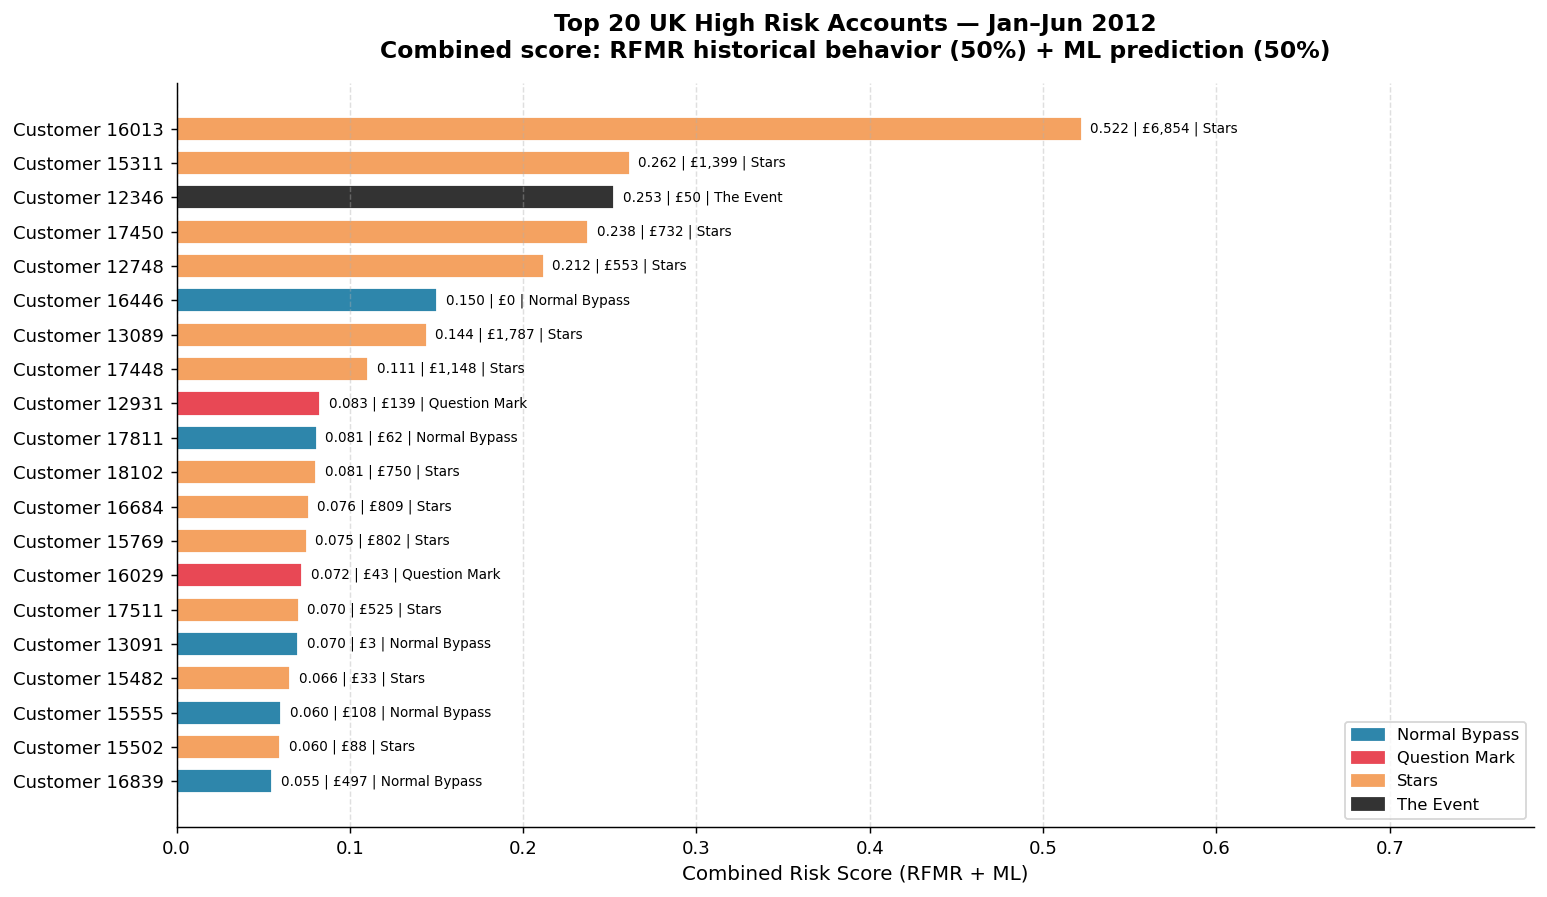

In [58]:
# ─────────────────────────────────────────────────────────────────────────────
# 6.4 Score All Customers — Predicted Cancellation Loss 2012
# Apply best model (XGBoost v2 — log transform + cluster label)
# Output: ranked list per customer with cluster label
# ─────────────────────────────────────────────────────────────────────────────

# ── Build full 2-year RFMR for all 1,193 customers ───────────────────────────
FULL_END = pd.Timestamp('2011-11-30')

df_uk = df[df['Country'] == 'United Kingdom'].copy()

# R_Recency — full 2 years
r_full = (df_uk[df_uk['Cancelled']]
          .groupby(cid_col)['InvoiceDate']
          .max()
          .reset_index()
          .rename(columns={'InvoiceDate': 'LastCancel'}))
r_full['R_Recency_Y1'] = (FULL_END - r_full['LastCancel']).dt.days

# R_PurchaseRecency — full 2 years
rp_full = (df_uk[df_uk['Is_Return'] == False]
           .groupby(cid_col)['InvoiceDate']
           .max()
           .reset_index()
           .rename(columns={'InvoiceDate': 'LastPurchase'}))
rp_full['R_PurchaseRecency_Y1'] = (FULL_END - rp_full['LastPurchase']).dt.days

# F_TotalOrders — full 2 years
f_full = (df_uk[df_uk['Is_Return'] == False]
          .groupby(cid_col)['Invoice']
          .nunique()
          .reset_index()
          .rename(columns={'Invoice': 'F_TotalOrders_Y1'}))

# M_GrossPurchases — full 2 years
m_full = (df_uk[df_uk['Is_Return'] == False]
          .assign(GrossValue=lambda x: x['Quantity'] * x['Price'])
          .groupby(cid_col)['GrossValue']
          .sum()
          .reset_index()
          .rename(columns={'GrossValue': 'M_GrossPurchases_Y1'}))

# Re_CancelLoss — full 2 years
re_full = (df_uk[df_uk['Cancelled']]
           .groupby(cid_col)['Loss']
           .sum()
           .reset_index()
           .rename(columns={'Loss': 'Re_CancelLoss_Y1'}))

# ── Merge all ─────────────────────────────────────────────────────────────────
score_df = (r_full[[cid_col, 'R_Recency_Y1']]
            .merge(rp_full[[cid_col, 'R_PurchaseRecency_Y1']], on=cid_col, how='left')
            .merge(f_full,                                      on=cid_col, how='left')
            .merge(m_full,                                      on=cid_col, how='left')
            .merge(re_full,                                     on=cid_col, how='left'))

# Keep only customers in model dataset
score_df = score_df[score_df[cid_col].isin(model_df[cid_col])].copy()

# Fill NaN
score_df['R_PurchaseRecency_Y1'] = score_df['R_PurchaseRecency_Y1'].fillna(
    score_df['R_Recency_Y1'])
score_df['F_TotalOrders_Y1']     = score_df['F_TotalOrders_Y1'].fillna(0)
score_df['M_GrossPurchases_Y1']  = score_df['M_GrossPurchases_Y1'].fillna(0)
score_df['Re_CancelLoss_Y1']     = score_df['Re_CancelLoss_Y1'].fillna(0)

# ── Derived features ──────────────────────────────────────────────────────────
score_df['Cancel_Rate_Y1'] = (
    score_df['Re_CancelLoss_Y1'] /
    score_df['M_GrossPurchases_Y1'].replace(0, float('nan'))
).fillna(0).round(4)

score_df['Avg_Order_Value_Y1'] = (
    score_df['M_GrossPurchases_Y1'] /
    score_df['F_TotalOrders_Y1'].replace(0, float('nan'))
).fillna(0).round(2)

# ── Add cluster labels and encode ─────────────────────────────────────────────
score_df = score_df.merge(cluster_map, on=cid_col, how='left')
score_df['Cluster_Name']    = score_df['Cluster_Name'].fillna('Normal Bypass')
score_df['Cluster_Encoded'] = le.transform(score_df['Cluster_Name'])

# ── Apply XGBoost model — log space → exponentiate back ──────────────────────
score_df['Predicted_CancelLoss_2012'] = np.maximum(
    np.expm1(xgb_reg.predict(score_df[FEATURES_V2])), 0
).round(2)

# Scale to 6 months — model trained on 12-month target
score_df['Predicted_CancelLoss_6M'] = (
    score_df['Predicted_CancelLoss_2012'] * 0.5
).round(2)

# ── Add composite risk score ──────────────────────────────────────────────────
re_max   = score_df['Re_CancelLoss_Y1'].replace([np.inf, -np.inf], np.nan).max()
rate_max = score_df['Cancel_Rate_Y1'].replace([np.inf, -np.inf], np.nan).max()
pred_max = score_df['Predicted_CancelLoss_6M'].replace([np.inf, -np.inf], np.nan).max()

score_df['Risk_Score'] = (
    (1 / (score_df['R_Recency_Y1'] + 1)) * 0.3 +
    (score_df['Re_CancelLoss_Y1'] / re_max) * 0.4 +
    (score_df['Cancel_Rate_Y1']   / rate_max) * 0.3
).replace([np.inf, -np.inf], 0).fillna(0).round(4)

score_df['Combined_Risk'] = (
    score_df['Risk_Score'] * 0.5 +
    (score_df['Predicted_CancelLoss_6M'] / pred_max) * 0.5
).replace([np.inf, -np.inf], 0).fillna(0).round(4)

print('Combined_Risk max after fix:', score_df['Combined_Risk'].max())
print('Inf count after fix        :', np.isinf(score_df['Combined_Risk']).sum())

# ── Rank by combined risk ─────────────────────────────────────────────────────
score_df = score_df.sort_values(
    'Combined_Risk', ascending=False).reset_index(drop=True)
score_df['Risk_Rank'] = score_df.index + 1
score_df['Customer']  = score_df[cid_col].apply(
    lambda x: f'Customer {int(x)}')

# ── Display top 20 ────────────────────────────────────────────────────────────
display_score = score_df[['Risk_Rank', 'Customer', 'Cluster_Name',
                           'Re_CancelLoss_Y1', 'Cancel_Rate_Y1',
                           'R_Recency_Y1', 'Predicted_CancelLoss_6M',
                           'Risk_Score', 'Combined_Risk']]

print('Top 20 High Risk Accounts — Combined RFMR Score + ML Prediction:')
print('=' * 70)
print(display_score.head(20).to_string(index=False))
print()

# ── Summary by cluster ────────────────────────────────────────────────────────
cluster_summary = (score_df
                   .groupby('Cluster_Name')
                   .agg(
                       Num_Customers         = (cid_col,                   'count'),
                       Total_Predicted_6M    = ('Predicted_CancelLoss_6M', 'sum'),
                       Avg_Predicted_6M      = ('Predicted_CancelLoss_6M', 'mean'),
                       Max_Predicted_6M      = ('Predicted_CancelLoss_6M', 'max'),
                       Avg_Risk_Score        = ('Risk_Score',               'mean'),
                       Avg_Combined_Risk     = ('Combined_Risk',            'mean')
                   )
                   .round(2)
                   .sort_values('Total_Predicted_6M', ascending=False))

cluster_summary['Share_Pct'] = (
    cluster_summary['Total_Predicted_6M'] /
    cluster_summary['Total_Predicted_6M'].sum() * 100
).round(2)

print('Predicted Cancellation Loss Jan–Jun 2012 — by Cluster:')
print('=' * 70)
print(cluster_summary.to_string())
print()

# ── Plot top 20 ───────────────────────────────────────────────────────────────
top20 = display_score.head(20).copy()
colors_map = {
    'Normal Bypass': C_BLUE,
    'Question Mark': C_RED,
    'Stars'        : C_ORANGE,
    'The Event'    : '#333333'
}
bar_colors = [colors_map.get(c, C_BLUE) for c in top20['Cluster_Name']]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top20['Customer'][::-1],
               top20['Combined_Risk'][::-1],
               color=bar_colors[::-1],
               edgecolor='white', height=0.7)

for bar, row in zip(bars, top20.iloc[::-1].itertuples()):
    ax.text(bar.get_width() + 0.005,
            bar.get_y() + bar.get_height() / 2,
            f'{row.Combined_Risk:.3f} | £{row.Predicted_CancelLoss_6M:,.0f} | {row.Cluster_Name}',
            va='center', fontsize=7.5)

ax.set_xlabel('Combined Risk Score (RFMR + ML)')
ax.set_title('Top 20 UK High Risk Accounts — Jan–Jun 2012\n'
             'Combined score: RFMR historical behavior (50%) + ML prediction (50%)',
             pad=14)
ax.set_xlim(0, top20['Combined_Risk'].max() * 1.5)
ax.grid(axis='x', linestyle='--', alpha=0.4)

legend_patches = [
    mpatches.Patch(color=C_BLUE,    label='Normal Bypass'),
    mpatches.Patch(color=C_RED,     label='Question Mark'),
    mpatches.Patch(color=C_ORANGE,  label='Stars'),
    mpatches.Patch(color='#333333', label='The Event')
]
ax.legend(handles=legend_patches, fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('ml_top20_combined_risk.png', bbox_inches='tight')
plt.show()

In [64]:
# ── Total monetary spend for top 4 Stars risk accounts ───────────────────────
top4_stars = [16013, 15311, 17450, 12748]

top4_profile = (score_df[score_df[cid_col].isin(top4_stars)]
                [['Customer', 'Cluster_Name',
                  'M_GrossPurchases_Y1', 'Re_CancelLoss_Y1',
                  'Cancel_Rate_Y1', 'R_Recency_Y1',
                  'Predicted_CancelLoss_6M', 'Combined_Risk']]
                .sort_values('Combined_Risk', ascending=False))

print('Top 4 High Risk Stars Accounts — Full Profile:')
print('=' * 65)
print(top4_profile.to_string(index=False))
print()
print(f'Combined gross purchases : £{top4_profile["M_GrossPurchases_Y1"].sum():,.2f}')
print(f'Combined cancel loss Y1  : £{top4_profile["Re_CancelLoss_Y1"].sum():,.2f}')
print(f'Combined predicted 6M    : £{top4_profile["Predicted_CancelLoss_6M"].sum():,.2f}')

Top 4 High Risk Stars Accounts — Full Profile:
      Customer Cluster_Name  M_GrossPurchases_Y1  Re_CancelLoss_Y1  Cancel_Rate_Y1  R_Recency_Y1  Predicted_CancelLoss_6M  Combined_Risk
Customer 16013        Stars            56,655.40          4,482.80            0.08            21                 6,853.52           0.52
Customer 15311        Stars           115,847.20          3,148.59            0.03             0                 1,398.90           0.26
Customer 17450        Stars           246,973.09         12,370.50            0.05             0                   732.08           0.24
Customer 12748        Stars            55,460.35          6,214.38            0.11             0                   552.95           0.21

Combined gross purchases : £474,936.04
Combined cancel loss Y1  : £26,216.27
Combined predicted 6M    : £9,537.45


## 2. Business Recommendations: 

**High Risk Accounts — Stars Cluster**

The Stars cluster represents the highest cancellation risk for January to June 2012. These accounts are the most valuable in the UK market, with frequent buyers and significant spending. Four accounts are particularly likely to cancel and would have the greatest financial impact if lost:

* Customer 16013 has the highest combined risk score. This customer canceled 21 days before the dataset closed; the model projects £6,853 in the next 6 months.
* Customers 15311, 17450, and 12748 each have a recency of 0 days, indicating they were active on the last recorded date. Historical losses for these accounts range from £3,148 to £12,370.

Contact these four accounts before January 2012. The objective is to prevent cancellations before they happen. Direct conversations to identify relationship, product satisfaction, or fulfillment concerns may prevent further loss. 

**Feature Importance — What the Models Are Telling Us**

Both models identify cluster membership and monetary spend as the key variables, though they rank them differently. XGBoost prioritizes cluster (46%), while Random Forest prioritizes monetary spend (47%). This reflects the same underlying factors.

Together, the models indicate that buyer profile (cluster) and spending level ***(monetary) are the strongest drivers of cancellation. Cluster reflects behavioral patterns such as purchase frequency, recent cancellations, and loyalty. Monetary reflects*** financial scale, as larger buyers result in larger cancellations due to higher order sizes. This means cancellation risk is concentrated within specific behavioral profiles and spending levels. 

**Limitations**

The model requires additional data to generate reliable individual predictions. With only 1,193 customers and two years of history, it cannot accurately capture rare, high-value cancellation events. Use the risk ranking to prioritize account management efforts rather than as a precise financial forecast. Expanding the dataset to five or more years and including features such as product category and relationship history would significantly improve predictive reliability.
